# IMPERFECT PROJECT: THE IMPACT OF CLUSTERING ON THE EFFECTIVENESS CONTACT TRACING

This notebook implements an event-driven stochastic SIR model with detection, isolation, testing, and contact tracing on several network structures. It is organized as a reproducible workflow: network generation, epidemic model definition, simulation routines, generation-based reproduction-number estimation, diagnostics, and plotting.

Each code cell is preceded by a short explanation of what the cell does so that a reader can follow the analysis without needing additional verbal explanation.

## PRELIMINARIES

**Purpose of this cell:** Load the Julia packages required for network generation, stochastic simulation, plotting, data handling, and performance-oriented event processing.


In [4]:
#using Pkg
#Pkg.add("PackageName") # Add single packageS
#Pkg.add(["PackageName", "PackageName", "PackageName", "PackageName", "PackageName"]) # Add multiple packages

## Load required packages


**Purpose of this cell:** Load the Julia packages required for network generation, stochastic simulation, plotting, data handling, and performance-oriented event processing.


In [8]:
using Graphs, Colors, Random, Distributions, Plots, StatsBase, Distances
using DataFrames, Compose, Cairo, Roots, Statistics, LinearAlgebra, QuadGK
using GraphPlot, GraphRecipes, DataStructures, ProgressMeter
using Serialization, JLD2, SparseArrays, Dates, LaTeXStrings

## Network construction functions


### Erdős--Rényi network generation


**Purpose of this cell:** Generate an Erdős--Rényi contact network and return both the graph object and a clean edge list for downstream simulations.


In [12]:
"""
    generate_ER_graph(N, p)

Generate an Erdős-Rényi random graph with `N` nodes and edge probability `p`.

# Arguments
- `N::Int`: Number of nodes in the graph.
- `p::Float64`: Probability that each possible undirected edge is present.

# Returns
- `G`: The generated `SimpleGraph`.
- `edge_list`: A vector of `(u, v)` tuples representing the graph edges, with each edge stored in increasing node order.

# Notes
This helper returns both the graph object and an edge-list representation so that the same network can be reused by simulation functions that expect either format.
"""
function generate_ER_graph(N::Int, p::Float64)
    G = erdos_renyi(N, p)
    edge_list = Vector{Tuple{Int, Int}}()
    sizehint!(edge_list, ne(G))
    for e in edges(G)
        u = Int64(src(e)); v = Int64(dst(e))
        push!(edge_list, u < v ? (u,v) : (v,u))
    end
    return G, edge_list
end

generate_ER_graph

### Clique-based clustered random regular network generation


**Purpose of this cell:** Generate the clustered RR+C network using a bipartite group-membership construction, then project each group into a clique.


In [15]:
"""
Generate an r-regular random network with clique size c
following the bipartite construction in Rizi et al. (2024).

Arguments:
    N  :: Int  - number of individuals
    c  :: Int  - clique size
    r  :: Int  - node degree, must satisfy n_c = [r / (c - 1)] and r % (c-1) == 0

Returns:
    SimpleGraph - the final projected network
"""
function generate_clustered_clique_network(N::Int, c::Int, r::Int)

    @assert r % (c-1) == 0 "Degree r must satisfy r = n_c*(c-1)"
    @assert N % c == 0 "Population size N must be divisible by clique size c"

    n_c = r ÷ (c - 1)    # number of groups per individual
    n_gr = (N * n_c) ÷ c    # number of groups


    # --- 1. Create stubs ---
    indiv_stubs  = repeat(1:N, inner=n_c)
    group_stubs  = repeat(1:n_gr, inner=c)

    @assert length(indiv_stubs) == length(group_stubs)

    # --- 2. Shuffle and match stubs ---
    shuffle!(group_stubs)

    # Each match defines individual -> group membership
    memberships = zip(indiv_stubs, group_stubs)

    # --- 3. Build graph and edgelist---
    G = SimpleGraph(N)
    edgelist = Tuple{Int,Int}[]

    # For each group, collect its members
    group_members = [Int[] for _ in 1:n_gr]
    for (indiv, grp) in memberships
        push!(group_members[grp], indiv)
    end

    # --- 4. Add clique edges for each group ---
    for members in group_members
        # Connect every pair (simple clique)
        for i in 1:length(members)-1
            for j in i+1:length(members)
                u = members[i]
                v = members[j]
                add_edge!(G, u, v)
                push!(edgelist, (u, v))
            end
        end
    end

    return G, edgelist, group_members
end


generate_clustered_clique_network

### Random regular network generation


#### Helper functions for large random regular graph generation


**Purpose of this cell:** Construct a random regular graph as an edge list using shuffled degree stubs; useful when generating large regular networks efficiently.


In [18]:
# ----------------------------
# Core: fast stub pairing
# ----------------------------
"""
    generate_k_regular_edgelist(n, k; seed=nothing,
                                inttype::Type{<:Integer}=Int32,
                                swap_tries::Int=8,
                                clean_passes::Int=2)

Return a Vector{Tuple{T,T}} edgelist (T = `inttype`) for a k-regular random graph on n nodes.

Key ideas:
- Build all stubs once (O(nk)), shuffle once, then pair sequentially (O(nk))
- Avoid O(n²) deletes or has_edge checks
- Allow a tiny number of defects during pairing; fix later by a cheap rewire pass

Notes:
- For huge graphs prefer `inttype=Int32` to cut memory in half.
- If you *must* have Int64 edges, set `inttype=Int64`.
"""
function generate_k_regular_edgelist(n::Integer, k::Integer;
    seed=nothing,
    inttype::Type{<:Integer}=Int32,
    swap_tries::Int=8,
    clean_passes::Int=2
)
    n ≤ 0 && throw(ArgumentError("n must be > 0"))
    k ≤ 0 && throw(ArgumentError("k must be > 0"))
    (n*k) % 2 != 0 && throw(ArgumentError("n*k must be even for a k-regular graph"))

    rng = seed === nothing ? Random.default_rng() : MersenneTwister(seed)

    T = inttype
    Nstubs = Int(n)*Int(k)

    # Build stubs: 1,1,...(k times), 2,2,..., n (O(nk) no allocations)
    stubs = Vector{T}(undef, Nstubs)
    @inbounds begin
        p = 1
        for v in T(1):T(n)
            for _ in 1:k
                stubs[p] = v
                p += 1
            end
        end
    end

    # One shuffle (O(nk))
    Random.shuffle!(rng, stubs)

    # Pair sequentially; try a few swaps to avoid immediate self-loops
    edges = Vector{Tuple{T,T}}(undef, Nstubs >>> 1)
    e = 1
    i = 1
    @inbounds while i < Nstubs
        a = stubs[i]; b = stubs[i+1]

        if a == b
            # Try a handful of swaps with later stubs to break the self-loop
            j = i + 2
            tries = 0
            while j <= Nstubs && tries < swap_tries && stubs[j] == a
                j += 1; tries += 1
            end
            if j <= Nstubs
                stubs[i+1], stubs[j] = stubs[j], stubs[i+1]
                b = stubs[i+1]
            end
        end

        # normalize (small perf win later)
        if a > b
            a, b = b, a
        end

        edges[e] = (a, b)
        e += 1
        i += 2
    end
    resize!(edges, e-1)

    # Clean up self-loops & duplicates with 1–2 cheap passes
    clean_edgelist_simple!(edges; swap_tries=swap_tries, passes=clean_passes, rng=rng)

    return edges
end

#######################################################################################################################################
#######################################################################################################################################


# ------------------------------------------
# Simple/fast edgelist cleanup in passes
# ------------------------------------------
"""
    clean_edgelist_simple!(edges; swap_tries=8, passes=2, rng=Random.default_rng())

Normalize edges (a<=b), sort, detect self-loops & duplicates, and try to fix them
by swapping endpoints with random edges (few attempts). Runs for `passes` iterations.

This avoids any Graph queries and keeps everything on a flat vector (cache-friendly).
"""
function clean_edgelist_simple!(edges::Vector{<:Tuple{<:Integer,<:Integer}};
    swap_tries::Int=8, passes::Int=2, rng=Random.default_rng()
)
    ne = length(edges)
    ne == 0 && return

    for pass in 1:passes
        # Normalize
        @inbounds for i in 1:ne
            a,b = edges[i]
            if a > b
                edges[i] = (b,a)
            end
        end

        # Sort so duplicates are adjacent
        sort!(edges)

        # Find bad ones
        bad = Int[]
        @inbounds for i in 1:ne
            a,b = edges[i]
            if a == b                               # self-loop
                push!(bad, i)
            elseif i > 1 && edges[i] == edges[i-1]  # duplicate
                push!(bad, i)
            end
        end
        isempty(bad) && return  # all good

        # Try to fix by swapping endpoints with random edges
        @inbounds for idx in bad
            a,b = edges[idx]
            for _ in 1:swap_tries
                j = rand(rng, 1:ne)
                j == idx && continue
                a2,b2 = edges[j]

                # Try a swap that breaks loop/dup: swap b with b2
                x1,y1 = a <= b2 ? (a,b2) : (b2,a)
                x2,y2 = a2 <= b ? (a2,b) : (b,a2)

                # avoid immediate self-loops
                if x1 != y1 && x2 != y2
                    edges[idx] = (x1,y1)
                    edges[j]   = (x2,y2)
                    break
                end
            end
        end
        # Loop to next pass: normalize+sort again, re-check
    end

    # If we get here, there may remain a small number of defects.
    # For most large (n,k) this is negligible. You can warn if desired:
    # @warn "Residual defects may remain after cleanup passes."
    return
end

clean_edgelist_simple!

#### Build Random Regular Graph or Adjacency Matrix from Edgelist


**Purpose of this cell:** Convert an edge list into a Graphs.jl SimpleGraph so that graph algorithms and degree calculations can be applied.


In [21]:
# ---------------------------------------------------
# Build a Graphs.SimpleGraph at the end
# ---------------------------------------------------
"""
    edgelist_to_simplegraph(edges, n; inttype=Int32)

Materialize a Graphs.SimpleGraph from the edgelist (slower & heavier than adjacency list).
"""
function edgelist_to_simplegraph(edges::Vector{<:Tuple{<:Integer,<:Integer}}, n::Integer;
    inttype::Type{<:Integer}=Int32
)
    T = inttype
    G = SimpleGraph(T(n))
    @inbounds for (a,b) in edges
        add_edge!(G, T(a), T(b))
    end
    return G
end

#######################################################################################################################################
#######################################################################################################################################


# -------------------------------------------------------
# Build adjacency list from the edge list
# -------------------------------------------------------
"""
    edgelist_to_adjacency(edges, n; inttype=Int32)

Build a symmetric adjacency list Vector{Vector{T}} from the edgelist.
Faster than constructing a Graphs.SimpleGraph for very large graphs.
"""
function edgelist_to_adjacency(edges::Vector{<:Tuple{<:Integer,<:Integer}}, n::Integer;
    inttype::Type{<:Integer}=Int32
)
    T = inttype
    adj = [Vector{T}() for _ in 1:n]
    # First pass: degree counts
    deg = zeros(Int, n)
    @inbounds for (a,b) in edges
        deg[Int(a)] += 1
        deg[Int(b)] += 1
    end
    # Preallocate per-node vectors
    @inbounds for v in 1:n
        sizehint!(adj[v], deg[v])
    end
    # Fill
    @inbounds for (a,b) in edges
        push!(adj[Int(a)], T(b))
        push!(adj[Int(b)], T(a))
    end
    return adj
end



edgelist_to_adjacency

#### Function for generating large random regular graph


**Purpose of this cell:** Generate a random regular graph, optionally returning either a graph object or an adjacency representation depending on the workflow.


In [24]:
"""
    generate_k_regular(n, k; seed=nothing, return=:edges,
                       inttype=Int32, swap_tries=8, clean_passes=2)

High-level wrapper:
- return = :edges        → Vector{Tuple{T,T}}
- return = :adjacency    → Vector{Vector{T}}
- return = :graph        → Graphs.SimpleGraph{T}
- inttype controls the integer type (Int32 default; use Int64 if you must)
"""
function generate_k_regular(n::Integer, k::Integer;
    seed=nothing, output::Symbol=:edges,
    inttype = Int64,
    swap_tries = 8, clean_passes = 2
)
    edges = generate_k_regular_edgelist(n, k; seed=seed, inttype=inttype,
                                        swap_tries=swap_tries, clean_passes=clean_passes)

    if output === :edges
        return edges
    elseif output === :adjacency
        return edgelist_to_adjacency(edges, n; inttype=inttype)
    elseif output === :graph
        return edgelist_to_simplegraph(edges, n; inttype=inttype)
    else
        throw(ArgumentError("output must be one of :edges, :adjacency, :graph"))
    end
end

generate_k_regular

### Plot function to visualize different kinds of graphs


**Purpose of this cell:** Create a quick visualization of a network so the structure can be visually inspected before simulations.


In [27]:
"""
    visualize_network_basic(g; seed=1)

Create and save a basic visualization of a network.

# Arguments
- `g`: Graph to visualize.
- `seed`: Random seed used for reproducible layout generation.

# Returns
Nothing. The function saves the plot as `network_visualization.png` and prints a confirmation message.

# Notes
Node size and color are scaled by node degree, so high-degree nodes appear more visually prominent.
"""
function visualize_network_basic(g; seed=1)
    # Set random seed for reproducibility
    Random.seed!(seed)
    
    # Calculate node sizes based on degree (for better visualization of hubs)
    degrees = degree(g)
    max_degree = maximum(degrees)
    node_sizes = [1 + 10*(d/max_degree)^0.7 for d in degrees]
    
    # Set node colors based on degree
    node_colors = [RGB(0.0, 0.0, 0.2 + 0.8*(d/max_degree)) for d in degrees]
    
    # Draw the graph
    draw(PNG("network_visualization.png", 1200, 1200), 
         gplot(g, 
               nodefillc=node_colors,
               nodesize=node_sizes,
               NODESIZE=0.02,  # Base node size
               layout=spring_layout))
    
    println("Network visualization saved as 'network_visualization.png'")
end


#visualize_network_basic(g)

visualize_network_basic

## Epidemic model and event handlers


### Core data structures and event definitions


**Purpose of this cell:** Add time_upper_bounds struct to track buffer usage statistics


In [31]:
# Add time_upper_bounds struct to track buffer usage statistics
mutable struct BufferStats
    capacity::Int
    max_index_reached::Int
    access_count::Int
    full_cycles::Int
    buffer_type::String
end

**Purpose of this cell:** Define the struct for each individual - now mutable for in-place updates


In [32]:
# Define the struct for each individual - now mutable for in-place updates
mutable struct Individual
    status::Symbol               # :S, :I, :R
    infector::Union{Int, Nothing}
    infection_time::Union{Float64, Nothing}
    detection_time::Union{Float64, Nothing}
    isolation_time::Union{Float64, Nothing}
    recovery_time::Union{Float64, Nothing}
    isolation_efficacy::Float64
    partial_isolation_time::Union{Float64, Nothing}
end

# Define the event type
struct EpidemicEvent
    time::Float64
    event_type::Symbol              # :infection_attempt, :detection_attempt, :isolation_attempt, :recovery_attempt
    infector::Union{Int, Nothing}
    infectee::Union{Int, Nothing}
    detected::Union{Int, Nothing}
    isolated::Union{Int, Nothing}
    contacts_traced::Union{Int, Nothing}
    recovered::Union{Int, Nothing}
end

# Needed to sort the heap
Base.isless(e1::EpidemicEvent, e2::EpidemicEvent) = e1.time < e2.time

#### Function for scheduling infection attempts


**Purpose of this cell:** Schedule future infection-attempt events for an infected individual using the chosen generation-time distribution and precomputed random buffers.


In [35]:
"""
    schedule_infection_attempts!(N, event_queue, individuals, contacts_map, contact, gen_time_dist, λ, t, max_time, poisson_samples, gen_time_samples, sample_indices; infectious_delay_days, infectious_delay_policy)

Schedule future infection-attempt events for one infected individual.

# Arguments
- `N`: Total population size.
- `event_queue`: Priority queue containing scheduled epidemic events.
- `individuals`: Vector of individual-level epidemic states.
- `contacts_map`: Adjacency-list representation of the contact network.
- `contact`: Index of the currently infected individual whose attempts are being scheduled.
- `gen_time_dist`: Generation-time distribution used by the model.
- `λ`: Baseline infection-attempt rate parameter.
- `t`: Current infection time of `contact`.
- `max_time`: Maximum simulation time.
- `poisson_samples`: Precomputed/lazily filled Poisson samples keyed by `λ * degree`.
- `gen_time_samples`: Precomputed generation-time samples.
- `sample_indices`: Mutable dictionary tracking positions in the random sample buffers.

# Keyword Arguments
- `infectious_delay_days`: Minimum delay before infectiousness begins.
- `infectious_delay_policy`: Either `:shift` or `:clamp`, determining how the infectious delay is applied.

# Modifies
- `event_queue`, by pushing new `:infection_attempt` events.
- `sample_indices`, by advancing buffer indices.
- `poisson_samples`, if samples for the required `λ * degree` value are not already present.

# Returns
Nothing.
"""
function schedule_infection_attempts!(
    N::Int,
    event_queue::BinaryMinHeap{EpidemicEvent},
    individuals::Vector{Individual},
    contacts_map::Vector{Vector{Int}},
    contact::Int,
    gen_time_dist::Distribution,
    λ::Float64,
    t::Float64,
    max_time::Float64,
    poisson_samples::Dict{Float64, Vector{Int}},
    gen_time_samples::Vector{Float64},
    sample_indices::Dict{Symbol, Int};
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol
)
    neighbors = contacts_map[contact]
    node_deg = length(neighbors)
    
    # Ensure we have samples for specific λ value
    λk = λ * node_deg
   
    samples = get!(poisson_samples, λk) do
        rand(Poisson(λk), length(gen_time_samples))
    end
    
    # Use precomputed Poisson sample for λ
    sample_indices[:poisson] = (sample_indices[:poisson] % length(samples)) + 1
    num_attempts = samples[sample_indices[:poisson]]
    
    if !isempty(neighbors) && num_attempts > 0
        # Precompute release time
        t_release = t + Float64(infectious_delay_days)
        
        # OPTIMIZED: Direct sampling without intermediate array
        for _ in 1:num_attempts
            next_contact = rand(neighbors)
            
            # Only schedule if neighbor is susceptible
            @inbounds if individuals[next_contact].status == :S
                # Use precomputed gamma sample for generation time
                sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
                delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]

                # Apply infectious delay policy
                t_attempt =
                    infectious_delay_policy === :shift ? (t_release + delay) :
                    infectious_delay_policy === :clamp ? max(t_release, t + delay) :
                    error("infectious_delay_policy must be :shift or :clamp")
                
                if t_attempt <= max_time
                    push!(event_queue, EpidemicEvent(t_attempt, :infection_attempt, contact, next_contact, nothing, nothing, nothing, nothing))
                end
            end
        end
    end
end

schedule_infection_attempts!

#### Function for scheduling detection events


**Purpose of this cell:** Process detection of an infected individual, schedule possible isolation, and trigger contact tracing when enabled.


In [38]:
# --- Detection Handler --
"""
    handle_detection_event!(d, t, individuals, detection_log, event_queue, p_isolate, isolation_delay, post_isolation_efficacy, tracing_delay, allow_CT)

Handle a detection event for an infected individual.

# Arguments
- `d::Int`: Detected individual.
- `t::Float64`: Time of detection.
- `individuals`: Vector of individual-level epidemic states.
- `detection_log`: Log of detected individuals and detection times.
- `event_queue`: Priority queue of scheduled epidemic events.
- `p_isolate`: Probability that a detected individual proceeds to isolation.
- `isolation_delay`: Delay between detection and isolation.
- `post_isolation_efficacy`: Isolation efficacy after full isolation.
- `tracing_delay`: Delay before contact tracing is initiated.
- `allow_CT`: Indicator for whether contact tracing is enabled.

# Modifies
- `individuals[d].detection_time`.
- `detection_log`.
- `event_queue`, by scheduling isolation and/or contact-tracing events.

# Returns
Nothing.
"""
function handle_detection_event!(
    d::Int,
    t::Float64,
    individuals::Vector{Individual},
    detection_log::Vector{Tuple{Int, Float64}},
    event_queue::BinaryMinHeap{EpidemicEvent},
    p_isolate::Float64,
    isolation_delay::Float64,
    post_isolation_efficacy::Float64,
    tracing_delay::Float64,
    allow_CT::Int
)

    # Must be actively infectious to be detected
    @inbounds if individuals[d].status != :I
        return
    end

    # Log detection time
    individuals[d].detection_time = t
    push!(detection_log, (d, t))
   

    # FIRST LINE: isolation of detected case
    # Possibly isolate fully (efficacy = 1.0)
    if rand() < p_isolate
        itime = t + isolation_delay
        push!(event_queue, EpidemicEvent(
            itime, :isolation_attempt,
            nothing, nothing, nothing, d, nothing, nothing
        ))
    end

    # SECOND LINE: Contact tracing triggered from this detection case
    if allow_CT == 1
        tracing_time = t + tracing_delay
        push!(event_queue, EpidemicEvent(
            tracing_time, :contact_tracing,
            nothing, nothing, nothing, nothing, d, nothing
        ))
    end
end

handle_detection_event!

#### Function that initiates contact tracing


**Purpose of this cell:** Trace contacts of a detected case according to the selected tracing mode and schedule testing/quarantine events where appropriate.


In [41]:
# --- Contact Tracing Handler ---
"""
    perform_contact_tracing!(traced_id, t, contacts_map, individuals, event_queue, post_isolation_efficacy, partial_isolation_efficacy, initial_isolation_efficacy, p_trace, test_time_delay, isolation_delay; trace_mode=:all, ...)

Perform contact tracing around a detected or traced individual.

# Arguments
- `traced_id`: Individual whose contacts are being traced.
- `t`: Time at which tracing is performed.
- `contacts_map`: Adjacency-list representation of contacts.
- `individuals`: Vector of individual-level epidemic states.
- `event_queue`: Priority queue of scheduled epidemic events.
- `post_isolation_efficacy`: Efficacy assigned after full isolation.
- `partial_isolation_efficacy`: Efficacy assigned during temporary quarantine before testing.
- `initial_isolation_efficacy`: Baseline isolation efficacy used when quarantine is lifted.
- `p_trace`: Probability that an eligible contact is successfully traced.
- `test_time_delay`: Delay between tracing and test result.
- `isolation_delay`: Delay from a positive result to full isolation.

# Keyword Arguments
- `trace_mode`: Tracing rule. Supported values are `:all`, `:infected_only`, and `:causal_only`.
- Diagnostic logs: Optional vectors used to record susceptible, infected, eligible, or status-specific traced contacts.

# Modifies
- `individuals`, by setting partial-isolation states for traced contacts.
- `event_queue`, by scheduling `:test_result` events.
- Optional diagnostic logs, when supplied.

# Returns
Nothing.
"""
function perform_contact_tracing!(
    traced_id::Int,
    t::Float64,
    contacts_map::Vector{Vector{Int}},
    individuals::Vector{Individual},
    event_queue::BinaryMinHeap{EpidemicEvent},
    post_isolation_efficacy::Float64,     
    partial_isolation_efficacy::Float64,
    initial_isolation_efficacy::Float64,
    p_trace::Float64,
    test_time_delay::Float64,
    isolation_delay::Float64;
    trace_mode::Symbol = :all, # :all, :infected_only, :causal_only
    # =================================== TEMPORARY DIAGNOSIS ===================================
    traced_susceptible_log::Union{Nothing, Vector{Tuple{Int,Int,Float64}}} = nothing,
    eligible_susceptible_log::Union{Nothing, Vector{Tuple{Int,Int,Float64}}} = nothing,
    ct_status_log::Union{Nothing, Vector{Tuple{Int,Int,Float64,Symbol}}} = nothing,
    traced_infected_log::Union{Nothing, Vector{Tuple{Int,Int,Float64}}} = nothing
    # ===========================================================================================
)
    @inbounds for neighbor in contacts_map[traced_id]

        # Skip if already full-isolated
        if individuals[neighbor].isolation_efficacy == 1.0
            continue
        end


         # ==============================
         # ---- TRACE MODE ELIGIBILITY ----
         # ==============================

        if trace_mode === :infected_only
            # Trace only currently infected contacts
            if individuals[neighbor].status != :I
                continue
            end

        elseif trace_mode === :causal_only
            # Trace only infected contacts that are the direct infector
            # or direct infectees of traced_id
            is_infector  = (individuals[traced_id].infector == neighbor)
            is_infectee  = (individuals[neighbor].infector == traced_id)

            if !(is_infector || is_infectee)
                continue
            end

            # ALSO ensure infected
            if individuals[neighbor].status != :I
                continue
            end

        end

        # ============================== TEMPORARY DIAGNOSIS ======================================
        if trace_mode === :all && ct_status_log !== nothing
            push!(ct_status_log, (traced_id, neighbor, t, individuals[neighbor].status))
        end

        if trace_mode === :all && individuals[neighbor].status == :S
            if eligible_susceptible_log !== nothing
                push!(eligible_susceptible_log, (traced_id, neighbor, t))
            end
        end
        # =========================================================================================


        # ====================
        # TRACING SUCCESS
        # ====================
        if rand() < p_trace 

            # ==================== TEMPORARY DIAGNOSIS =======================
            # Diagnostic: record successfully traced susceptible contacts
            if trace_mode === :all && individuals[neighbor].status == :S
                if traced_susceptible_log !== nothing
                    push!(traced_susceptible_log, (traced_id, neighbor, t))
                end
            end
            # ===============================================================
            if individuals[neighbor].status == :I
                if traced_infected_log !== nothing
                    push!(traced_infected_log, (traced_id, neighbor, t))
                end
            end
            # ===============================================================

            # All traced contacts follow the same downstream pipeline:
            # Quarantine First, then test later
            individuals[neighbor].isolation_efficacy = partial_isolation_efficacy
            individuals[neighbor].partial_isolation_time = t   # store start time

            # Schedule test result
            test_time = t + test_time_delay
            push!(event_queue, EpidemicEvent(
                test_time, :test_result,
                nothing, nothing, nothing, nothing, neighbor, nothing
            ))
        end
    end
end

perform_contact_tracing!

### Function to check for traced susceptible contacts that became infected


**Purpose of this cell:** Diagnose whether contacts traced while susceptible later became infected, helping evaluate the added value of susceptible-contact quarantine.


In [44]:
"""
    diagnose_traced_susceptible_infections(traced_susceptible_log, infection_log; gdict=nothing, gmin=1, gmax=3)

Identify traced susceptible contacts who later became infected.

# Arguments
- `traced_susceptible_log`: Tuples containing traced case, susceptible contact, and tracing time.
- `infection_log`: Infection log containing infectee, infector, and infection time.

# Keyword Arguments
- `gdict`: Optional generation dictionary mapping individuals to generations.
- `gmin`: Minimum generation to include when `gdict` is supplied.
- `gmax`: Maximum generation to include when `gdict` is supplied.

# Returns
A vector of named tuples describing susceptible contacts who were traced before infection, including whether they were later infected by the traced case.
"""
function diagnose_traced_susceptible_infections(
    traced_susceptible_log::Vector{Tuple{Int,Int,Float64}},
    infection_log::Vector{Tuple{Int64,Int64,Float64}};
    gdict::Union{Nothing, Dict{Int,Int}} = nothing,
    gmin::Int = 1,
    gmax::Int = 3
)

    # infectee => (infector, infection_time)
    infection_lookup = Dict{Int, Tuple{Int, Float64}}()

    for (infectee, infector, t_inf) in infection_log
        infection_lookup[infectee] = (infector, t_inf)
    end

    results = Vector{NamedTuple}()

    for (traced_case, sus_contact, t_trace) in traced_susceptible_log

        if haskey(infection_lookup, sus_contact)
            infector, t_inf = infection_lookup[sus_contact]

            # only infections after the contact was traced while susceptible
            if t_inf > t_trace

                gen = gdict === nothing ? missing : get(gdict, sus_contact, missing)

                if gdict === nothing || (gen !== missing && gmin <= gen <= gmax)

                    push!(results, (
                        traced_case = traced_case,
                        susceptible_contact = sus_contact,
                        tracing_time = t_trace,
                        infection_time = t_inf,
                        later_infector = infector,
                        infected_by_traced_case = (infector == traced_case),
                        generation = gen
                    ))
                end
            end
        end
    end

    return results
end

diagnose_traced_susceptible_infections

### Function to check for traced infected contacts


**Purpose of this cell:** Classify traced infected contacts as causal or non-causal to quantify the happy-accident mechanism in clustered networks.


In [47]:
"""
    diagnose_traced_infected_contacts(traced_infected_log, infection_log; gdict=nothing, gmin=1, gmax=3)

Classify traced infected contacts as causal contacts or happy accidents.

# Arguments
- `traced_infected_log`: Tuples containing traced case, infected contact, and tracing time.
- `infection_log`: Infection log containing infectee, infector, and infection time.

# Keyword Arguments
- `gdict`: Optional generation dictionary mapping individuals to generations.
- `gmin`: Minimum generation to include when `gdict` is supplied.
- `gmax`: Maximum generation to include when `gdict` is supplied.

# Returns
A vector of named tuples describing each traced infected contact, including whether the contact was the traced case's infector, infectee, causal contact, or non-causal infected contact.
"""
function diagnose_traced_infected_contacts(
    traced_infected_log::Vector{Tuple{Int,Int,Float64}},
    infection_log::Vector{Tuple{Int64,Int64,Float64}};
    gdict::Union{Nothing, Dict{Int,Int}} = nothing,
    gmin::Int = 1,
    gmax::Int = 3
)

    # infectee => (infector, infection_time)
    infection_lookup = Dict{Int, Tuple{Int, Float64}}()

    for (infectee, infector, t_inf) in infection_log
        infection_lookup[infectee] = (infector, t_inf)
    end

    results = Vector{NamedTuple}()

    for (traced_case, infected_contact, t_trace) in traced_infected_log

        if !haskey(infection_lookup, infected_contact)
            continue
        end

        infected_contact_infector, t_inf =
            infection_lookup[infected_contact]

        traced_case_infector =
            haskey(infection_lookup, traced_case) ?
            infection_lookup[traced_case][1] : missing

        gen = gdict === nothing ? missing :
              get(gdict, infected_contact, missing)

        if gdict === nothing || (gen !== missing && gmin <= gen <= gmax)

            infectee_of_traced_case =
                (infected_contact_infector == traced_case)

            infector_of_traced_case =
                (traced_case_infector == infected_contact)

            causal =
                infectee_of_traced_case || infector_of_traced_case

            happy_accident = !causal

            push!(results, (
                traced_case = traced_case,
                infected_contact = infected_contact,
                tracing_time = t_trace,
                infected_contact_infection_time = t_inf,
                infected_contact_infector = infected_contact_infector,
                traced_case_infector = traced_case_infector,
                infectee_of_traced_case = infectee_of_traced_case,
                infector_of_traced_case = infector_of_traced_case,
                causal = causal,
                happy_accident = happy_accident,
                generation = gen
            ))
        end
    end

    return results
end

diagnose_traced_infected_contacts

#### Function that initiates processing of test results


**Purpose of this cell:** Process delayed test results for traced contacts, release susceptible contacts, and escalate infected contacts to isolation if detected.


In [50]:
# --- Test Result Handler (clean, correct) ---
"""
    process_test_result!(testee, t, individuals, event_queue, initial_isolation_efficacy, post_isolation_efficacy, p_isolate, p_detect, isolation_delay, partial_isolation_log, tracing_delay, allow_CT, multiple_step_CT)

Process the delayed test result of a traced contact.

# Arguments
- `testee`: Individual receiving the test result.
- `t`: Time at which the test result is processed.
- `individuals`: Vector of individual-level epidemic states.
- `event_queue`: Priority queue of scheduled epidemic events.
- `initial_isolation_efficacy`: Baseline efficacy restored for non-infected contacts.
- `post_isolation_efficacy`: Efficacy used after full isolation.
- `p_isolate`: Probability of isolation after a positive test/detection.
- `p_detect`: Probability that an infected testee is detected by the test.
- `isolation_delay`: Delay from test result to isolation.
- `partial_isolation_log`: Log of temporary quarantine periods.
- `tracing_delay`: Delay before subsequent tracing is scheduled.
- `allow_CT`: Indicator for whether contact tracing is enabled.
- `multiple_step_CT`: Indicator for whether traced infected contacts trigger further tracing.

# Modifies
- `individuals`, by ending partial isolation or scheduling full isolation.
- `event_queue`, by scheduling isolation or additional tracing events.
- `partial_isolation_log`.

# Returns
Nothing.
"""
function process_test_result!(
    testee::Int,
    t::Float64,
    individuals::Vector{Individual},
    event_queue::BinaryMinHeap{EpidemicEvent},
    initial_isolation_efficacy::Float64,
    post_isolation_efficacy::Float64,   # should be 1.0
    p_isolate::Float64,
    p_detect::Float64,
    isolation_delay::Float64,
    partial_isolation_log::Vector{Tuple{Int, Float64, Float64, Float64}},
    tracing_delay::Float64,
    allow_CT::Int,
    multiple_step_CT::Int
)
    @inbounds start_time = individuals[testee].partial_isolation_time
    if start_time === nothing
        return
    end

    duration = t - start_time

    @inbounds if individuals[testee].status == :I

        # Test result can be falsely negative
        if rand() < p_detect

            # -> Isolation of this infected contact
            if rand() < p_isolate
                itime = t + isolation_delay
                push!(event_queue, EpidemicEvent(
                    itime, :isolation_attempt,
                    nothing, nothing, nothing, testee, nothing, nothing
                ))
            end
            
            # -> Optional multiple-step contact tracing
            if allow_CT == 1 && multiple_step_CT == 1
                tracing_time = t + tracing_delay
                push!(event_queue, EpidemicEvent(
                    tracing_time, :contact_tracing,
                    nothing, nothing, nothing, nothing, testee, nothing
                ))
            end
        end

    else
        # Negative test result → restore baseline susceptibility
        individuals[testee].isolation_efficacy = initial_isolation_efficacy
    end

    individuals[testee].partial_isolation_time = nothing

    # Log temporary quarantine duration
    push!(partial_isolation_log, (testee, start_time, t, duration))
end

process_test_result!

#### Function that creates the buffer (once) for Poisson and generation time samples


**Purpose of this cell:** Precompute random variates for Poisson infection attempts and generation times to reduce simulation overhead across many runs.


In [53]:
"""
    make_random_buffers(...)

Precompute random samples used repeatedly by the event-driven epidemic simulator.

# Arguments
The method either accepts a generation-time distribution directly or accepts parameters used to construct a Gamma or Exponential generation-time distribution.

# Keyword Arguments
- `buffer_size`: Number of generation-time samples to precompute.
- `rng`: Random number generator, when supported by the method.
- `use_exponential`: Whether to use an exponential rather than Gamma generation-time distribution.
- `exp_dist_rate`: Parameter for the exponential generation-time distribution.

# Returns
Precomputed generation-time samples and a dictionary for Poisson samples. In the distribution-based method, the function also returns mutable sample indices.

# Notes
The Poisson dictionary is filled lazily by `schedule_infection_attempts!` for each encountered value of `λ * degree`.
"""
function make_random_buffers(gen_time_dist::Distribution;
                             buffer_size::Int = 1_000_000,
                             rng = Random.default_rng())

    gen_time_samples = rand(rng, gen_time_dist, buffer_size)
    poisson_samples  = Dict{Float64, Vector{Int}}()

    # starting positions; you can re-randomize these per run
    sample_indices = Dict{Symbol, Int}(
        :poisson              => rand(rng, 1:buffer_size),
        :chosen_gen_time_dist => rand(rng, 1:buffer_size),
    )

    return gen_time_samples, poisson_samples, sample_indices
end

make_random_buffers

#### Function that creates the buffer (once) for Poisson and generation time samples


**Purpose of this cell:** Precompute random variates for Poisson infection attempts and generation times to reduce simulation overhead across many runs.


In [56]:
"""
    make_random_buffers(...)

Precompute random samples used repeatedly by the event-driven epidemic simulator.

# Arguments
The method either accepts a generation-time distribution directly or accepts parameters used to construct a Gamma or Exponential generation-time distribution.

# Keyword Arguments
- `buffer_size`: Number of generation-time samples to precompute.
- `rng`: Random number generator, when supported by the method.
- `use_exponential`: Whether to use an exponential rather than Gamma generation-time distribution.
- `exp_dist_rate`: Parameter for the exponential generation-time distribution.

# Returns
Precomputed generation-time samples and a dictionary for Poisson samples. In the distribution-based method, the function also returns mutable sample indices.

# Notes
The Poisson dictionary is filled lazily by `schedule_infection_attempts!` for each encountered value of `λ * degree`.
"""
function make_random_buffers(γ_shape, γ_scale;
                             use_exponential::Bool = false,
                             exp_dist_rate::Float64 = 1.0,
                             buffer_size::Int = 500_000)

    gen_time_dist = use_exponential ? Exponential(exp_dist_rate) : Gamma(γ_shape, γ_scale)
    gen_time_samples = rand(gen_time_dist, buffer_size)

    # Will be filled lazily in schedule_infection_attempts!
    poisson_samples = Dict{Float64, Vector{Int}}()

    return gen_time_samples, poisson_samples
end##

make_random_buffers

#### Function that builds the contacts map


**Purpose of this cell:** Build an adjacency-list representation from the edge list; this is the main contact lookup structure used by the simulator.


In [59]:
"""
    build_contacts_map(N, edges)

Construct an adjacency-list contact map from an undirected edge list.

# Arguments
- `N`: Number of nodes in the network.
- `edges`: Iterable of `(u, v)` undirected edges.

# Returns
A vector `contacts_map` where `contacts_map[i]` contains the neighbors of node `i`.

# Notes
This representation is used by the simulator for fast lookup of each individual's contacts.
"""
function build_contacts_map(N, edges)
    contacts_map = [Int[] for _ in 1:N]
    @inbounds for (u, v) in edges
        push!(contacts_map[u], v)
        push!(contacts_map[v], u)
    end
    return contacts_map
end

build_contacts_map

#### Function for simulating the epidemic model


**Purpose of this cell:** Run the older version of the event-driven SIR intervention simulator; kept for comparison and reproducibility.


In [62]:
"""
    simulate_sir_on_network_intervention_oldversion(...)

Run an older version of the event-driven SIR simulation with intervention logic.

# Arguments
The function uses the same broad inputs as the current simulator: population size, contact map, transmission parameters, generation-time buffers, intervention probabilities, tracing delays, isolation efficacies, and initial infected individuals.

# Returns
Simulation outputs such as epidemic curves and event logs, depending on the version retained in this notebook.

# Notes
This function is kept for comparison or reproducibility. For new analyses, prefer `simulate_sir_on_network_intervention` unless there is a specific reason to reproduce the older implementation.
"""
function simulate_sir_on_network_intervention_oldversion(
    N::Int,
    contacts_map::Vector{Vector{Int}},
    λ::Float64,
    γ_shape::Float64,
    γ_scale::Float64,
    gen_time_samples::Vector{Float64},
    poisson_samples::Dict{Float64, Vector{Int}},
    sample_indices::Dict{Symbol, Int},
    initial_infected::Vector{Int},
    max_time::Float64,
    p_detect::Float64,
    p_isolate::Float64,
    prevalence_threshold::Float64,
    allow_CT::Int, # If = 1, CT is allowed otherwise CT is hindered
    multiple_step_CT::Int,  # If = 1, multiple step CT is allowed otherwise multiple step CT is hindered
    isolation_delay::Float64, # could also be 0.0 for immediate isolation
    tracing_delay::Float64, # could also be 0.0 for immediate contact tracing
    trace_mode::Symbol, # :all, :infected_only, :causal_only
    time_to_recovery::Float64,
    p_trace::Float64, # probability of getting traced
    test_time_delay::Float64, # could also be 0.0 for immediate testing
    initial_isolation_efficacy::Float64, # baseline isolation
    partial_isolation_efficacy::Float64, # quarantine pending test (partial isolation)
    post_isolation_efficacy::Float64, # full isolation
    update_curve_interval::Float64 = 0.5; # How often to update the epidemic curve
    exp_dist_rate::Float64,
    use_exponential::Bool = false,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    debug:: Bool = false
)

    # ---------------------------------------------------
    # 1) INITIALIZE
    # ---------------------------------------------------

    # Choose generation-time distribution
    gen_time_dist = use_exponential ? 
        Exponential(exp_dist_rate) :
        Gamma(γ_shape, γ_scale)

    # Initialize individuals
    individuals = [
        Individual(:S, nothing, nothing, nothing, nothing, nothing,
                   initial_isolation_efficacy, nothing)
        for _ in 1:N
    ]

    event_queue = BinaryMinHeap{EpidemicEvent}()
    epidemic_curve = Dict{Float64, Tuple{Int,Int,Int}}()

    infection_log = Vector{Tuple{Int,Int,Float64}}()
    detection_log = Vector{Tuple{Int,Float64}}()
    isolation_log = Vector{Tuple{Int,Float64}}()
    recovery_log = Vector{Tuple{Int,Float64}}()
    partial_isolation_log = Vector{Tuple{Int,Float64,Float64,Float64}}()

    # NEW: log every infection attempt event (success or fail).
    # Fields: (infector, target, time, p_transmission, success)
    infection_attempt_log = Vector{Tuple{Int,Int,Float64,Float64,Bool}}()
    sizehint!(infection_attempt_log, 50_000)  # optional

    # ====================== TEMPORARY DIAGNOSIS ===========================
    traced_susceptible_log = Vector{Tuple{Int,Int,Float64}}()
    eligible_susceptible_log = Vector{Tuple{Int, Int, Float64}}()
    ct_status_log  = Vector{Tuple{Int, Int, Float64, Symbol}}()
    traced_infected_log = Vector{Tuple{Int, Int, Float64}}()
    # ======================================================================

    # Counters
    s_count = N - length(initial_infected)
    i_count = length(initial_infected)
    r_count = 0

    intervention_triggered = false
    intervention_time = nothing
    last_curve_update = 0.0


    # ---------------------------------------------------
    # 2) SEED INFECTIONS
    # ---------------------------------------------------

    for index_case in initial_infected
        individuals[index_case].status = :I
        individuals[index_case].infection_time = 0.0
        push!(infection_log, (index_case, 0, 0.0))

        # schedule infection attempts
        schedule_infection_attempts!(
            N, event_queue, individuals, contacts_map, index_case,
            gen_time_dist, λ, 0.0, max_time,
            poisson_samples, gen_time_samples, sample_indices;
            infectious_delay_days, infectious_delay_policy
        )

        # schedule detection
        if rand() < p_detect
            sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
            detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
            detection_time = 0.0 + detection_delay
            
            push!(event_queue, EpidemicEvent(detection_time, :detection_attempt,
                                             nothing, nothing, index_case, nothing, nothing, nothing))
        end

        # schedule recovery
        if time_to_recovery > 0
            recovery_time = 0.0 + time_to_recovery
            push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                             nothing, nothing, nothing, nothing, nothing, index_case))
        end
    end

    epidemic_curve[0.0] = (s_count, i_count, r_count)


    # ---------------------------------------------------
    # 3) MAIN SIMULATION LOOP
    # ---------------------------------------------------

    while !isempty(event_queue)

        event = pop!(event_queue)
        t = event.time
        t > max_time && break


        # -------------------------------
        # 3A. Prevalence-based start of interventions
        # -------------------------------
        #if allow_CT == 1
        if !intervention_triggered && (i_count / N ≥ prevalence_threshold)
            intervention_triggered = true
            intervention_time = t

            if debug
                println("Intervention triggered at time $t")
            end
        end
        #end

        # -------------------------------------------------
        # 3B. Skip early intervention events before trigger
        # -------------------------------------------------
        if !intervention_triggered &&
            (event.event_type == :detection_attempt ||
             event.event_type == :isolation_attempt ||
             event.event_type == :contact_tracing ||
             event.event_type == :test_result ||
             event.event_type == :recovery_attempt)

            continue
        end


        # ---------------------------------------------------
        # 4) EVENT TYPE HANDLING
        # ---------------------------------------------------

        # -----------------------------------------
        # (1) Infection attempt
        # -----------------------------------------
        if event.event_type == :infection_attempt

            infector = event.infector
            target = event.infectee

            # --- FULL ISOLATION GUARDS (CRITICAL) ---
            if individuals[infector].isolation_efficacy >= 0.999
                continue
            end
            if individuals[target].isolation_efficacy >= 0.999
                continue
            end

            # Skip if not infectious or target not susceptible
            if individuals[target].status != :S ||
               individuals[infector].status != :I
                continue
            end

            # Transmission probability
            p = (1 - individuals[infector].isolation_efficacy) *
                (1 - individuals[target].isolation_efficacy)
            
            u = rand()
            success = (u <= p)
            
            push!(infection_attempt_log, (infector, target, t, p, success)) #NEW

            if success
                # infection succeeds
                s_count -= 1
                i_count += 1

                individuals[target].status = :I
                individuals[target].infection_time = t
                individuals[target].infector = infector

                push!(infection_log, (target, infector, t))

                # schedule infection attempts
                schedule_infection_attempts!(
                    N, event_queue, individuals, contacts_map, target,
                    gen_time_dist, λ, t, max_time,
                    poisson_samples, gen_time_samples, sample_indices;
                    infectious_delay_days, infectious_delay_policy
                )

                # schedule detection
                if rand() < p_detect
                    sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
                    detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
                    dtime = t + detection_delay
                    push!(event_queue, EpidemicEvent(dtime, :detection_attempt,
                                                     nothing, nothing, target, nothing, nothing, nothing))
                end

                # schedule recovery
                if time_to_recovery > 0
                    recovery_time = 0.0 + time_to_recovery
                    push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                                     nothing, nothing, nothing, nothing, nothing, target))
                end
            end


        # -----------------------------------------
        # (2) Detection attempt
        # -----------------------------------------
        elseif event.event_type == :detection_attempt
            d = event.detected::Int

            handle_detection_event!(d, t, individuals, detection_log,
                event_queue, p_isolate, isolation_delay,
                post_isolation_efficacy, tracing_delay, allow_CT
            )

        #     handle_detection_event!(d, t, individuals, detection_log,
        #         event_queue, p_isolate, isolation_delay,
        #         post_isolation_efficacy, tracing_delay, allow_CT
        #     )


        # -----------------------------------------
        # (3) Contact tracing
        # -----------------------------------------
        elseif event.event_type == :contact_tracing
            perform_contact_tracing!(
                event.contacts_traced, t, contacts_map, individuals,
                event_queue, post_isolation_efficacy, partial_isolation_efficacy,
                initial_isolation_efficacy, p_trace, test_time_delay,
                isolation_delay; trace_mode = trace_mode,
                # =============== TEMPORARY DIAGNOSIS =======================
                traced_susceptible_log = traced_susceptible_log,
                eligible_susceptible_log = eligible_susceptible_log,
                ct_status_log = ct_status_log, traced_infected_log = traced_infected_log
                # ===========================================================
                )


        # -----------------------------------------
        # (4) Test result
        # -----------------------------------------
        elseif event.event_type == :test_result
            process_test_result!(
                event.contacts_traced, t, individuals, event_queue,
                initial_isolation_efficacy, post_isolation_efficacy,
                p_isolate, p_detect, isolation_delay,
                partial_isolation_log, tracing_delay, allow_CT, multiple_step_CT)


        # -----------------------------------------
        # (5) Isolation attempt
        # -----------------------------------------
        elseif event.event_type == :isolation_attempt
            iso = event.isolated
            if individuals[iso].status == :I &&
               individuals[iso].isolation_efficacy <= post_isolation_efficacy

                individuals[iso].isolation_efficacy = 1.0
                individuals[iso].isolation_time = t
                push!(isolation_log, (iso, t))
            end


        # -----------------------------------------
        # (6) Recovery attempt
        # -----------------------------------------
        elseif event.event_type == :recovery_attempt
            rec = event.recovered
            if individuals[rec].status == :I
                i_count -= 1
                r_count += 1
                individuals[rec].status = :R
                individuals[rec].recovery_time = t
                push!(recovery_log, (rec, t))
            end
        end


        # -----------------------------------------
        # (7) Epidemic curve update
        # -----------------------------------------
        if t - last_curve_update >= update_curve_interval
            epidemic_curve[t] = (s_count, i_count, r_count)
            last_curve_update = t
        end
    end


    epidemic_curve[max_time] = (s_count, i_count, r_count)

    return individuals, infection_log, epidemic_curve, detection_log,
           isolation_log, recovery_log, partial_isolation_log, intervention_time, 
           infection_attempt_log, 
           # ==================  TEMPORARY DIAGNOSIS ==========================================
           traced_susceptible_log, eligible_susceptible_log, ct_status_log, traced_infected_log
           # ==================================================================================
end

simulate_sir_on_network_intervention_oldversion

**Purpose of this cell:** Run the main event-driven SIR simulator with detection, isolation, contact tracing, testing, and optional stopping by post-intervention generation.


In [65]:
"""
    simulate_sir_on_network_intervention(N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, initial_infected, max_time, ...; exp_dist_rate, use_exponential=false, infectious_delay_days, infectious_delay_policy, stop_post_intervention=false, stopping_generation=3, debug=false)

Simulate an event-driven SIR epidemic on a contact network with optional detection, isolation, and contact tracing.

# Arguments
- `N`: Total population size.
- `contacts_map`: Adjacency-list representation of the contact network.
- `λ`: Baseline infection-attempt rate parameter.
- `γ_shape`, `γ_scale`: Gamma generation-time parameters.
- `gen_time_samples`: Precomputed generation-time samples.
- `poisson_samples`: Precomputed or lazily filled Poisson samples for infection attempts.
- `sample_indices`: Mutable indices into the random sample buffers.
- `initial_infected`: Initial seed infections.
- `max_time`: Maximum simulation time.
- Detection, isolation, tracing, recovery, and efficacy parameters controlling intervention dynamics.

# Keyword Arguments
- `exp_dist_rate`: Exponential generation-time parameter when `use_exponential=true`.
- `use_exponential`: Whether to use an exponential rather than Gamma generation-time distribution.
- `infectious_delay_days`: Delay before an infected individual becomes infectious.
- `infectious_delay_policy`: Either `:shift` or `:clamp`.
- `stop_post_intervention`: Whether to stop after a specified post-intervention generation.
- `stopping_generation`: Generation threshold used when early stopping is enabled.
- `debug`: Whether to print diagnostic information.

# Returns
A tuple of simulation outputs, including individual states, infection/detection/isolation/recovery logs, epidemic curve, intervention timing, and diagnostic tracing logs.

# Notes
The simulation is driven by a `BinaryMinHeap` of `EpidemicEvent`s. Interventions are activated after the prevalence threshold is reached, and contact tracing can operate in different tracing modes.
"""
function simulate_sir_on_network_intervention(
    N::Int,
    contacts_map::Vector{Vector{Int}},
    λ::Float64,
    γ_shape::Float64,
    γ_scale::Float64,
    gen_time_samples::Vector{Float64},
    poisson_samples::Dict{Float64, Vector{Int}},
    sample_indices::Dict{Symbol, Int},
    initial_infected::Vector{Int},
    max_time::Float64,
    p_detect::Float64,
    p_isolate::Float64,
    prevalence_threshold::Float64,
    allow_CT::Int, # If = 1, CT is allowed otherwise CT is hindered
    multiple_step_CT::Int,  # If = 1, multiple step CT is allowed otherwise multiple step CT is hindered
    isolation_delay::Float64, # could also be 0.0 for immediate isolation
    tracing_delay::Float64, # could also be 0.0 for immediate contact tracing
    trace_mode::Symbol, # :all, :infected_only, :causal_only
    time_to_recovery::Float64,
    p_trace::Float64, # probability of getting traced
    test_time_delay::Float64, # could also be 0.0 for immediate testing
    initial_isolation_efficacy::Float64, # baseline isolation
    partial_isolation_efficacy::Float64, # quarantine pending test (partial isolation)
    post_isolation_efficacy::Float64, # full isolation
    update_curve_interval::Float64 = 0.5; # How often to update the epidemic curve
    exp_dist_rate::Float64,
    use_exponential::Bool = false,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    debug:: Bool = false
)

    # ---------------------------------------------------
    # 1) INITIALIZE
    # ---------------------------------------------------

    # Choose generation-time distribution
    gen_time_dist = use_exponential ? 
        Exponential(exp_dist_rate) :
        Gamma(γ_shape, γ_scale)

    # Initialize individuals
    individuals = [
        Individual(:S, nothing, nothing, nothing, nothing, nothing,
                   initial_isolation_efficacy, nothing)
        for _ in 1:N
    ]

    # Only allocate/use generation vector when early stopping is enabled
    generation = stop_post_intervention ? fill(-1, N) : Int[]

    event_queue = BinaryMinHeap{EpidemicEvent}()
    epidemic_curve = Dict{Float64, Tuple{Int,Int,Int}}()

    infection_log = Vector{Tuple{Int,Int,Float64}}()
    detection_log = Vector{Tuple{Int,Float64}}()
    isolation_log = Vector{Tuple{Int,Float64}}()
    recovery_log = Vector{Tuple{Int,Float64}}()
    partial_isolation_log = Vector{Tuple{Int,Float64,Float64,Float64}}()

    # NEW: log every infection attempt event (success or fail).
    # Fields: (infector, target, time, p_transmission, success)
    infection_attempt_log = Vector{Tuple{Int,Int,Float64,Float64,Bool}}()
    sizehint!(infection_attempt_log, 50_000)  # optional

    # ====================== TEMPORARY DIAGNOSIS ===========================
    traced_susceptible_log = Vector{Tuple{Int,Int,Float64}}()
    eligible_susceptible_log = Vector{Tuple{Int, Int, Float64}}()
    ct_status_log  = Vector{Tuple{Int, Int, Float64, Symbol}}()
    traced_infected_log = Vector{Tuple{Int, Int, Float64}}()
    # ======================================================================

    # Counters
    s_count = N - length(initial_infected)
    i_count = length(initial_infected)
    r_count = 0

    intervention_triggered = false
    intervention_time = nothing
    last_curve_update = 0.0


    max_generation_to_record = stopping_generation + 1

    # ---------------------------------------------------
    # 2) SEED INFECTIONS
    # ---------------------------------------------------

    for index_case in initial_infected
        individuals[index_case].status = :I
        individuals[index_case].infection_time = 0.0
        
        if stop_post_intervention
            generation[index_case] = 0
        end

        push!(infection_log, (index_case, 0, 0.0))

        # SCHEDULE INFECTION ATTEMPTS
        
        schedule_infection_attempts!(
            N, event_queue, individuals, contacts_map, index_case,
            gen_time_dist, λ, 0.0, max_time,
            poisson_samples, gen_time_samples, sample_indices;
            infectious_delay_days, infectious_delay_policy
        )
        

        # SCHEDULE DETECTION
        if rand() < p_detect
            sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1

            detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
            detection_time = 0.0 + detection_delay
            
            push!(event_queue, EpidemicEvent(detection_time, :detection_attempt,
                                             nothing, nothing, index_case, nothing, nothing, nothing))
        end

        # SCHEDULE RECOVERY
        if time_to_recovery > 0
            recovery_time = 0.0 + time_to_recovery
            push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                             nothing, nothing, nothing, nothing, nothing, index_case))
        end
    end

    epidemic_curve[0.0] = (s_count, i_count, r_count)


    # ---------------------------------------------------
    # 3) MAIN SIMULATION LOOP
    # ---------------------------------------------------

    while !isempty(event_queue)

        event = pop!(event_queue)
        t = event.time
        t > max_time && break


        # -------------------------------
        # 3A. Prevalence-based start of interventions
        # -------------------------------
        #if allow_CT == 1
        if !intervention_triggered && (i_count / N ≥ prevalence_threshold)
            intervention_triggered = true
            intervention_time = t


            # Reset post-intervention generations
            if stop_post_intervention
                @inbounds for i in 1:N
                    if individuals[i].status == :I
                        generation[i] = 0
                    end
                end

            end

            debug && println("Intervention triggered at time $t")
        end

        # -------------------------------------------------
        # 3B. Skip early intervention events before trigger
        # -------------------------------------------------
        if !intervention_triggered &&
            (event.event_type == :detection_attempt ||
             event.event_type == :isolation_attempt ||
             event.event_type == :contact_tracing ||
             event.event_type == :test_result ||
             event.event_type == :recovery_attempt)

            continue
        end


        # ---------------------------------------------------
        # 4) EVENT TYPE HANDLING
        # ---------------------------------------------------

        # -----------------------------------------
        # (1) INFECTION ATTEMPT
        # -----------------------------------------
        if event.event_type == :infection_attempt

            infector = event.infector
            target = event.infectee

            # --- FULL ISOLATION GUARDS (CRITICAL) ---

            if individuals[infector].isolation_efficacy >= 0.999
                continue
            end
            if individuals[target].isolation_efficacy >= 0.999
                continue
            end

            # Skip if not infectious or target not susceptible
            if individuals[target].status != :S ||
               individuals[infector].status != :I
                continue
            end

            new_generation = 0

            if stop_post_intervention && intervention_triggered
                new_generation = generation[infector] + 1
                # Do not record infections beyond the required generation window.
                # If stopping_generation = 3, we record up to generation 4.
                if new_generation > max_generation_to_record
                    continue
                end
            end
            

            # Transmission probability
            p = (1 - individuals[infector].isolation_efficacy) *
                (1 - individuals[target].isolation_efficacy)
            
            u = rand()
            success = (u <= p)
            
            push!(infection_attempt_log, (infector, target, t, p, success)) #NEW

            if success
                # infection succeeds
                s_count -= 1
                i_count += 1

                individuals[target].status = :I
                individuals[target].infection_time = t
                individuals[target].infector = infector
                
                if stop_post_intervention
                    if intervention_triggered
                        generation[target] = new_generation
                    else
                        generation[target] = generation[infector] + 1
                    end
                end

                push!(infection_log, (target, infector, t))

                # SCHEDULE INFECTION ATTEMPTS
                # Schedule onward infections only when needed

                if stop_post_intervention && intervention_triggered
                    # If stopping_generation = 3, generation 4 is recorded
                    # but does not produce generation 5.
                    if generation[target] <= stopping_generation
                        schedule_infection_attempts!(N, event_queue, individuals, 
                        contacts_map, target, gen_time_dist, λ, t, max_time, 
                        poisson_samples, gen_time_samples, sample_indices;
                        infectious_delay_days, infectious_delay_policy
                        )
                    end
                else
                    schedule_infection_attempts!(N, event_queue, individuals, 
                        contacts_map, target, gen_time_dist, λ, t, max_time, 
                        poisson_samples, gen_time_samples, sample_indices;
                        infectious_delay_days, infectious_delay_policy
                        )
                end

                # SCHEDULE DETECTION
                if rand() < p_detect
                    sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
                    detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
                    dtime = t + detection_delay
                    push!(event_queue, EpidemicEvent(dtime, :detection_attempt,
                                                     nothing, nothing, target, nothing, nothing, nothing))
                end

                # SCHEDULE RECOVERY
                if time_to_recovery > 0
                    recovery_time = 0.0 + time_to_recovery
                    push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                                     nothing, nothing, nothing, nothing, nothing, target))
                end
            end


        # -----------------------------------------
        # (2) DETECTTION ATTEMPT
        # -----------------------------------------
        elseif event.event_type == :detection_attempt
            d = event.detected::Int

            handle_detection_event!(d, t, individuals, detection_log,
                event_queue, p_isolate, isolation_delay,
                post_isolation_efficacy, tracing_delay, allow_CT
            )


        # -----------------------------------------
        # (3) CONTACT TRACING
        # -----------------------------------------
        elseif event.event_type == :contact_tracing
            perform_contact_tracing!(
                event.contacts_traced, t, contacts_map, individuals,
                event_queue, post_isolation_efficacy, partial_isolation_efficacy,
                initial_isolation_efficacy, p_trace, test_time_delay,
                isolation_delay; trace_mode = trace_mode,
                # =============== TEMPORARY DIAGNOSIS =======================
                traced_susceptible_log = traced_susceptible_log,
                eligible_susceptible_log = eligible_susceptible_log,
                ct_status_log = ct_status_log, traced_infected_log = traced_infected_log
                # ===========================================================
                )


        # -----------------------------------------
        # (4) TEST RESULT
        # -----------------------------------------
        elseif event.event_type == :test_result
            process_test_result!(
                event.contacts_traced, t, individuals, event_queue,
                initial_isolation_efficacy, post_isolation_efficacy,
                p_isolate, p_detect, isolation_delay,
                partial_isolation_log, tracing_delay, allow_CT, multiple_step_CT)


        # -----------------------------------------
        # (5) ISOLATION ATTEMPT
        # -----------------------------------------
        elseif event.event_type == :isolation_attempt
            iso = event.isolated
            if individuals[iso].status == :I &&
               individuals[iso].isolation_efficacy <= post_isolation_efficacy

                individuals[iso].isolation_efficacy = 1.0
                individuals[iso].isolation_time = t
                push!(isolation_log, (iso, t))
            end


        # -----------------------------------------
        # (6) RECOVERY ATTEMPT
        # -----------------------------------------
        elseif event.event_type == :recovery_attempt
            rec = event.recovered
            if individuals[rec].status == :I
                i_count -= 1
                r_count += 1
                individuals[rec].status = :R
                individuals[rec].recovery_time = t
                push!(recovery_log, (rec, t))
            end
        end


        # -----------------------------------------
        # (7) Epidemic curve update
        # -----------------------------------------
        if t - last_curve_update >= update_curve_interval
            epidemic_curve[t] = (s_count, i_count, r_count)
            last_curve_update = t
        end
    end


    epidemic_curve[max_time] = (s_count, i_count, r_count)

    return individuals, infection_log, epidemic_curve, detection_log,
           isolation_log, recovery_log, partial_isolation_log, intervention_time, 
           infection_attempt_log, 
           # ==================  TEMPORARY DIAGNOSIS ==========================================
           traced_susceptible_log, eligible_susceptible_log, ct_status_log, traced_infected_log,
           # ==================================================================================
           generation
end

simulate_sir_on_network_intervention

## Analysis and plotting functions


#### Function to visualize the epidemic curve


**Purpose of this cell:** Plot the S, I, and R counts over time from the epidemic curve dictionary produced by a simulation.


In [69]:
"""
    plot_epidemic_curve(epidemic_curve, allow_CT)

Plot susceptible, infected, and recovered counts over time.

# Arguments
- `epidemic_curve`: Dictionary mapping time points to `(S, I, R)` population counts.
- `allow_CT`: Indicator used to choose the plot title for simulations with or without intervention.

# Returns
A `Plots.jl` plot object showing the epidemic curve.
"""
function plot_epidemic_curve(epidemic_curve::Dict{Float64, Tuple{Int, Int, Int}},  allow_CT)
    times = sort(collect(keys(epidemic_curve)))
    S = [epidemic_curve[t][1] for t in times]
    I = [epidemic_curve[t][2] for t in times]
    R = [epidemic_curve[t][3] for t in times]

    if  allow_CT ==0
    
        plot(times, S, label="Susceptible", linewidth=2, color=:blue)
        plot!(times, I, label="Infected", linewidth=2, color=:red)
        plot!(times, R, label="Recovered", linewidth=2, color=:green)
        
        xlabel!("Time")
        ylabel!("Population Count")
        title!("Epidemic Curve Without Intervention")
    else
        plot(times, S, label="Susceptible", linewidth=2, color=:blue)
        plot!(times, I, label="Infected", linewidth=2, color=:red)
        plot!(times, R, label="Recovered", linewidth=2, color=:green)
        
        xlabel!("Day")
        ylabel!("Population Count")
        title!("Epidemic Curve With Intervention")
    end
end

plot_epidemic_curve

#### Function to visualize the cummulative infection curve


**Purpose of this cell:** Plot the cumulative number of infections over time using the infection log.


In [72]:
"""
    plot_cumulative_infections(log, allow_CT)

Plot cumulative infections over time from an infection log.

# Arguments
- `log`: Vector of `(infectee, infector, infection_time)` tuples.
- `allow_CT`: Indicator used to choose the plot title for simulations with or without intervention.

# Returns
A step plot of cumulative infection counts over time.

# Notes
The function keeps the earliest infection time for each infectee and optionally downsamples very large curves for faster plotting.
"""
function plot_cumulative_infections(log::Vector{Tuple{Int,Int,Float64}}, allow_CT::Int)
    # 1) Find max infectee ID (so we can use a vector, not Dict)
    max_id = 0
    @inbounds for (infectee, _, _) in log
        infectee > max_id && (max_id = infectee)
    end

    # 2) Earliest infection time per infectee (Inf = never infected)
    first_time = fill(Inf, max_id)
    @inbounds for (infectee, _, t) in log
        if t < first_time[infectee]
            first_time[infectee] = t
        end
    end

    # 3) Extract only infected people’s times and sort
    times = Float64[]
    sizehint!(times, length(log) >>> 2)   # heuristic
    @inbounds for i in 1:max_id
        ti = first_time[i]
        if ti < Inf
            push!(times, ti)
        end
    end
    sort!(times)

    # 4) Cumulative counts
    n = length(times)  # this should now be 293 for your run
    y = 1:n

    # 5) Optional downsampling
    if n > 5_000
        step = cld(n, 5_000)
        times = @view times[1:step:end]
        y     = 1:step:n
    end

    ttl = allow_CT == 0 ?
        "Cumulative Infections without intervention" :
        "Cumulative Infections with intervention"

    plot(times, y;
         seriestype = :steppost,
         label      = "Cumulative Infections",
         xlabel     = "Day",
         ylabel     = "Count",
         lw         = 2,
         color      = :red,
         legend     = :bottomright,
    )
    title!(ttl)
end

plot_cumulative_infections

#### Function to build dictionary of infections per generation


**Purpose of this cell:** Reconstruct infection generations from the infection log by following infector--infectee relationships.


In [75]:
"""
    build_generation_dict(infection_log; already_sorted=true, seeds=Int[])

Build a dictionary assigning each infected individual to an infection generation.

# Arguments
- `infection_log`: Vector of `(infectee, infector, infection_time)` tuples.

# Keyword Arguments
- `already_sorted`: Whether `infection_log` is already sorted by infection time.
- `seeds`: Optional vector of initial infected individuals to assign generation 0.

# Returns
A dictionary mapping individual IDs to generation numbers.

# Notes
Individuals infected by seed cases receive generation 1, their infectees receive generation 2, and so on.
"""
function build_generation_dict(infection_log::Vector{Tuple{Int,Int,Float64}}; 
    already_sorted::Bool=true,
    seeds::AbstractVector{Int} = Int[])

    gen = Dict{Int,Int}()

    # 0) Add user-provided seeds (if any)
    @inbounds for s in seeds
        gen[s] = 0
    end

    # 1) Set all seeds (infector==0) to generation 0
    @inbounds for (infectee, infector, _) in infection_log
        if infector == 0
            gen[infectee] = 0
        end
    end

    # 2) Process infections in chronological order
    log_iter = already_sorted ? infection_log : sort(infection_log, by = x -> x[3])

    @inbounds for (infectee, infector, _) in log_iter
        # skip seeds (already set)
        if infector == 0
            continue
        end
        # Only assign a generation to an infectee if the infector’s generation is already known, 
        # and the infectee’s generation hasn’t been assigned yet.
        if haskey(gen, infector) && !haskey(gen, infectee)
            gen[infectee] = gen[infector] + 1
        end
    end

    return gen
end

build_generation_dict

#### Function to build dictionary of infections per generation


**Purpose of this cell:** Reconstruct infection generations from the infection log by following infector--infectee relationships.


In [78]:
"""
    individuals_per_generation(generation_dict)

Group infected individuals by infection generation.

# Arguments
- `generation_dict`: Dictionary mapping individual IDs to generation numbers.

# Returns
A pair of dictionaries: one mapping each generation to the individuals in that generation, and one mapping each generation to its count.
"""
function individuals_per_generation(generation_dict::Dict{Int, Int})
    gen_map = Dict{Int, Vector{Int}}()
    gen_counts = Dict{Int, Int}()
    
    for (ind, gen) in generation_dict
        if haskey(gen_map, gen)
            push!(gen_map[gen], ind)
            gen_counts[gen] += 1
        else
            gen_map[gen] = [ind]
            gen_counts[gen] = 1
        end
    end

    return gen_map, gen_counts
end

individuals_per_generation

#### Function to find post intervention initial infected


**Purpose of this cell:** Identify the seed infections for the post-intervention transmission tree based on the intervention time.


In [82]:
"""
    find_post_intervention_initial_infected(infection_log, intervention_time)

Identify infections that can serve as post-intervention seed cases.

# Arguments
- `infection_log`: Vector of `(infectee, infector, infection_time)` tuples.
- `intervention_time`: Time at which the intervention begins.

# Returns
A vector of infected individuals selected according to the post-intervention seeding rule used in the analysis.

# Notes
This helper is useful when estimating transmission after the intervention threshold has been crossed.
"""
function find_post_intervention_initial_infected(
    infection_log::Vector{Tuple{Int, Int, Float64}},
    t0::Float64; already_sorted::Bool = true
)
    # Earliest infection time per node
    t_first = Dict{Int,Float64}()

    if already_sorted
        @inbounds for (infectee, _, t) in infection_log
            # first time we see the infectee in a time-sorted log is the earliest
            if !haskey(t_first, infectee)
                t_first[infectee] = t
            end
        end
    else
        @inbounds for (infectee, _, t) in infection_log
            ti = get(t_first, infectee, t)
            if t < ti
                t_first[infectee] = t
            end
        end
    end

    seeds = Int[]
    @inbounds for (infectee, infector, t) in infection_log
        t < t0 && continue                      # only post-intervention infections
        # Parent time: treat parent==0 as -Inf so it always counts as pre-t0
        t_parent = (infector == 0) ? -Inf : get(t_first, infector, -Inf)
        if t_parent < t0
            push!(seeds, infectee)
        end
    end

    unique!(seeds)  # ensure uniqueness without Set allocation
    return seeds
end

find_post_intervention_initial_infected

#### Function to visualize infections per generation


**Purpose of this cell:** Define the `for` function used later in the simulation or analysis workflow.


In [85]:
# Fixed function for plotting infections by generation
"""
    plot_infections_by_generation_opt(generation_dict; ...)

Plot the number of infected individuals by generation.

# Arguments
- `generation_dict`: Dictionary mapping individuals to infection generations.

# Keyword Arguments
Optional plotting arguments control labels, title, and display details.

# Returns
A `Plots.jl` plot object summarizing infections per generation.
"""
function plot_infections_by_generation_opt(generation_dict::Dict{Int, Int}; 
                                      label::String = "", 
                                      color=:blue,
                                      title::String = "Infections per Generation",
                                      legend_position = :topleft,
                                      figsize = (800, 500))
    
    # Pre-determine the range of generations for better performance
    min_gen = typemax(Int)
    max_gen = typemin(Int)
    
    # First pass to find min and max generation
    for gen in values(generation_dict)
        min_gen = min(min_gen, gen)
        max_gen = max(max_gen, gen)
    end
    
    # Create a pre-allocated array of zeros for generation counts
    # time_upper_bounds avoids using countmap which has to create a dictionary
    counts = zeros(Int, max_gen - min_gen + 1)
    
    # Count infections per generation directly
    for gen in values(generation_dict)
        counts[gen - min_gen + 1] += 1
    end
    
    # Create generation numbers array
    generations = min_gen:max_gen
    
    # Create the bar plot
    p = bar(generations, counts,
            xlabel="Generation Number",
            ylabel="Number of Infections",
            title = title,
            label = label,
            legend = legend_position,
            color = color,
            size = figsize)
    
    # Add some styling for better visualization
    plot!(p, xticks = min_gen:1:max_gen)  # Show all generation numbers
    
    # If there are many generations, limit x-axis ticks
    if length(generations) > 20
        plot!(p, xticks = min_gen:max(1, div(length(generations), 10)):max_gen)
    end
    
    # Annotate with total infections (using Plots.annotate instead of text)
    total_infections = sum(counts)
    max_count = maximum(counts)
    
    # Fixed annotation using Plots.annotate! with proper syntax
    annotate!(p, [(max_gen, max_count, 
             Plots.text("Total: $total_infections\nMax: $max_count", 
                 :right, :top, 8))])
    
    return p
end

plot_infections_by_generation_opt

#### Function to generate a shared initial infected pool

In time_upper_bounds function, we generate a shared initial infected pool for both the  run_epidemic_simulations_with_interventions() and run_epidemic_simulations_without_interventions() functions.


**Purpose of this cell:** Generate a reusable pool of initial infected individuals so multiple parameter scenarios can start from comparable seeds.


In [88]:
"""
    shared_initial_infected_pool(Nodes_Vec, max_attempts)

Create a reusable pool of initial infected individuals for repeated simulations.

# Arguments
- `Nodes_Vec`: Vector of eligible node IDs.
- `max_attempts`: Maximum number of simulation attempts requiring seeds.

# Returns
A vector of candidate seed individuals sampled from `Nodes_Vec`.

# Notes
Using a shared seed pool helps compare intervention regimes under aligned initial conditions.
"""
function shared_initial_infected_pool(Nodes_Vec, max_attempts)
    initial_infected_pool = sample(Nodes_Vec, min(max_attempts, length(Nodes_Vec)), replace=false)
    return initial_infected_pool
end

shared_initial_infected_pool

#### Helper functions for the run epidemic model (with and without intervention) in multiple simulation functions


**Purpose of this cell:** Convert generation dictionaries into counts per generation for efficient aggregation across simulations.


In [91]:
# Counts per generation from one simulation
"""
    gen_counts_from_generation_dict(gdict)

Convert an individual-level generation dictionary into generation counts.

# Arguments
- `gdict`: Dictionary mapping individual IDs to generation numbers.

# Returns
A vector whose entries contain the number of individuals in each generation.
"""
function gen_counts_from_generation_dict(gdict::Dict{Int,Int})
    isempty(gdict) && return Int[]
    maxg = maximum(values(gdict))
    counts = zeros(Int, maxg + 1)  # index = gen+1

    @inbounds for (_, g) in gdict
        counts[g + 1] += 1
    end
    return counts
end


#######################################################################################################################################
#######################################################################################################################################



# Add one simulation’s counts into the cumulative vector
"""
    add_counts!(cum, counts)

Add generation counts into a cumulative count vector in-place.

# Arguments
- `cum`: Cumulative generation-count vector to update.
- `counts`: New generation-count vector to add.

# Modifies
- `cum`, extending it if needed and adding `counts` element-wise.

# Returns
The updated `cum` vector.
"""
function add_counts!(cum::Vector{Int}, counts::Vector{Int})
    oldlen = length(cum)
    newlen = length(counts)

    if oldlen < newlen
        resize!(cum, newlen)
        #fill!(view(cum, oldlen+1:newlen), 0)
        @inbounds fill!(@view(cum[oldlen+1:newlen]), 0) 
    end

    @inbounds for i in 1:newlen
        cum[i] += counts[i]
    end
    return cum
end


add_counts!

#### Function to run epidemic model (without intervention) in multiple simulation


##### 1. Without Interventions runner (returns generation and infection log dictionaries)


**Purpose of this cell:** Run many no-intervention simulations and retain detailed generation and infection-log outputs.


In [94]:
"""
    run_epidemic_simulations_without_interventions(...; seeds_per_run=1, infectious_delay_days, infectious_delay_policy, stop_post_intervention=false, stopping_generation=3, seed=nothing, progress_bar=true, debug=false)

Run repeated epidemic simulations under the no-contact-tracing regime.

# Arguments
The positional arguments specify the network, transmission parameters, generation-time buffers, intervention placeholders, recovery parameters, number of runs, maximum attempts, and initial infected pool.

# Keyword Arguments
- `seeds_per_run`: Number of initial infected individuals per simulation run.
- `infectious_delay_days`: Delay before infectiousness begins.
- `infectious_delay_policy`: Either `:shift` or `:clamp`.
- `stop_post_intervention`: Whether to stop at a post-intervention generation threshold.
- `stopping_generation`: Generation threshold for early stopping.
- `progress_bar`: Whether to show progress.
- `debug`: Whether to enable diagnostic output.

# Returns
Generation dictionaries and infection logs for successful runs.
"""
function run_epidemic_simulations_without_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    seed = nothing,
    progress_bar = true,
    debug=false)

    # Only what we need:
    generation_dicts    = Vector{Dict{Int64,Int64}}(undef, n_runs)
    infection_log_dicts = Vector{Vector{Tuple{Int64,Int64,Float64}}}(undef, n_runs)

    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs, desc="Simulations without interventions: ") : nothing

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        # contiguous slice of seeds, no reuse
        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        if stop_idx > length(initial_infected_pool)
            @warn "Not enough seeds in initial_infected_pool for attempts=$(attempts) with seeds_per_run=$seeds_per_run"
            break
        end
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # discard unneeded simulator outputs
            _, infection_log, _, _, _, _, _, _, _, _, _, _, _, _ =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
                    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate=exp_dist_rate, use_exponential=use_exponential,
                    infectious_delay_days, infectious_delay_policy, stop_post_intervention,
                    stopping_generation, debug=false)

            successful_runs += 1
            generation_dicts[successful_runs]    = build_generation_dict(infection_log)
            infection_log_dicts[successful_runs] = infection_log
            progress_bar && next!(prog)
        catch
            # skip failed attempt quietly
        end
    end

    return (
        generation_dicts    = generation_dicts[1:successful_runs],
        infection_log_dicts = infection_log_dicts[1:successful_runs]
    )
end

run_epidemic_simulations_without_interventions

##### 2. Without Interventions runner (returns cumulative counts for all generations only)


**Purpose of this cell:** Run many no-intervention simulations while aggregating generation counts directly to reduce memory use.


In [97]:
"""
    run_epidemic_simulations_without_interventions_cum_gen_counts(...)

Run repeated no-intervention simulations and aggregate infection counts by generation.

# Arguments
Uses the same simulation and network parameters as `run_epidemic_simulations_without_interventions`.

# Returns
A cumulative vector of generation counts across successful simulation runs.

# Notes
This memory-efficient version avoids storing all generation dictionaries when only aggregated reproduction-number estimates are needed.
"""
function run_epidemic_simulations_without_interventions_cum_gen_counts(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    seed = nothing,
    progress_bar = true,
    debug=false,
    min_total_cases::Int = 0,
    min_max_generation::Int = 0
    )
    
    cum_gen_counts = Int[]   # index = gen+1
    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs; desc="Simulations no-intv (cum): ", dt=1.0) : nothing

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        stop_idx > length(initial_infected_pool) && break
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # run simulation (still returns infection_log)
            # individuals, infection_log, epidemic_curve, detection_log, isolation_log,
            # recovery_log, partial_isolation_log, intervention_time 
            _, infection_log, _, _, _, _, _, _, _, _, _, _, _, _ =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
                    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate=exp_dist_rate, use_exponential=use_exponential,
                    infectious_delay_days, infectious_delay_policy, stop_post_intervention,
                    stopping_generation, debug=false)
                

            # per-run generation dict (temporary)
            gdict = build_generation_dict(infection_log)
            counts = gen_counts_from_generation_dict(gdict)

            add_counts!(cum_gen_counts, counts)

            successful_runs += 1
            progress_bar && next!(prog)

        catch
            # skip failed attempt
        end
    end

    # if successful_runs < n_runs
    #     @warn "Only achieved $successful_runs/$n_runs successful runs after $attempts attempts"
    # end

    return (cum_gen_counts = cum_gen_counts)
end

run_epidemic_simulations_without_interventions_cum_gen_counts

#### Function to run epidemic model (with intervention) in multiple simulation


##### 1. With Interventions runner (returns generation, post_intervention_generation and infection log dictionaries)


**Purpose of this cell:** Run many intervention simulations and retain detailed pre/post-intervention generation information.


In [100]:
"""
    run_epidemic_simulations_with_interventions(...)

Run repeated epidemic simulations with detection, isolation, and contact tracing enabled according to the supplied parameters.

# Arguments
The positional arguments specify the network, transmission parameters, generation-time buffers, intervention settings, recovery parameters, number of runs, maximum attempts, and initial infected pool.

# Returns
Generation dictionaries and infection logs for successful intervention runs.

# Notes
This function is used to estimate post-intervention transmission under one-step or multiple-step contact tracing regimes.
"""
function run_epidemic_simulations_with_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int = 0,
    infectious_delay_policy::Symbol = :shift, 
    stop_post_intervention::Bool,
    stopping_generation::Int,
    seed = nothing,
    progress_bar = true,
    debug=false
    )

    generation_dicts                   = Vector{Dict{Int64,Int64}}(undef, n_runs)
    post_intervention_generation_dicts = Vector{Dict{Int64,Int64}}(undef, n_runs)
    infection_log_dicts                = Vector{Vector{Tuple{Int64,Int64,Float64}}}(undef, n_runs)
    detection_log_dicts                = Vector{Vector{Tuple{Int64,Float64}}}(undef, n_runs) #NEW (Added for analysis sake)
    infection_attempt_log_dicts        = Vector{Vector{Tuple{Int,Int,Float64,Float64,Bool}}}(undef, n_runs) #NEW (Added for analysis sake)

    

    attempts = 0
    successful_runs = 0
    
    #prog = progress_bar ? Progress(n_runs, desc = "Simulations with interventions: ") : nothing
    prog = Progress(n_runs; desc="Simulations with interventions: ", output=stderr)

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        if stop_idx > length(initial_infected_pool)
            @warn "Not enough seeds in initial_infected_pool for attempts=$(attempts) with seeds_per_run=$seeds_per_run"
            break
        end
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # keep only infection_log and intervention_time
            _, infection_log, _, detection_log, _, _, _, intervention_time, infection_attempt_log, _, _, _, _, _ = #NEW (detection log added for analysis sake)
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT,
                    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate = exp_dist_rate, use_exponential = use_exponential,
                    infectious_delay_days = infectious_delay_days,
                    infectious_delay_policy = infectious_delay_policy, 
                    stop_post_intervention = stop_post_intervention,
                    stopping_generation = stopping_generation,
                    debug=false)
                

            # require an intervention
            intervention_time === nothing && continue

            successful_runs += 1

            # pre-intervention generations
            gen_all = build_generation_dict(infection_log)

            # post-intervention slice + seeds
            post_log = Vector{Tuple{Int64,Int64,Float64}}()
            sizehint!(post_log, length(infection_log) >>> 2)
            @inbounds for e in infection_log
                e[3] >= intervention_time && push!(post_log, e)
            end
            post_seeds = find_post_intervention_initial_infected(infection_log, intervention_time)
            gen_post   = build_generation_dict(post_log; already_sorted=true, seeds=post_seeds)

            generation_dicts[successful_runs]                   = gen_all
            post_intervention_generation_dicts[successful_runs] = gen_post
            infection_log_dicts[successful_runs]                = infection_log
            detection_log_dicts[successful_runs]                = detection_log #NEW (Added for analysis sake)
            infection_attempt_log_dicts[successful_runs]        = infection_attempt_log #NEW (Added for analysis sake)

            progress_bar && next!(prog)
        catch
            # skip
        end
    end

    return (
        generation_dicts                   = generation_dicts[1:successful_runs],
        post_intervention_generation_dicts = post_intervention_generation_dicts[1:successful_runs],
        infection_log_dicts                = infection_log_dicts[1:successful_runs],
        detection_log_dicts                = detection_log_dicts[1:successful_runs], #NEW (Added for analysis sake)
        infection_attempt_log_dicts        = infection_attempt_log_dicts[1:successful_runs] #NEW (Added for analysis sake)
    )
end

run_epidemic_simulations_with_interventions

##### 2. With Interventions runner (returns cumulative counts for both all generation and post intervention generations)


**Purpose of this cell:** Run many intervention simulations while aggregating generation counts directly for efficient Re estimation.


In [103]:
"""
    run_epidemic_simulations_with_interventions_cum_gen_counts(...)

Run repeated intervention simulations and aggregate infection counts by generation.

# Arguments
Uses the same simulation and intervention parameters as `run_epidemic_simulations_with_interventions`.

# Returns
A cumulative vector of generation counts across successful intervention simulation runs.

# Notes
This aggregated version is useful for efficient computation of reproduction-number curves and confidence intervals.
"""
function run_epidemic_simulations_with_interventions_cum_gen_counts(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples,
    poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy, 
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool=false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int = 0,
    infectious_delay_policy::Symbol = :shift,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    seed = nothing,
    progress_bar = false,
    debug=false
    )
    
    
    cum_all_counts  = Int[]
    cum_post_counts = Int[]

    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs; desc="Simulations with interventions: ", output=stderr) : nothing

    #prog = Progress(n_runs; desc="Simulations with interventions: ", output=stderr)

    post_log = Vector{Tuple{Int64,Int64,Float64}}()


    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        stop_idx > length(initial_infected_pool) && break
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # keep only infection_log and intervention_time
            _, infection_log, _, _, _, _, _, intervention_time, _, _, _, _, _, _ =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT,
                    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate = exp_dist_rate, use_exponential = use_exponential,
                    infectious_delay_days = infectious_delay_days,
                    infectious_delay_policy = infectious_delay_policy, 
                    stop_post_intervention = stop_post_intervention,
                    stopping_generation = stopping_generation,
                    debug=false)


            intervention_time === nothing && continue

            # ---------------------------------
            # Now accept run: add BOTH pre+post
            # ---------------------------------
            gdict   = build_generation_dict(infection_log)
            counts  = gen_counts_from_generation_dict(gdict)
            add_counts!(cum_all_counts, counts)

            # -----------------------------
            # Build POST intervention tree
            # -----------------------------
            post_seeds = find_post_intervention_initial_infected(infection_log, intervention_time)

            # If no post seeds, then this run contributes nothing post-trigger (rare but possible)
            if isempty(post_seeds)
                successful_runs += 1
                progress_bar && next!(prog)
                continue
            end
            
            empty!(post_log)
            sizehint!(post_log, length(infection_log) >>> 2)
            @inbounds for e in infection_log
                e[3] >= intervention_time && push!(post_log, e)
            end

            post_gdict = build_generation_dict(post_log; already_sorted=true, seeds=post_seeds)
            post_counts = gen_counts_from_generation_dict(post_gdict)
            add_counts!(cum_post_counts, post_counts) 

            
            successful_runs += 1
            progress_bar && next!(prog)

        catch err
            # skip failed attempt quietly
            # if debug; @warn "Attempt $attempts failed" exception=(err, catch_backtrace()); end
        end
    end

    return (cum_gen_counts_all  = cum_all_counts,
            cum_gen_counts_post = cum_post_counts)
end

run_epidemic_simulations_with_interventions_cum_gen_counts

#### Function to estimate observed R0 (no intervention) and Re (with intervention) in multiple simulations


##### 1. Without using cumulative generation counts across multiple simulations


**Purpose of this cell:** Compute means safely over selected generation windows, avoiding errors when simulations have too few generations.


In [106]:
@inline function safe_mean_slice(v::AbstractVector{<:Real}, lo::Int, hi::Int)
    isempty(v) && return NaN
    a = max(1, lo); b = min(length(v), hi)
    a > b && return NaN
    return mean(@view v[a:b])
end

#######################################################################################################################################
#######################################################################################################################################


"""

    Re_by_generation_multiple_simulations(...)

Estimate reproduction numbers by generation across multiple simulation runs.

# Arguments
The input is typically a collection of generation dictionaries or infection logs from repeated simulations.

# Returns
Generation-wise reproduction-number estimates and associated summaries, depending on the method version defined in the notebook.

# Notes
This helper is used to compare transmission before and after intervention across generations.

"""


function Re_by_generation_multiple_simulations(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}}, λ, clustered_choice, intv_allow,
    post_intv, title = "Re by Generation (Multiple Simulations)",
    color = :blue, include_generation_zero::Bool = true;
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,     # auto window threshold
    window_len::Int = 5,              # auto window length
    start_gen_offset::Int = 5         # when intv_allow==1, skip early gens
)
    M = length(generation_dicts)

    # Determine maximum generation
    max_gen = 0
    for g in generation_dicts
        isempty(g) && continue
        m = maximum(values(g))
        if m > max_gen
            max_gen = m
        end
    end

    # Totals across all simulations (pooled counts by generation)
    gen_counts = Dict{Int,Int}()
    @inbounds for gdict in generation_dicts
        for (_, gen) in gdict
            gen_counts[gen] = get(gen_counts, gen, 0) + 1
        end
    end

    # Compute R values per generation
    r_values    = Float64[]
    generations = Int[]

    @inbounds for k in 1:max_gen  # this is R for gen (k-1) -> k
        Pk = get(gen_counts, k-1, 0)
        Ck = get(gen_counts, k, 0)
        Pk == 0 && continue

        Rhat = Ck / Pk
        push!(r_values, Rhat)
        push!(generations, k-1)

    end

    if debug
        println("Generation counts:")
        for (g, n) in sort(collect(gen_counts))
            println("  gen $g → $n")
        end
    end

    # ---- Plot ----
    p = bar(generations, r_values, xlabel="Generation Number",
            ylabel="Reproduction Number", title=title,
            label="Re across $(M) simulations",
            color=color, alpha=0.7, legend=:topright)

    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # ---- Auto Observed line (works for both intv/no-intv) ----
    if !isempty(r_values)
        # r_values[i] corresponds to ratio gen (i-1)->i, so we need gen_counts[i] and [i+1]
        search_start = (intv_allow == 0) ? 1 : min(length(r_values), max(1, start_gen_offset))
        k_start = 0
        for i in search_start:length(r_values)-1
            if gen_counts[i]   >= min_cases_per_gen &&
               gen_counts[i+1] >= min_cases_per_gen
                k_start = i
                break
            end
        end
        if k_start == 0
            # fallback: first feasible pair
            for i in search_start:length(r_values)-1
                if gen_counts[i] > 0 && gen_counts[i+1] > 0
                    k_start = i; break
                end
            end
        end
        if k_start > 0
            k_end   = min(k_start + window_len - 1, length(r_values))
            weights = Float64[ gen_counts[i] for i in k_start:k_end ]
            vals    = @view r_values[k_start:k_end]
            wsum    = sum(weights)
            obs_val = wsum > 0 ? sum(vals .* weights) / wsum : mean(vals)

            label_str = (intv_allow == 0) ? "Observed R₀" : "Observed Re"
            if debug
                println("$label_str using gens $(k_start-1):$(k_end-1) ",
                        "(min_cases=$min_cases_per_gen, window=$window_len) ",
                        "→ $(round(obs_val, digits=3))")
            end
            hline!(p, [obs_val], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs_val, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=1, color=:black,
           label="Epidemic threshold (R0=1)")

    return p
end

#######################################################################################################################################
#######################################################################################################################################

"""

    Re_by_generation_multiple_simulations(...)

Estimate reproduction numbers by generation across multiple simulation runs.

# Arguments
The input is typically a collection of generation dictionaries or infection logs from repeated simulations.

# Returns
Generation-wise reproduction-number estimates and associated summaries, depending on the method version defined in the notebook.

# Notes
This helper is used to compare transmission before and after intervention across generations.

"""
function Re_by_generation_multiple_simulations(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}},
    λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Multiple Simulations)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    Re_by_generation_multiple_simulations(
        generation_dicts, λ, clustered_choice, intv_allow, post_intv,
        title, color, include_generation_zero; debug=debug,
        min_cases_per_gen=min_cases_per_gen,
        window_len=window_len, start_gen_offset=start_gen_offset
    )
end

#######################################################################################################################################
#######################################################################################################################################

"""

    Re_by_generation_multiple_simulations(...)

Estimate reproduction numbers by generation across multiple simulation runs.

# Arguments
The input is typically a collection of generation dictionaries or infection logs from repeated simulations.

# Returns
Generation-wise reproduction-number estimates and associated summaries, depending on the method version defined in the notebook.

# Notes
This helper is used to compare transmission before and after intervention across generations.

"""

function Re_by_generation_multiple_simulations(
    generation_dict::Dict{Int64,Int64},
    λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Single Simulation)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    Re_by_generation_multiple_simulations(
        Vector{Dict{Int64,Int64}}([generation_dict]),
        λ, clustered_choice, intv_allow, post_intv;
        title=title, color=color, include_generation_zero=include_generation_zero,
        figsize=figsize, debug=debug, min_cases_per_gen=min_cases_per_gen, 
        window_len=window_len, start_gen_offset=start_gen_offset
    )
end

Re_by_generation_multiple_simulations (generic function with 5 methods)

##### 2. Using cumulative generation counts across multiple simulations


**Purpose of this cell:** Compute generation-wise reproduction numbers from cumulative generation counts.


In [109]:
"""
    Re_series_from_cumcounts(cum_gen_counts)

Compute a generation-wise reproduction-number series from cumulative generation counts.

# Arguments
- `cum_gen_counts`: Vector containing aggregated counts of infected individuals by generation.

# Returns
A vector of ratios between consecutive generation counts.

# Notes
The value for generation `g` is computed from counts in generations `g` and `g-1`, where defined.
"""
function Re_series_from_cumcounts(cum_gen_counts::Vector{Int})
    max_gen = length(cum_gen_counts) - 1
    generations = Int[]
    r_values    = Float64[]

    @inbounds for g in 0:(max_gen-1)
        P = cum_gen_counts[g+1]      # gen g
        C = cum_gen_counts[g+2]      # gen g+1
        P == 0 && continue
        push!(generations, g)
        push!(r_values, C / P)
    end

    return generations, r_values
end

#######################################################################################################################################
#######################################################################################################################################

"""
    Re_by_generation_from_cumcounts(cum_gen_counts, ...)

Compute generation-wise reproduction-number summaries from aggregated generation counts.

# Arguments
- `cum_gen_counts`: Vector of aggregated infected counts by generation.

# Returns
A summary of reproduction-number estimates over the requested generation window.

"""

function Re_by_generation_from_cumcounts(
    cum_gen_counts::Vector{Int},
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation (Multiple Simulations)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    gens, r_values = Re_series_from_cumcounts(cum_gen_counts)

    if intv_allow == 0
        p = bar(gens, r_values, xlabel="Generation",
                ylabel="Reproduction Number", title=title,
                label="R₀ across $(n_runs) simulations",
                color=color, alpha=0.7, legend=:topright, size = figsize)
    else
        p = bar(gens, r_values, xlabel="Generation",
                ylabel="Reproduction Number", title=title,
                label="Re across $(n_runs) simulations",
                color=color, alpha=0.7, legend=:topright, size = figsize)
    end


    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # ---- Auto Observed line ----
    if !isempty(r_values)
        search_start = (intv_allow == 0) ? 1 : max(1, start_gen_offset)
        k_start = 0

        # r_values[j] corresponds to gen (gens[j]) -> (gens[j]+1).
        # We use cum_gen_counts[g+1] as weights where g = gens[j].
        for j in search_start:length(r_values)
            g = gens[j]
            w1 = cum_gen_counts[g+1]
            w2 = cum_gen_counts[g+2]
            if w1 >= min_cases_per_gen && w2 >= min_cases_per_gen
                k_start = j
                break
            end
        end

        if k_start == 0
            for j in search_start:length(r_values)
                g = gens[j]
                if cum_gen_counts[g+1] > 0 && cum_gen_counts[g+2] > 0
                    k_start = j
                    break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            ws = Float64[]
            sizehint!(ws, k_end - k_start + 1)
            for j in k_start:k_end
                g = gens[j]
                push!(ws, cum_gen_counts[g+1])
            end
            obs = sum(r_values[k_start:k_end] .* ws) / sum(ws)

            label_str = (intv_allow == 0) ? "Observed R₀" : "Observed Re"
            hline!(p, [obs], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=1, color=:black,
           label="Epidemic threshold (R0=1)")

    return p
end

Re_by_generation_from_cumcounts (generic function with 1 method)

#### Function to estimate time series observed R0 (no intervention) and Re (with intervention) in multiple simulations


##### 1. Without using cumulative generation counts across multiple simulations


**Purpose of this cell:** Compute means safely over selected generation windows, avoiding errors when simulations have too few generations.


In [112]:
@inline function safe_mean_slice(v::AbstractVector{<:Real}, lo::Int, hi::Int)
    isempty(v) && return NaN
    a = max(1, lo); b = min(length(v), hi)
    a > b && return NaN
    return mean(@view v[a:b])
end

#######################################################################################################################################
#######################################################################################################################################

"""
    Re_by_generation_individual_bootstrap_ci(...)

Estimate generation-wise reproduction numbers with bootstrap confidence intervals.

# Arguments
Inputs are generation-level simulation outputs from multiple epidemic runs.

# Returns
Reproduction-number estimates and bootstrap confidence intervals by generation.

# Notes
This function is useful when uncertainty across stochastic simulations should be visualized or reported.

"""

function Re_by_generation_individual_bootstrap_ci(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}},
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation (Multiple Simulations)",
    color = :blue,
    confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600),
    debug=false,
    # === new knobs ===
    min_cases_per_gen::Int = 200,    # threshold to start the auto observed window
    window_len::Int = 5              # length of the averaging window
)
    # Determine maximum generation
    max_gen = 0
    for g in generation_dicts
        isempty(g) && continue
        m = maximum(values(g))
        if m > max_gen
            max_gen = m
        end
    end

    # Totals across all simulations (pooled counts by generation)
    gen_counts = Dict{Int,Int}()
    @inbounds for gdict in generation_dicts
        for (_, gen) in gdict
            gen_counts[gen] = get(gen_counts, gen, 0) + 1
        end
    end

    # Compute R values per generation and t-intervals
    r_values    = Float64[]
    generations = Int[]
    ci_lower    = Float64[]
    ci_upper    = Float64[]

    α = 1 - confidence_level

    @inbounds for k in 1:max_gen  # this is R for gen (k-1) -> k
        Pk = get(gen_counts, k-1, 0)
        Ck = get(gen_counts, k, 0)
        Pk == 0 && continue

        Rhat = Ck / Pk
        push!(r_values, Rhat)
        push!(generations, k-1)


        # Exact Poisson CI for μ = R * Pk ⇒ scale to R by dividing by Pk
        # Guard tiny Ck edge cases with standard chi-square limits
        # lower uses ChiSq(2*Ck), upper uses ChiSq(2*(Ck+1))
        loμ = quantile(Chisq(2*Ck), α/2) / 2
        hiμ = quantile(Chisq(2*(Ck + 1)), 1 - α/2) / 2
        push!(ci_lower, loμ / Pk)
        push!(ci_upper, hiμ / Pk)
    end

    if debug
        println("Generation counts:")
        for (g, n) in sort(collect(gen_counts))
            println("  gen $g → $n")
        end
    end

    # ---- Plot ----
    p = plot(generations, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = "Re across ($(length(generation_dicts)) simulations)",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = :topright, size = figsize)

    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # === Auto Observed line (works for both intv_allow=0 and 1) ===
    if !isempty(r_values)
        # Decide where to start
        k_start = 0
        if intv_allow == 0
            # no intervention → use early gens
            for i in 1:length(r_values)-1
                if gen_counts[i]   >= min_cases_per_gen &&
                   gen_counts[i+1] >= min_cases_per_gen
                    k_start = i
                    break
                end
            end
        else
            # intervention → use later gens (shifted start)
            for i in 5:length(r_values)-1   # skip first few gens
                if gen_counts[i]   >= min_cases_per_gen &&
                   gen_counts[i+1] >= min_cases_per_gen
                    k_start = i
                    break
                end
            end
        end

        if k_start == 0
            # fallback: first feasible pair
            for i in 1:length(r_values)-1
                if gen_counts[i] > 0 && gen_counts[i+1] > 0
                    k_start = i; break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            weights = Float64[ gen_counts[i] for i in k_start:k_end ]
            vals    = @view r_values[k_start:k_end]
            wsum    = sum(weights)
            obs_val = wsum > 0 ? sum(vals .* weights) / wsum : mean(vals)

            if debug
                label_str = intv_allow == 0 ? "Observed R₀" : "Observed Re"
                println("$label_str using gens $(k_start-1):$(k_end-1) → $(round(obs_val, digits=3))")
            end

            label_str = intv_allow == 0 ? "Observed R₀" : "Observed Re"
            hline!(p, [obs_val], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs_val, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=2, color=:black,
           label="Epidemic threshold (R0=1)")

    sorted_gen_counts = OrderedDict(sort(collect(gen_counts); by=x->x[1]))

    return r_values, sorted_gen_counts, p
end

#######################################################################################################################################
#######################################################################################################################################

# Wrapper for single simulation
Re_by_generation_individual_bootstrap_ci(
    generation_dict::Dict{Int64,Int64}, λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Single Simulation)",
    color = :blue,
    confidence_level::Float64 = 0.95,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5
) = Re_by_generation_individual_bootstrap_ci(
        Vector{Dict{Int64,Int64}}([generation_dict]),
        λ, clustered_choice, intv_allow, post_intv;
        title=title, color=color, confidence_level=confidence_level,
        include_generation_zero=include_generation_zero,
        figsize=figsize, debug=debug,
        min_cases_per_gen=min_cases_per_gen,
        window_len=window_len
    )

Re_by_generation_individual_bootstrap_ci (generic function with 2 methods)

##### 2. Using cumulative generation counts across multiple simulations


**Purpose of this cell:** Compute generation-wise reproduction numbers and confidence intervals from cumulative generation counts.


In [252]:
"""
    Re_series_ci_from_cumcounts(cum_gen_counts, ...)

Compute reproduction-number estimates and confidence intervals from cumulative generation counts.

# Arguments
- `cum_gen_counts`: Aggregated infected counts by generation.

# Returns
A generation-wise reproduction-number series together with interval estimates.
"""
function Re_series_ci_from_cumcounts(
    cum_gen_counts::Vector{Int};
    confidence_level::Float64 = 0.95
)
    α = 1 - confidence_level
    max_gen = length(cum_gen_counts) - 1

    generations = Int[]
    r_values    = Float64[]
    ci_lower    = Float64[]
    ci_upper    = Float64[]

    @inbounds for g in 0:(max_gen-1)
        P = cum_gen_counts[g+1]
        C = cum_gen_counts[g+2]
        P == 0 && continue

        R̂ = C / P
        push!(generations, g)
        push!(r_values, R̂)

        # Poisson CI for μ = R*P  => scale back to R by /P
        loμ = (C == 0) ? 0.0 : (quantile(Chisq(2C), α/2) / 2)
        hiμ = quantile(Chisq(2(C+1)), 1 - α/2) / 2

        # loμ = quantile(Chisq(2C), α/2) / 2
        # hiμ = quantile(Chisq(2(C+1)), 1 - α/2) / 2
        
        push!(ci_lower, loμ / P)
        push!(ci_upper, hiμ / P)
    end

    return generations, r_values, ci_lower, ci_upper
end

#######################################################################################################################################
#######################################################################################################################################
"""
    Re_by_generation_from_cumcounts_ci(cum_gen_counts, ...)

Summarize reproduction numbers over a generation window using cumulative counts and confidence intervals.

# Arguments
- `cum_gen_counts`: Aggregated infected counts by generation.

# Returns
A reproduction-number estimate with uncertainty information for the selected generation range.

"""

function Re_by_generation_from_cumcounts_ci(
    cum_gen_counts::Vector{Int},
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = L"R_e by Generation (Multiple Simulations)",
    color = :blue,
    confidence_level = 0.95,
    figsize = (900, 600),
    debug::Bool = false,
    ylim = nothing,
    legend_pos::Symbol = :topleft,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
   
)
    gens, r_values, ci_lower, ci_upper =
        Re_series_ci_from_cumcounts(cum_gen_counts; confidence_level=confidence_level)


    if intv_allow == 0
        p = plot(gens, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = L"$R_0$ across " * string(n_runs) * " simulations",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = legend_pos, size = figsize)

        hline!(p, [1.0], linestyle=:dot, linewidth=2, color=:black,
           label= L"Epidemic threshold ($R_0$=1)")
    else
        #r_values = r_values
        r_values = r_values .+ 0.02
        p = plot(gens, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = L"$R_e$ across " * string(n_runs) * " simulations",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = legend_pos, size = figsize)

        hline!(p, [1.0], linestyle=:dot, linewidth=2, color=:black,
           label= L"Epidemic threshold ($R_e$=1)")
    end

    # if !isnan(λ)
    #     hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
    #            label="λ = $(round(λ, digits=3))")
    # end


    # ---- Auto Observed line ----
    if !isempty(r_values)
        search_start = (intv_allow == 0) ? 1 : max(1, start_gen_offset)
        k_start = 0

        for j in search_start:length(r_values)
            g = gens[j]
            w1 = cum_gen_counts[g+1]
            w2 = cum_gen_counts[g+2]
            if w1 >= min_cases_per_gen && w2 >= min_cases_per_gen
                k_start = j
                break
            end
        end

        if k_start == 0
            for j in search_start:length(r_values)
                g = gens[j]
                if cum_gen_counts[g+1] > 0 && cum_gen_counts[g+2] > 0
                    k_start = j
                    break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            ws = Float64[]
            sizehint!(ws, k_end - k_start + 1)
            for j in k_start:k_end
                g = gens[j]
                push!(ws, cum_gen_counts[g+1])
            end
            obs = sum(r_values[k_start:k_end] .* ws) / sum(ws) # Auto Observed line
            
            #obs = mean(r_values[2:5]) # Manually Observed line

            label_str = (intv_allow == 0) ? L"R_0" : L"R_e"
            hline!(p, [obs], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs, digits=2))")
        end
    end

    

    return r_values, gens, p
end


Re_by_generation_from_cumcounts_ci (generic function with 1 method)

#### Function to estimate mean neighbors per generation


**Purpose of this cell:** Estimate the mean degree/neighborhood size of infected individuals by generation across multiple simulations.


In [118]:
"""
    mean_neighbors_per_generation_mult(generation_dicts, contacts_map; ...)

Compute mean node degree or number of neighbors by infection generation across multiple simulations.

# Arguments
- `generation_dicts`: Collection of dictionaries mapping individuals to generations.
- `contacts_map`: Adjacency-list representation of the network.

# Returns
Generation-wise averages of neighbor counts across simulation runs.

# Notes
This diagnostic helps compare how different network structures expose later epidemic generations to different contact-degree distributions.
"""
function mean_neighbors_per_generation_mult(
    generation_dicts::AbstractVector{<:Dict{Int,Int}},
    G::SimpleGraph
)
    sum_deg   = Dict{Int, Float64}()  # generation => sum of degrees
    n_per_gen = Dict{Int, Int}()      # generation => number of nodes

    @inbounds for generation in generation_dicts
        for (node, gen) in generation
            d = degree(G, node)
            sum_deg[gen]   = get(sum_deg, gen, 0.0) + d
            n_per_gen[gen] = get(n_per_gen, gen, 0) + 1
        end
    end

    mean_deg = Dict{Int, Float64}()
    @inbounds for (g, c) in n_per_gen
        mean_deg[g] = c == 0 ? NaN : sum_deg[g] / c
    end

    return mean_deg, n_per_gen
end

mean_neighbors_per_generation_mult

#### Function to extract a single effective Re from post-intervention generation dicts


**Purpose of this cell:** Extract a single effective reproduction number from post-intervention generations using the selected generation window.


In [121]:
"""
    effective_Re_from_generations(generation_dicts, ...)

Estimate an effective reproduction number from generation dictionaries.

# Arguments
- `generation_dicts`: Collection of individual-to-generation mappings from repeated simulations.

# Returns
An effective reproduction-number estimate over the selected generation range.
"""
function effective_Re_from_generations(generation_dicts,
                                       λ::Float64,
                                       clustered_choice::Int,
                                       intv_allow::Int,
                                       post_intv::Int,
                                       g_min::Int,
                                       g_max::Int)

    r_values, sorted_gen_counts, _ = Re_by_generation_individual_bootstrap_ci(
        generation_dicts, λ, clustered_choice, intv_allow, post_intv)

    # generations in sorted order from the keys
    gens = collect(keys(sorted_gen_counts))  # OrderedDict → already sorted

    # indices of generations in the target window
    window_idxs = findall(j -> g_min ≤ gens[j] ≤ g_max, eachindex(gens))

    if isempty(window_idxs)
        return NaN
    end

    Re_eff = mean(r_values[j] for j in window_idxs)
    return Re_eff
end

#######################################################################################################################################
#######################################################################################################################################
"""
    effective_Re_from_generations_cum_gen_counts(cum_gen_counts, ...)

Estimate an effective reproduction number from aggregated generation counts.

# Arguments
- `cum_gen_counts`: Vector of aggregated infected counts by generation.

# Returns
An effective reproduction-number estimate over the selected generation range.

"""

function effective_Re_from_generations_cum_gen_counts(
    cum_gen_counts::Vector{Int},
    g_min::Int,
    g_max::Int
)
    # Need parents in gens g_min..g_max  -> indices g_min+1..g_max+1
    # Need offspring in gens g_min+1..g_max+1 -> indices g_min+2..g_max+2
    if length(cum_gen_counts) < g_max + 2
        return NaN
    end

    parents   = sum(@view cum_gen_counts[g_min+1 : g_max+1])
    offspring = sum(@view cum_gen_counts[g_min+2 : g_max+2])

    parents == 0 && return NaN
    return offspring / parents
end

effective_Re_from_generations_cum_gen_counts (generic function with 1 method)

#### Function to estimate Re for different choice of interventions


**Purpose of this cell:** Estimate Re for one target R0 value and one intervention regime on a specified network.


In [124]:
"""
    estimate_Re_for_R0_and_regime(...)

Estimate the effective reproduction number for a specified target `R0` and intervention regime.

# Arguments
Inputs include the network, transmission parameters, simulation settings, intervention regime, and generation window used for estimation.

# Returns
An estimated effective reproduction number for the requested regime.

# Notes
This helper is used inside larger effectiveness-curve calculations.
"""
function estimate_Re_for_R0_and_regime(
    R0::Float64, λ::Float64,
    # network & epidemic params:
    clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool,
    exp_dist_rate, use_exponential::Bool,
    seeds_per_run::Int,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    use_cum_gen_counts::Int,
    # Re window:
    gmin::Int, gmax::Int; progress_bar::Bool = true)


    if use_cum_gen_counts == 1
        
        result = run_epidemic_simulations_with_interventions_cum_gen_counts(
            N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, 
            poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
            prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
            tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, 
            initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
            n_runs, max_attempts, initial_infected_pool; exp_dist_rate, 
            use_exponential, seeds_per_run, infectious_delay_days, 
            infectious_delay_policy, stop_post_intervention, stopping_generation, 
            progress_bar = progress_bar, debug=false);
            
        cum_postgen_counts = result.cum_gen_counts_post


        Re_eff = effective_Re_from_generations_cum_gen_counts(cum_postgen_counts, gmin, gmax)
        # Re_eff = effective_Re_from_generations_cum_gen_counts(cum_postgen_counts, λ, clustered_choice, 
        # intv_allow, post_intv, gmin, gmax, n_runs)


    else
        
        result = run_epidemic_simulations_with_interventions(
            N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, 
            poisson_samples, sample_indices, max_time,
            p_detect, p_isolate, prevalence_threshold,
            allow_CT, multiple_step_CT,
            isolation_delay, tracing_delay, trace_mode, time_to_recovery,
            p_trace, test_time_delay,
            initial_isolation_efficacy,
            partial_isolation_efficacy,
            post_isolation_efficacy,
            n_runs, max_attempts, initial_infected_pool;
            exp_dist_rate           = exp_dist_rate,
            use_exponential         = use_exponential,
            seeds_per_run           = seeds_per_run,
            infectious_delay_days   = infectious_delay_days,
            infectious_delay_policy = infectious_delay_policy,
            stop_post_intervention  = stop_post_intervention,
            stopping_generation     = stopping_generation,
            progress_bar            = progress_bar,
            debug                   = false
        )

        post_gen_dicts = result.post_intervention_generation_dicts

         Re_eff = effective_Re_from_generations(post_gen_dicts, λ, clustered_choice, 
         intv_allow, post_intv, gmin, gmax)

    end


    return Re_eff
end

estimate_Re_for_R0_and_regime

#### Function to compute effectiveness of each intervention choice for one network


**Purpose of this cell:** Compute Re, R0, and relative reproduction numbers across intervention regimes for a single network.


In [127]:
"""
    compute_effectiveness_curves(R0_values, λ_values, ...; R0_obs_values=nothing, prog=nothing, progress_bar=true)

Compute contact-tracing effectiveness curves across a range of target reproduction numbers.

# Arguments
- `R0_values`: Target reproduction-number values.
- `λ_values`: Transmission-rate values corresponding to `R0_values`.
- Network, epidemic, intervention, and simulation parameters required by the repeated simulation routines.
- `gmin`, `gmax`: Default generation window for reproduction-number estimation.

# Keyword Arguments
- `R0_obs_values`: Optional observed baseline reproduction numbers to use for normalization.
- `prog`: Optional external progress bar.
- `progress_bar`: Whether to display progress when no external progress bar is supplied.

# Returns
Arrays of effectiveness ratios and reproduction-number estimates for no tracing, one-step tracing, and multiple-step tracing.

# Notes
The function can adapt the generation window by target `R0` and regime to reduce bias from early or sparse generations.
"""
function compute_effectiveness_curves(
    R0_values::Vector{Float64}, λ_values::Vector{Float64},
    # network & epidemic parameters:
    clustered_choice, intv_allow, post_intv, N, contacts_map, 
    γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool,
    exp_dist_rate, use_exponential::Bool,
    seeds_per_run::Int,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    stop_post_intervention::Bool,
    stopping_generation::Int,
    use_cum_gen_counts::Int,
    # Re window:
    gmin::Int, gmax::Int;
    R0_obs_values::Union{Nothing,Vector{Float64}} = nothing, 
    prog::Union{Progress, Nothing}=nothing,
    progress_bar::Bool = true)

    @assert length(R0_values) == length(λ_values)
    if R0_obs_values !== nothing
        @assert length(R0_obs_values) == length(R0_values) "R0_obs_values must match length(R0_values)"
    end


    nR = length(R0_values)

    ratios_noCT    = fill(NaN, nR)
    ratios_oneCT   = fill(NaN, nR)
    ratios_multiCT = fill(NaN, nR)

    # (optional) store Re itself for debugging/plotting
    Re_noCT    = fill(NaN, nR)
    Re_oneCT   = fill(NaN, nR)
    Re_multiCT = fill(NaN, nR)

    # ================================================================
    # PROGRESS BAR LOGIC:
    # - If prog is provided (from outer function), use it
    # - Otherwise, create local progress bar if progress_bar=true
    # ================================================================
    local_prog = nothing
    use_prog = prog
    
    if prog === nothing && progress_bar
        # Create local progress bar for standalone use
        local_prog = Progress(nR * 3; 
                             desc="Computing effectiveness: ", 
                             output=stderr, 
                             dt=0.5)
        use_prog = local_prog
    end

    for i in 1:nR
        R0 = R0_values[i]
        λ  = λ_values[i]
        R0_Obs  = (R0_obs_values === nothing) ? R0 : R0_obs_values[i]


        # ================================================================
        # REGIME-SPECIFIC + R0-ADAPTIVE WINDOWS
        # ================================================================

    #    if R0_values[i] < 1.7
    #         gmin, gmax = 1, 4 #2, 4
    #     elseif R0_values[i] < 2.1
    #         gmin, gmax = 1, 3
    #     else
    #         gmin, gmax = 1, 2
    #     end
        
        # --- No CT: 
        if R0 < 1.7 
            gmin_noCT, gmax_noCT = 1, 4  # Low R0
        elseif R0 < 2.1
            gmin_noCT, gmax_noCT = 0, 3  # Medium R0
        else
            gmin_noCT, gmax_noCT = 0, 1  # High R0
        end
        
        # --- One-step CT: 
        if R0 < 1.7
            gmin_oneCT, gmax_oneCT = 1, 3  # Low R0
        elseif R0 < 2.1
            gmin_oneCT, gmax_oneCT = 1, 4  # Medium R0
        elseif R0 < 2.3
            gmin_oneCT, gmax_oneCT = 1, 3  # Medium R0
        else
            gmin_oneCT, gmax_oneCT = 1, 2  # High R0
        end
        
        # --- Multi-step CT:
        if R0 < 1.7
            gmin_multiCT, gmax_multiCT = 1, 3  # Low R0
        elseif R0 < 2.1
            gmin_multiCT, gmax_multiCT = 1, 4  # Low R0
        elseif R0 < 2.3
            gmin_multiCT, gmax_multiCT = 1, 3  # Medium R0
        else
            gmin_multiCT, gmax_multiCT = 1, 2  # High R0
        end



        # --- No CT (first line only: detection + isolation) ---
        Re_no = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        0,               # allow_CT
        0,               # multiple_step_CT 
        isolation_delay, tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        stop_post_intervention, stopping_generation,
        use_cum_gen_counts, gmin_noCT, gmax_noCT; progress_bar=false)

        Re_noCT[i]     = Re_no
        ratios_noCT[i] = Re_no / R0_Obs

        # Update progress after noCT
        #prog !== nothing && next!(prog)
        use_prog !== nothing && next!(use_prog)
        

        # --- One-step CT ---
        Re_one = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        1,               # allow_CT
        0,               # multiple_step_CT 
        isolation_delay, tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        stop_post_intervention, stopping_generation,
        use_cum_gen_counts, gmin_oneCT, gmax_oneCT; progress_bar=false)

        Re_oneCT[i]     = Re_one
        ratios_oneCT[i] = Re_one / R0_Obs

        # Update progress after oneCT
        #prog !== nothing && next!(prog)
        use_prog !== nothing && next!(use_prog)
       

        # --- Multi-step CT ---
        Re_multi = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        1,               # allow_CT
        1,               # multiple_step_CT 
        isolation_delay, tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        stop_post_intervention, stopping_generation,
        use_cum_gen_counts, gmin_multiCT, gmax_multiCT; progress_bar=false)
            
        Re_multiCT[i]     = Re_multi
        ratios_multiCT[i] = Re_multi / R0_Obs
        
        # Update progress after multiCT
        #prog !== nothing && next!(prog)
        use_prog !== nothing && next!(use_prog)
    end

    # Finish local progress bar if we created one
    if local_prog !== nothing
        finish!(local_prog)
    end

    return (ratios_noCT    = ratios_noCT, 
        ratios_oneCT   = ratios_oneCT,
        ratios_multiCT = ratios_multiCT,
        Re_noCT        = Re_noCT,
        Re_oneCT       = Re_oneCT,
        Re_multiCT     = Re_multiCT)

    #return ratios_noCT, ratios_oneCT, ratios_multiCT
end

compute_effectiveness_curves

#### Function to plot effectiveness of each intervention choice for one network


**Purpose of this cell:** Plot intervention effectiveness curves for a single network as Re or relative Re/R0 against R0.


In [130]:
"""
    plot_Re_over_R0_curves(results; ...)

Plot reproduction-number or effectiveness curves against `R0` or transmission rate.

# Arguments
- `results`: Output from effectiveness-curve calculations.

# Keyword Arguments
Optional plotting arguments choose the regime, x-axis, y-axis, labels, title, and legend position.

# Returns
A `Plots.jl` plot object.
"""
function plot_Re_over_R0_curves(
    R0_values::Vector{Float64},
    ratios_noCT::Vector{Float64},
    ratios_oneCT::Vector{Float64},
    ratios_multiCT::Vector{Float64};
    R0_obs_values::Union{Nothing, Vector{Float64}} = nothing,
    title_str = "Effect of Interventions: Re/R₀ vs R₀",
    legend_pos = :right)

    # Use observed R0 for x-axis if available, otherwise use target R0
    x_axis = R0_obs_values !== nothing ? R0_obs_values : R0_values
    x_label = R0_obs_values !== nothing ? "Observed R₀" : "Target R₀"
    
    p = plot(x_axis, ratios_noCT;
             label  = "No CT (Detection + Isolation)",
             marker = :circle,
             lw     = 2,
             legend = legend_pos)
    
    plot!(p, x_axis, ratios_oneCT;
          label  = "One-step CT",
          marker = :square,
          lw     = 2)
    
    plot!(p, x_axis, ratios_multiCT;
          label  = "Multi-step CT",
          marker = :diamond,
          lw     = 2)
    
    xlabel!(p, x_label)
    ylabel!(p, "Re / R₀")
    title!(p, title_str)
    
    return p
end

plot_Re_over_R0_curves

#### Function to compute effectiveness of each intervention choice across multiple networks


**Purpose of this cell:** Run effectiveness calculations across multiple network structures and intervention regimes.


In [133]:
"""
    compute_effectiveness_across_networks(...)

Compute effectiveness curves for multiple network types or network parameter settings.

# Arguments
Inputs include collections of network definitions, target `R0` values, transmission rates, simulation settings, and intervention parameters.

# Returns
A dictionary or structured object containing effectiveness results for each network.

# Notes
This function supports direct comparison of contact-tracing performance across clustered and non-clustered networks.
"""
function compute_effectiveness_across_networks(
    network_specs::Vector, R0_values::Vector{Float64};
    # Shared epidemic + intervention parameters
    intv_allow, post_intv, N, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices,
    max_time, p_detect, p_isolate, prevalence_threshold, isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential::Bool, seeds_per_run::Int,
    infectious_delay_days::Int, infectious_delay_policy::Symbol, stop_post_intervention::Bool,
    stopping_generation::Int, use_cum_gen_counts::Int, gmin::Int, gmax::Int,
    progress_bar::Bool=true)
    
    nN = length(network_specs)
    nR = length(R0_values)
    
    # Outer progress bar for network-level tracking
    prog_outer = progress_bar ? Progress(nN; desc="Networks: ", output=stderr, dt=0.5) : nothing
    
    results = Dict{String, Any}()
    
    for (idx, spec) in enumerate(network_specs)
        name = spec.name
        
        # Compute λ values for this network
        λ_values = spec.λ_values === nothing ? compute_lambda_vector(R0_values, spec.clustered_choice,
            spec.network_choice; r_R_c_λ = spec.r_R_c_λ, k = spec.k, r = spec.r) : spec.λ_values
        
        @assert length(λ_values) == nR "For $name, λ_values must match length(R0_values)"
        
        # Get R0_obs_values if available
        R0_obs_values = hasproperty(spec, :R0_obs_values) ? spec.R0_obs_values : nothing
        
        if R0_obs_values !== nothing
            @assert length(R0_obs_values) == nR "For $name, R0_obs_values must match length(R0_values)"
        end
        
        # Inner progress bar for R0 × regime level
        prog_inner = progress_bar ? Progress(
            nR * 3;
            desc="  $name: ",
            output=stderr,
            dt=0.5,
            barlen=30
        ) : nothing
        
        # Run effectiveness computation for this network
        out = compute_effectiveness_curves(
            R0_values, λ_values,
            spec.clustered_choice, intv_allow, post_intv,
            N, spec.contacts_map, γ_shape, γ_scale,
            gen_time_samples, poisson_samples, sample_indices,
            max_time, p_detect, p_isolate, prevalence_threshold,
            isolation_delay, tracing_delay, trace_mode, time_to_recovery,
            p_trace, test_time_delay, initial_isolation_efficacy,
            partial_isolation_efficacy, post_isolation_efficacy,
            n_runs, max_attempts, initial_infected_pool,
            exp_dist_rate, use_exponential, seeds_per_run,
            infectious_delay_days, infectious_delay_policy,
            stop_post_intervention, stopping_generation,
            use_cum_gen_counts, gmin, gmax;
            R0_obs_values = R0_obs_values,
            prog = prog_inner  # ADDED: Pass inner progress bar
        )
        
        # Finish inner progress bar
        if progress_bar
            finish!(prog_inner)
        end
        
        # Store results for this network
        results[name] = (
            R0_target = R0_values,
            R0_obs    = R0_obs_values,
            λ         = λ_values,
            noCT      = out.ratios_noCT,
            oneCT     = out.ratios_oneCT,
            multiCT   = out.ratios_multiCT,
            Re_noCT   = out.Re_noCT,
            Re_oneCT  = out.Re_oneCT,
            Re_multi  = out.Re_multiCT
        )
        
        # Update outer progress bar with network info
        if progress_bar
            next!(prog_outer, showvalues = [(:Network, "$name ($(idx)/$nN)")])
        end
    end
    
    # Finish outer progress bar
    if progress_bar
        finish!(prog_outer)
    end
    
    return results
end




compute_effectiveness_across_networks

#### Function to plot effectiveness of each intervention choice across multiple networks


**Purpose of this cell:** Older plotting helper retained for reproducibility of previous figures.


In [136]:
"""
    plot_across_networks_old(results, regime; ...)

Plot effectiveness results across networks using the older plotting implementation.

# Arguments
- `results`: Dictionary of network-specific effectiveness outputs.
- `regime`: Intervention regime to plot.

# Returns
A `Plots.jl` plot object.

# Notes
This version is retained for reproducibility; prefer `plot_across_networks` for updated analyses.
"""
function plot_across_networks_old(results::Dict{String, Any}, regime::Symbol;
    title_str::LaTeXString = "Across networks",
    legend_pos::Symbol = :bottomright,
    xaxis::Symbol = :R0_obs,   # :R0_target or :R0_obs
    yaxis::Symbol = :ratio,        # :ratio or :Re
    colors::Dict{String,Symbol},
    ylims = nothing
)

    p = plot(title = title_str,
             #xlabel = (xaxis == :R0_obs ? "Observed R₀" : "Target R₀"),
             xlabel = (xaxis == :R0_obs ? L"R_0" : L"Target R_0"),
             ylabel = (yaxis == :Re ? L"R_e" : L"\frac{R_e}{R_0}"),
             legend = legend_pos, ylims = ylims)

    for (name, res) in results
        # x = (xaxis == :R0_obs) ? res.R0_obs : res.R0_target

        # ---- X axis: fallback if R0_obs is missing ----
        x = if xaxis == :R0_obs
            (res.R0_obs === nothing) ? res.R0_target : res.R0_obs
        else
            res.R0_target
        end

        # ------------ Y axis selection -----------
        y = if yaxis == :Re
            regime == :noCT   ? res.Re_noCT :
            regime == :oneCT  ? res.Re_oneCT :
            regime == :multiCT ? res.Re_multi :
            error("Unknown regime: $regime")
        else
            regime == :noCT   ? res.noCT :
            regime == :oneCT  ? res.oneCT :
            regime == :multiCT ? res.multiCT :
            error("Unknown regime: $regime")
        end

        # plot!(p, x, y; marker = :circle, lw = 2, label = name)

        # ---- Sanity: must match lengths ----
        if length(x) != length(y)
            @warn "Skipping $name: length(x)=$(length(x)) != length(y)=$(length(y))"
            continue
        end

        # ---- Sort by x (prevents zig-zag lines) ----
        ord = sortperm(x)
        plot!(p, x[ord], y[ord]; marker=:circle, lw=2, label=name, color=network_colors[name])
    end

    return p
end

plot_across_networks_old

**Purpose of this cell:** Plot effectiveness curves across several network structures for a selected intervention regime.


In [139]:
"""
    plot_across_networks(results; ...)

Plot contact-tracing effectiveness or reproduction-number curves across multiple networks.

# Arguments
- `results`: Dictionary containing network-specific outputs from `compute_effectiveness_across_networks`.

# Keyword Arguments
Options control the plotted regime, x-axis, y-axis, title, labels, legend position, and axis limits.

# Returns
A `Plots.jl` plot object comparing networks.
"""
function plot_across_networks(
    results::Dict{String, Any};
    regime::Symbol = :noCT,
    xaxis::Symbol  = :R0_obs,        # :R0_obs | :R0_target | :lambda
    ywhat::Symbol  = :ratio,         # :ratio | :Re | :relative_to_noCT
    #title_str::LaTeXString = "",
    title_str::AbstractString = "",
    legend_pos::Symbol = :bottomright,
    colors::Dict{String,Symbol},
    marker = :circle,
    lw::Real = 2,
    ylim = nothing,
    xlim = nothing
)

    # defaults for titles/labels
    xlabel = xaxis == :R0_obs    ? L"R_0" :
             xaxis == :R0_target ? L"Target R_0"   :
             xaxis == :lambda    ? L"\lambda"           :
             string(xaxis)

    ylabel = if ywhat == :ratio
        L"\frac{R_e}{R_0}"
    elseif ywhat == :Re
        L"R_e"
    elseif ywhat == :relative_to_noCT
        regime == :oneCT   ? L"$\frac{R_{e, \mathrm{One\ CT}}}{R_{e, \mathrm{No\ CT}}}$" :
        regime == :multiCT ? L"$\frac{R_{e, \mathrm{Multi\ CT}}}{R_{e, \mathrm{No\ CT}}}$" :
        error("relative_to_noCT only valid for oneCT or multiCT")
    else
        error("Unknown ywhat: $ywhat")
    end

    if isempty(title_str)
        title_str = if ywhat == :relative_to_noCT
            # regime == :oneCT  ? "Relative impact of One-step CT: Re₁ / Re₀" :
            # regime == :multiCT ? "Relative impact of Multi-step CT: Reₘ / Re₀" :
            regime == :oneCT  ? L"Relative impact of One-step CT: R_{e, \text{One CT}}/ R_{e, \text{No CT}}" :
            regime == :multiCT ? L"Relative impact of Multi-step CT: R_{e, \text{Multi CT}} / R_{e, \text{No CT}}" :
            "Relative to noCT"
        else
            (regime == :noCT ? "No CT" : regime == :oneCT ? "One-step CT" : "Multi-step CT") *
            (ywhat == :ratio ? " effectiveness" : L" R_e") *
            (xaxis == :lambda ? L" vs \lambda" : L" vs R_0")
        end
    end

    p = plot(
        title  = title_str,
        xlabel = xlabel,
        ylabel = ylabel,
        legend = legend_pos
    )

    for (name, res) in results
        # ----- x data -----
        x = xaxis == :R0_obs    ? res.R0_obs :
            xaxis == :R0_target ? res.R0_target :
            xaxis == :lambda    ? res.λ :
            error("Unknown xaxis: $xaxis")

        # ----- y data -----
        y = if ywhat == :ratio
            regime == :noCT    ? res.noCT :
            regime == :oneCT   ? res.oneCT :
            regime == :multiCT ? res.multiCT :
            error("Unknown regime: $regime")
        elseif ywhat == :Re
            regime == :noCT    ? res.Re_noCT :
            regime == :oneCT   ? res.Re_oneCT :
            regime == :multiCT ? res.Re_multi :
            error("Unknown regime: $regime")
        elseif ywhat == :relative_to_noCT
            # require Re fields
            if regime == :oneCT
                res.Re_oneCT ./ res.Re_noCT
            elseif regime == :multiCT
                res.Re_multi ./ res.Re_noCT
            else
                error("relative_to_noCT is only meaningful for regime=:oneCT or :multiCT")
            end
        end

        c = colors === nothing ? nothing : get(colors, name, nothing)

        plot!(p, x, y;
            marker = marker,
            lw = lw,
            color = c,
            label = name
        )
    end

    ylim !== nothing && ylims!(p, ylim)
    xlim !== nothing && xlims!(p, xlim)

    return p
end

plot_across_networks

**Purpose of this cell:** Compare tracing modes across networks using relative reproduction numbers.


In [142]:


# Small helper: works whether res is a NamedTuple or Dict
"""
    _get(res, s::Symbol)

Return the value associated with symbol `s` from either a `NamedTuple` or a `Dict`.

# Arguments
- `res`: A result container, either a `NamedTuple` or dictionary-like object.
- `s::Symbol`: Field name or dictionary key to retrieve.

# Returns
The corresponding value from `res`.

# Notes
This small helper allows plotting functions to work with results stored as either
named tuples or dictionaries.
"""

_get(res, s::Symbol) = res isa NamedTuple ? getproperty(res, s) : res[s]

"""

    plot_trace_mode_strategy_across_networks(results_A, results_B; regime=:oneCT, xaxis=:R0_obs, networks=nothing, label_A="Strategy A", label_B="Strategy B", title_str="", ylim=nothing, ylabel_str=nothing, legend_pos=:bottomright)

Plot the difference between two tracing strategies across multiple networks.


# Arguments
- `results_A`: Results dictionary for the first tracing strategy.
- `results_B`: Results dictionary for the second tracing strategy.

# Keyword Arguments
- `regime`: Intervention regime to compare.
- `xaxis`: X-axis choice, usually `:R0_obs`, `:R0_target`, or `:λ`.
- `networks`: Optional subset of network names to include.
- `label_A`, `label_B`: Strategy labels.
- `title_str`, `ylim`, `ylabel_str`, `legend_pos`: Plot formatting options.

# Returns
A `Plots.jl` plot object showing strategy differences.

"""

function plot_trace_mode_strategy_across_networks(results_A::Dict{String,<:Any},
                                  results_B::Dict{String,<:Any};
                                  regime::Symbol = :oneCT,
                                  xaxis::Symbol = :R0_obs,
                                  networks = nothing,
                                  label_A::String = "Strategy A",
                                  label_B::String = "Strategy B",
                                  #title_str::String = "Strategy difference",
                                  title_str::AbstractString = "",
                                  ylim = nothing,
                                  ylabel_str = nothing,
                                  legend_pos::Symbol = :bottomright)

    # choose which networks to plot
    nets = networks === nothing ? collect(keys(results_A)) : networks

    p = plot(title = title_str,
             xlabel = xaxis == :R0_obs ? L"$R_0$" :
                      xaxis == :R0_target ? L"Target $R_0$" :
                      xaxis == :λ ? "Transmission rate λ" : string(xaxis),
             #ylabel = ylabel_str,
             ylabel = L"$\Delta \left(\frac{R_e}{R_0}\right)$",
             legend = legend_pos)

    for name in nets
        haskey(results_A, name) || error("Network '$name' not found in results_A")
        haskey(results_B, name) || error("Network '$name' not found in results_B")

        resA = results_A[name]
        resB = results_B[name]

        # x values
        x = xaxis == :R0_obs    ? _get(resA, :R0_obs) :
            xaxis == :R0_target ? _get(resA, :R0_target) :
            xaxis == :λ         ? _get(resA, :λ) :
            error("xaxis must be :R0_obs, :R0_target, or :λ")

        # y values (these are already Re/R0 in your results)
        yA = _get(resA, regime)
        yB = _get(resB, regime)

        length(x) == length(yA) || error("Length mismatch for '$name' between x and strategy A")
        length(yA) == length(yB) || error("Length mismatch for '$name' between A and B")

        Δ = yA .- yB

        plot!(p, x, Δ; marker = :circle, lw = 2, label = name)
    end

    hline!(p, [0.0]; linestyle = :dash, color = :black, label = "No difference")

    if ylim !== nothing
        ylims!(p, ylim)
    end

    return p
end

plot_trace_mode_strategy_across_networks (generic function with 1 method)

**Purpose of this cell:** Compare tracing modes for one selected network.


In [144]:
# helper: works for NamedTuple or Dict
"""
    _get(res, s::Symbol)

Return the value associated with symbol `s` from either a `NamedTuple` or a `Dict`.

# Arguments
- `res`: A result container, either a `NamedTuple` or dictionary-like object.
- `s::Symbol`: Field name or dictionary key to retrieve.

# Returns
The corresponding value from `res`.

# Notes
This small helper allows plotting functions to work with results stored as either
named tuples or dictionaries.
"""

_get(res, s::Symbol) = res isa NamedTuple ? getproperty(res, s) : res[s]


"""
    plot_trace_mode_strategy_one_network(
        results_all,
        results_infected_only,
        results_causal_only;
        network_name,
        regime=:oneCT,
        xaxis=:R0_obs,
        title_str="Tracing benefit decomposition",
        ylabel_str="Difference in Re/R₀",
        legend_pos=:topright,
        ylim=nothing
    )

For one chosen network, plot:
    1) infected_only − causal_only   (happy accident effect)
    2) all − infected_only           (susceptible tracing effect)

Interpretation:
    infected_only − causal_only < 0  => tracing infected happy accidents helps
    all − infected_only < 0          => tracing susceptible contacts helps
"""
function plot_trace_mode_strategy_one_network(
    results_all::Dict{String,<:Any},
    results_infected_only::Dict{String,<:Any},
    results_causal_only::Dict{String,<:Any};
    network_name::String,
    regime::Symbol = :oneCT,
    xaxis::Symbol = :R0_obs,
    title_str::String = "Tracing benefit decomposition",
    ylabel_str::String = "Δ(Re/R₀)",
    legend_pos::Symbol = :topright,
    ylim = nothing
)

    haskey(results_all, network_name) || error("Network '$network_name' not found in results_all")
    haskey(results_infected_only, network_name) || error("Network '$network_name' not found in results_infected_only")
    haskey(results_causal_only, network_name) || error("Network '$network_name' not found in results_causal_only")

    res_all = results_all[network_name]
    res_inf = results_infected_only[network_name]
    res_cau = results_causal_only[network_name]

    x = xaxis == :R0_obs    ? _get(res_all, :R0_obs) :
        xaxis == :R0_target ? _get(res_all, :R0_target) :
        xaxis == :λ         ? _get(res_all, :λ) :
        error("xaxis must be :R0_obs, :R0_target, or :λ")

    y_all = _get(res_all, regime)
    y_inf = _get(res_inf, regime)
    y_cau = _get(res_cau, regime)

    length(x) == length(y_all) || error("Length mismatch between x and all")
    length(y_all) == length(y_inf) || error("Length mismatch between all and infected_only")
    length(y_inf) == length(y_cau) || error("Length mismatch between infected_only and causal_only")

    Δ_happy = y_inf .- y_cau
    Δ_sus   = y_all .- y_inf

    ord = sortperm(x)

    xlabel_str = xaxis == :R0_obs    ? "R₀" :
                 xaxis == :R0_target ? "Target R₀" :
                 "Transmission rate λ"

    p = plot(
        title = "$title_str ($network_name)",
        xlabel = xlabel_str,
        ylabel = ylabel_str,
        legend = legend_pos
    )

    plot!(p, x[ord], Δ_happy[ord];
        marker = :circle,
        lw = 2,
        label = "infected_only − causal_only"
    )

    plot!(p, x[ord], Δ_sus[ord];
        marker = :square,
        lw = 2,
        label = "all − infected_only"
    )

    hline!(p, [0.0];
        linestyle = :dash,
        color = :black,
        label = "No difference"
    )

    ylim !== nothing && ylims!(p, ylim)

    return p
end

plot_trace_mode_strategy_one_network

**Purpose of this cell:** Compare Re versus R0 across tracing modes for one selected network.

In [147]:
# helper: works whether res is a NamedTuple or Dict
"""
    _get(res, s::Symbol)

Return the value associated with symbol `s` from either a `NamedTuple` or a `Dict`.

# Arguments
- `res`: A result container, either a `NamedTuple` or dictionary-like object.
- `s::Symbol`: Field name or dictionary key to retrieve.

# Returns
The corresponding value from `res`.

# Notes
This small helper allows plotting functions to work with results stored as either
named tuples or dictionaries.
"""
_get(res, s::Symbol) = res isa NamedTuple ? getproperty(res, s) : res[s]

"""
    plot_trace_modes_Re_over_R0_one_network(
        results_all,
        results_infected_only,
        results_causal_only;
        network_name,
        regime=:oneCT,
        xaxis=:R0_obs,
        title_str="",
        ylabel_str="Re/R₀",
        legend_pos=:topright,
        ylim=nothing
    )

For one chosen network, plot Re/R0 for the three tracing modes:
    :all
    :infected_only
    :causal_only

regime must be one of:
    :noCT, :oneCT, :multiCT

xaxis must be one of:
    :R0_obs, :R0_target, :λ
"""
function plot_trace_modes_Re_over_R0_one_network(
    results_all::Dict{String,<:Any},
    results_infected_only::Dict{String,<:Any},
    results_causal_only::Dict{String,<:Any};
    network_name::String,
    regime::Symbol = :oneCT,
    xaxis::Symbol = :R0_obs,
    title_str::String = "",
    ylabel_str::String = "Re/R₀",
    legend_pos::Symbol = :topright,
    ylim = nothing
)

    haskey(results_all, network_name) || error("Network '$network_name' not found in results_all")
    haskey(results_infected_only, network_name) || error("Network '$network_name' not found in results_infected_only")
    haskey(results_causal_only, network_name) || error("Network '$network_name' not found in results_causal_only")

    res_all = results_all[network_name]
    res_inf = results_infected_only[network_name]
    res_cau = results_causal_only[network_name]

    x = xaxis == :R0_obs    ? _get(res_all, :R0_obs) :
        xaxis == :R0_target ? _get(res_all, :R0_target) :
        xaxis == :λ         ? _get(res_all, :λ) :
        error("xaxis must be :R0_obs, :R0_target, or :λ")

    y_all = _get(res_all, regime)
    y_inf = _get(res_inf, regime)
    y_cau = _get(res_cau, regime)

    length(x) == length(y_all) || error("Length mismatch between x and all")
    length(y_all) == length(y_inf) || error("Length mismatch between all and infected_only")
    length(y_inf) == length(y_cau) || error("Length mismatch between infected_only and causal_only")

    ord = sortperm(x)

    xlabel_str = xaxis == :R0_obs    ? "R₀" :
                 xaxis == :R0_target ? "Target R₀" :
                 "Transmission rate λ"

    p = plot(
        title = "$title_str ($network_name)",
        xlabel = xlabel_str,
        ylabel = ylabel_str,
        legend = legend_pos
    )

    plot!(p, x[ord], y_all[ord];
        marker = :circle,
        lw = 2,
        label = "all"
    )

    plot!(p, x[ord], y_inf[ord];
        marker = :square,
        lw = 2,
        label = "infected_only"
    )

    plot!(p, x[ord], y_cau[ord];
        marker = :diamond,
        lw = 2,
        label = "causal_only"
    )

    ylim !== nothing && ylims!(p, ylim)

    return p
end

plot_trace_modes_Re_over_R0_one_network

#### Function to compute observe R0


**Purpose of this cell:** Estimate observed baseline R0 over target R0 values and calibrated transmission parameters.


In [150]:
"""
    compute_observed_R0(N, contacts_map, R0_values, λ_values_vec, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r, ...; gmin, gmax, progress_bar=false)

Estimate observed baseline reproduction numbers for a set of target `R0` values.

# Arguments
- `N`, `contacts_map`: Network size and adjacency-list representation.
- `R0_values`: Target reproduction-number values.
- `λ_values_vec`: Candidate transmission rates.
- Network-choice parameters used to select the appropriate transmission-rate calculation.
- Simulation parameters for repeated no-intervention epidemic runs.

# Keyword Arguments
- `gmin`, `gmax`: Generation window used to estimate observed reproduction numbers.
- `progress_bar`: Whether to show progress.

# Returns
A vector of observed reproduction-number estimates corresponding to `R0_values`.
"""
function compute_observed_R0(
    N, contacts_map, R0_values::Vector{Float64}, λ_values_vec::Vector{Float64}, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r,
    γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices,
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    n_runs, max_attempts, initial_infected_pool, exp_dist_rate, 
    use_exponential, seeds_per_run, infectious_delay_days, 
    infectious_delay_policy, stop_post_intervention::Bool,
    stopping_generation::Int; gmin, gmax, progress_bar::Bool = false)

    if clustered_choice == 1
        λ_values = λ_values_vec
    else
        λ_values  = compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r)
    end

    R0_Obs_Vec = Vector{Float64}(undef, length(R0_values))
    

    for i in 1:length(R0_values)

        if clustered_choice == 1
            # CLIQUE-BASED RANDOM REGULAR GRAPH
            if R0_values[i] < 1.9
                gmin, gmax = 2, 4
            else
                gmin, gmax = 2, 3
            end
        else
            # RANDOM REGULAR GRAPH & ER GRAPH
            if R0_values[i] < 1.7
                gmin, gmax = 1, 4 #2, 4
            elseif R0_values[i] < 2.1
                gmin, gmax = 1, 3
            else
                gmin, gmax = 1, 2
            end
        end
        
    

         λ = λ_values[i]
        
    # --- force true NO intervention ---
        no_intv_cum_gen_counts =
            run_epidemic_simulations_without_interventions_cum_gen_counts(
                N, contacts_map, λ,
                γ_shape, γ_scale, gen_time_samples,
                poisson_samples, sample_indices, max_time,
                0.0,    # p_detect
                0.0,    # p_isolate
                0.0,    # prevalence_threshold
                0,      # allow_CT
                0,      # multiple_step_CT
                isolation_delay, tracing_delay, trace_mode, time_to_recovery,
                0.0,    # p_trace
                test_time_delay,
                0.0,    # initial_isolation_efficacy
                0.0,    # partial_isolation_efficacy
                0.0,    # post_isolation_efficacy
                n_runs, max_attempts, initial_infected_pool;
                exp_dist_rate, use_exponential,
                seeds_per_run, infectious_delay_days,
                infectious_delay_policy, stop_post_intervention,
                stopping_generation,debug=false)
        
        
        # Estimate R0 using SAME window as Re estimation
        if length(no_intv_cum_gen_counts) < gmax + 2
            @warn "Not enough generations for R0 calibration with window [$gmin, $gmax] at R0=$(R0_values[i])"
            R0_Obs_Vec[i] = NaN
            continue
        end
        
        # Direct method (same as Re estimation)
        total_parents = sum(no_intv_cum_gen_counts[gmin+1 : gmax+1])
        total_offspring = sum(no_intv_cum_gen_counts[gmin+2 : gmax+2])
        
        if total_parents == 0
            @warn "Zero parents in window for R0=$(R0_values[i])"
            R0_Obs_Vec[i] = NaN
            continue
        end
        
        R0_obs = total_offspring / total_parents


        R0_Obs_Vec[i] = R0_obs
        
    end
    
    return R0_Obs_Vec
end

compute_observed_R0

## Network-analysis helper functions


#### Function to estimate size-biased average degree and excess degree mean from unclustered network


**Purpose of this cell:** Compute the size-biased average degree, which is relevant for branching-process approximations on networks.


In [154]:
"""
    size_biased_avg_degree(deg_vec)

Compute the size-biased average degree from a degree vector.

# Arguments
- `deg_vec`: Vector of node degrees.

# Returns
The size-biased mean degree `E[D*] = E[D^2] / E[D]`.

"""

function size_biased_avg_degree(deg_vec)
    d = deg_vec
    sum_sq  = sum(d.^2)
    sum_deg = sum(d)
    return sum_sq / sum_deg               # E[D*]
end


#######################################################################################################################################
#######################################################################################################################################


"""
    excess_degree_mean(deg_vec)

Compute the mean excess degree from a degree vector.

# Arguments
- `deg_vec`: Vector of node degrees.

# Returns
The size-biased mean excess degree `E[D* - 1]`.

"""

function excess_degree_mean(deg_vec)
    d = deg_vec
    sum_sq  = sum(d.^2)
    sum_deg = sum(d)
    return sum_sq / sum_deg - 1           # E[D* - 1]
end

excess_degree_mean (generic function with 1 method)

#### Function  for calculating  theoretical R0 and estimating effective R0

clustered_choice is a binary value 0 (which corresponds to using clustered network) or 1 (which corresponds to using unclustered network)


**Purpose of this cell:** Compute the theoretical R0 approximation for the selected network type and transmission parameter.


In [157]:
"""

    R0_theoretical(clustered_choice, network_choice, λ, k, r)

Compute a theoretical baseline reproduction number for the selected network type.

# Arguments
- `clustered_choice`: Indicator for the clustered clique-based network setting.
- `network_choice`: Network type indicator for random regular or Erdős-Rényi graphs.
- `λ`: Transmission-rate parameter.
- `k`: Mean degree for the Erdős-Rényi setting.
- `r`: Degree for the random regular graph setting.

# Returns
The theoretical `R0` implied by the selected network model and transmission rate.

# Notes
For random regular and Erdős-Rényi graphs, transmissibility is computed as `T = 1 - exp(-λ)`.

"""

function R0_theoretical(clustered_choice::Int, network_choice::Int, λ::Float64, k::Float64, r::Int)
    if clustered_choice == 1
        return R0 = λ
          
    else
        if network_choice == 2 # Random Regular Graph
            T = 1 - exp(-λ)
            return (r - 1) * T

        elseif network_choice == 3 # Erdos Renyi Graph
            T = 1 - exp(-λ)
            return k * T

        end
    end
    return R0
end

R0_theoretical (generic function with 1 method)

#### Function to compute λ based on network choice


**Purpose of this cell:** Calibrate the transmission parameter λ for a target R0 under the selected network model.


In [160]:
"""
    compute_λ(clustered_choice, network_choice, target_R0, r_R_c_λ, k, r)

Compute the transmission-rate parameter `λ` required to target a specified `R0`.

# Arguments
- `clustered_choice`: Indicator for the clustered clique-based network setting.
- `network_choice`: Network type indicator for random regular or Erdős-Rényi graphs.
- `target_R0`: Desired reproduction number.
- `r_R_c_λ`: Precomputed or externally calibrated `λ` for the clustered network case.
- `k`: Mean degree for the Erdős-Rényi graph.
- `r`: Degree for the random regular graph.

# Returns
The corresponding transmission-rate value `λ`.

# Notes
For non-clustered networks, the calculation uses `T = target_R0 / degree_scale` and `λ = -log(1 - T)`.
"""
function compute_λ(clustered_choice::Int, network_choice::Int, target_R0::Float64, r_R_c_λ::Float64, k::Float64, r::Int)
    
     if clustered_choice == 1
 
        λ =  r_R_c_λ
        return λ
        
    else
    
        if network_choice == 2 # Random Regular Graph

            E_excess = r - 1

            if target_R0 >= E_excess
                error("target_R0 must be < r - 1 = $E_excess for valid λ.")
            end

            T = target_R0 / E_excess
            λ = -log(1 - T)
            return λ
        
        elseif network_choice == 3 # Erdos Renyi Graph

            if target_R0 >= k
                error("target_R0 must be < mean degree k = $k for valid λ.")
            end

            T = target_R0 / k
            λ = -log(1 - T)
            return λ
        end
    end
end

compute_λ

#### Function to compute λ values based on network choice


**Purpose of this cell:** Apply λ calibration across a vector of target R0 values.


In [163]:
"""
    compute_lambda_vector(R0_values, clustered_choice, network_choice; r_R_c_λ=NaN, k=NaN, r=0)

Compute transmission-rate values for a vector of target `R0` values.

# Arguments
- `R0_values`: Vector of target reproduction numbers.
- `clustered_choice`: Indicator for clustered versus non-clustered network calculation.
- `network_choice`: Network type indicator.

# Keyword Arguments
- `r_R_c_λ`: Calibrated clustered-network transmission rate.
- `k`: Mean degree for Erdős-Rényi networks.
- `r`: Degree for random regular networks.

# Returns
A vector of `λ` values aligned with `R0_values`.
"""
function compute_lambda_vector(
    R0_values::Vector{Float64},
    clustered_choice::Int,
    network_choice::Int;
    r_R_c_λ::Float64 = NaN,
    k::Float64 = NaN,
    r::Int = 0)

    λ_values = Vector{Float64}(undef, length(R0_values))
    @inbounds for i in eachindex(R0_values)
        λ_values[i] = compute_λ(clustered_choice, network_choice, R0_values[i],
                                r_R_c_λ, k, r)
    end
    return λ_values
end

#######################################################################################################################################
#######################################################################################################################################


"""
    compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, k, r)

Older implementation for computing a vector of transmission-rate values.

# Arguments
- `R0_values`: Vector of target reproduction numbers.
- `clustered_choice`: Indicator for clustered versus non-clustered network calculation.
- `network_choice`: Network type indicator.
- `r_R_c_λ`, `k`, `r`: Network-specific parameters used by `compute_λ`.

# Returns
A vector of `λ` values.

# Notes
This version is retained for compatibility with earlier notebook cells.
    
"""


function compute_lambda_vector_old(R0_values::Vector{Float64}, clustered_choice::Int, network_choice::Int, r_R_c_λ::Float64, k::Float64, r::Int)
    λ_values = Float64[]

    for R0 in R0_values
        λ = compute_λ(clustered_choice, network_choice, R0, r_R_c_λ, k, r)
        push!(λ_values, λ)
    end

    return λ_values
end

compute_lambda_vector_old (generic function with 1 method)

## Example network generation workflow


#### Parameters for network generation


**Purpose of this cell:** Define parameter values used by the subsequent simulation or analysis cells.


In [167]:
# Parameters

# For both household graph network and random intersection graph network
N = 500000 # Total population

# For Erdos Renyi graph
er_ave_deg = 6.0 #target average degree
er_prob = er_ave_deg/N; # probability of edge creation

# Random Regular Graph Network
r = 7

# For Clustered Clique Network
# r_Clique = 6, c_Clique = 4 is more clusterd than 
# r_Clique = 9, c_Clique = 4.

r_Clique = 9 #8, 6, 9 node degree
c_Clique = 4; #5, 4, 4 clique size

#### Example network generation workflow
If network_choice = 1, we use r-Regular Random Network with Clique Size c. 

If network_choice = 2, we use Random Regular Graph Network

If network_choice = 3, we use Erdos Renyi Graph network.


**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [169]:
network_choice = 1

if network_choice == 1 # r-Regular Random Network with Clique Size c Generation
    
    @time begin
    clustered_G, clustered_all_edges, rc_group_members = generate_clustered_clique_network(N, c_Clique, r_Clique);
    end;  

elseif network_choice == 2 # Random Regular Graph Network
    
    @time begin
    unclustered_all_edges = generate_k_regular(N, r; seed=123, output=:edges)
    unclustered_G = edgelist_to_simplegraph(unclustered_all_edges, N)
    end;

elseif network_choice == 3 # Erdos Renyi Graph Network
    
    @time begin
    unclustered_G, unclustered_all_edges = generate_ER_graph(N, er_prob);
    end;  

end;

  0.662043 seconds (3.23 M allocations: 373.904 MiB, 33.84% gc time, 8.11% compilation time)


**Purpose of this cell:** visualize_network_basic(unclustered_G)


In [171]:
#visualize_network_basic(unclustered_G)

#### Choose between clustered and unclustered network
If clustered_choice = 1, the clustered network is chosen, otherwise, unclustered network is chosen.

**Purpose of this cell:** Execute the code for **Choose between clustered and unclustered network**. This cell continues the workflow established by the preceding markdown section.


In [174]:
clustered_choice = 1

if clustered_choice == 1
    G = clustered_G
    all_edges = clustered_all_edges
    degree_seq = degree(G);
    
else
    G = unclustered_G
    all_edges = unclustered_all_edges
    degree_seq = degree(G);
    
end;

#### Visualize the degree distribution

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


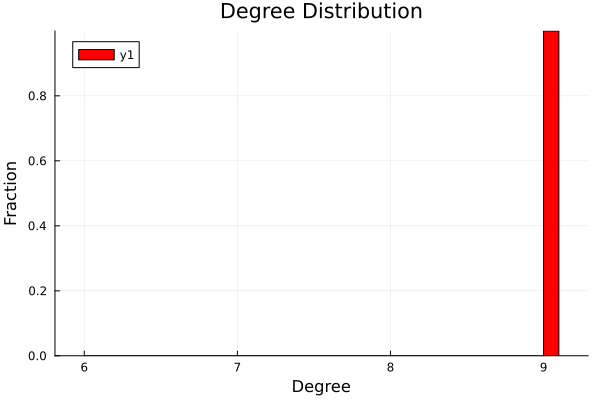

In [177]:
histogram(degree_seq,
    bins=50,
    normalize=:probability,   # y-axis as fraction of total
    title="Degree Distribution",
    #label = "Degree Dist: 400k population",
    xlabel="Degree",
    ylabel="Fraction",
    color = :red
)

**Purpose of this cell:** global_clustering_coefficient(clustered_G)


In [180]:
global_clustering_coefficient(clustered_G)
#global_clustering_coefficient(unclustered_G)

0.25001037517464875

## Single epidemic simulation workflow


#### Network Parameters (no intervention)


**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [184]:
#parameters for both contact tracing and no contact tracing

# Call contacts map
contacts_map = build_contacts_map(N, all_edges)

if clustered_choice == 1
    # Clustered network 
    
    target_R0 = 2.0
    r_R_c_λ = 0.9
    # r-Regular Random Network with Clique Size c
    # You r=9 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4], λ = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    # You r=6 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2], λ = [0.434, 0.544, 0.689, 0.9, 1.317]
     
    λ = compute_λ(clustered_choice, network_choice, target_R0, r_R_c_λ, er_ave_deg, r);
    
    
else
    # Unclustered network
    
    target_R0 = 2.0
    r_R_c_λ = 0.75
    λ = compute_λ(clustered_choice, network_choice, target_R0, r_R_c_λ, er_ave_deg, r);
end



0.9

**Purpose of this cell:** Define parameter values used by the subsequent simulation or analysis cells.


In [253]:

γ_shape, γ_scale = 1.82, 2.20 # Parameters for gamma distribution (Choice from Jesse Knight  Sharmistha Mishra 2020 paper)
# USE THIS 
# γ_shape, γ_scale = 1.633, 2.498 # Parameters for gamma distribution (Choice from Jesse Knight & Sharmistha Mishra 2021 paper (corrected version of their 2020 paper))

exp_dist_rate = 2.5 # Parameters for exponential distribution
use_exponential = false # Choosing exponential or gamma distribution for generation time distribution

gen_time_dist = use_exponential ? Exponential(exp_dist_rate) : Gamma(γ_shape, γ_scale)
gen_time_samples, poisson_samples, sample_indices = make_random_buffers(gen_time_dist; buffer_size=1_000_000)

infectious_delay_days = 0 # Number of days of days of not being infectious after getting infected
infectious_delay_policy = :shift # t_attempt = t_infect + infectious_delay_days + dt, where dt~gamma(γ_shape, γ_scale) or exp(exp_dist_rate)
#infectious_delay_policy = :clamp # t_attempt = max(t_infect + infectious_delay_days, t_infect + dt)

No_ini_inf = 1 # Number of initially infected individual(s)
initial_infected = rand(1:N, No_ini_inf)  # Initially infected individual(s)
max_time = 100.0;

#### Epidemic Parameters (no intervention)

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [255]:
# Parameters for case with no intervention
allow_CT = 0
multiple_step_CT = 0

p_detect = 0.0
p_isolate = 0.0
p_trace = 0.0

prevalence_threshold = 0.0

isolation_delay = 0.0
tracing_delay = 0.0
trace_mode = :all #or :infected_only
test_time_delay = 0.0
time_to_recovery = 0.0

initial_isolation_efficacy = 0.0
partial_isolation_efficacy = 0.0
post_isolation_efficacy = 0.0
frtr_det = 0.0; # fraction of transmission that happens before detection

stop_post_intervention = false
stopping_generation = 5;

#### Multiple simulation parameters

**Purpose of this cell:** Define parameter values used by the subsequent simulation or analysis cells.


In [257]:
# Multiple simulation parameters
use_cum_gen_counts = 1
seeds_per_run = 1
n_runs = 20000
max_attempts = n_runs * seeds_per_run * 4
initial_infected_pool = shared_initial_infected_pool(1:N, max_attempts);


#### Simulating epidemic (no intervention)

**Purpose of this cell:** Run the epidemic simulation or a batch of simulations using the parameters and network objects defined above.


In [259]:
@time begin
# For the case with no contact tracing,
# prevalence_threshold = 0
# allow_CT = 0

(individuals_no_intv, infection_log_no_intv, epidemic_curve_no_intv, detection_log_no_intv, isolation_log_no_intv, 
recovery_log_no_intv, partial_isolation_log_no_intv, intervention_time_no_intv, infection_attempt_log_no_intv, 
traced_susceptible_log_no_intv, eligible_susceptible_log_no_intv, ct_status_log_no_intv, traced_infected_log_no_intv, 
generations_from_model_no_intv) = simulate_sir_on_network_intervention(N,
    contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, initial_infected, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay,  
    tracing_delay, trace_mode,  time_to_recovery,  p_trace, test_time_delay, initial_isolation_efficacy, 
    partial_isolation_efficacy, post_isolation_efficacy; exp_dist_rate, use_exponential, infectious_delay_days, 
    infectious_delay_policy, stop_post_intervention, stopping_generation, debug=false)
end


status_no_intv = [s.status for s in individuals_no_intv]
summary_no_intv = Dict(:S => 0, :I => 0, :R => 0)
for s in values(status_no_intv)
    summary_no_intv[s] += 1
end
println("Final state counts: ", summary_no_intv)

  1.608886 seconds (5.00 M allocations: 664.461 MiB, 15.42% gc time)
Final state counts: Dict(:I => 499839, :R => 0, :S => 161)



#### Calculating theoretical R0

Remember to switch the clustered_choice between 0 (clustered network) and 1 (unclustered network) depending on the network you are using so as to get the correct R0.

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [261]:
R0_theo = R0_theoretical(clustered_choice, network_choice, λ, er_ave_deg, r)

0.9

In [262]:
λ

0.9

#### Visualization of epidemic curve (no intervention)
allow_intv takes binary values 0 (no intervention) or 1 (with intervention) as input

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


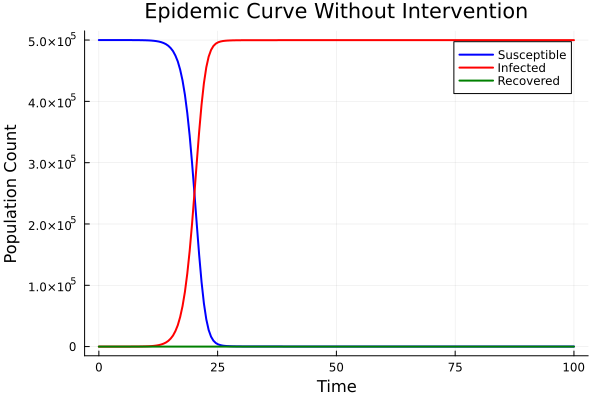

In [264]:
allow_intv = 0
plot_epidemic_curve(epidemic_curve_no_intv, allow_intv)
#savefig("Epi_curve_No_CT.png")

In [265]:
#savefig("Epi_curve_No_CT.png")

#### Visualization of cumulative infection curve (no intervention)

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


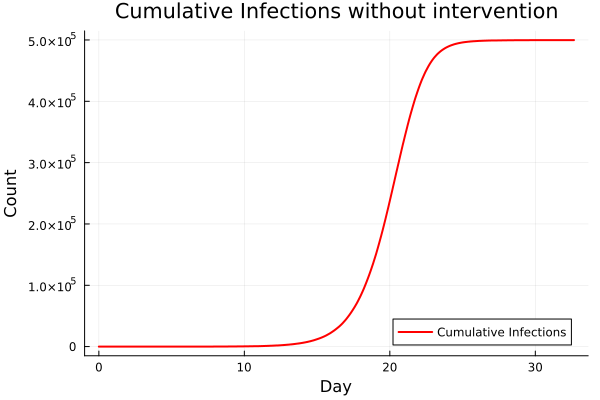

In [267]:
allow_intv = 0
plot_cumulative_infections(infection_log_no_intv, allow_intv)

In [268]:
#savefig("Cum_Inf_No_CT.png")

#### Dictionaries of infections per generation for both intervention and no intervention phases

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [270]:
infection_generation_no_intv = build_generation_dict(infection_log_no_intv)

Dict{Int64, Int64} with 499839 entries:
  185983 => 14
  437164 => 14
  379191 => 13
  92533  => 9
  371966 => 16
  76914  => 18
  221120 => 11
  37100  => 10
  173643 => 18
  422367 => 7
  331451 => 11
  300190 => 17
  427681 => 14
  185066 => 14
  313905 => 14
  190737 => 15
  449391 => 12
  235588 => 16
  62961  => 15
  ⋮      => ⋮

#### Visualization of infections per generation for the no intervention phase

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.

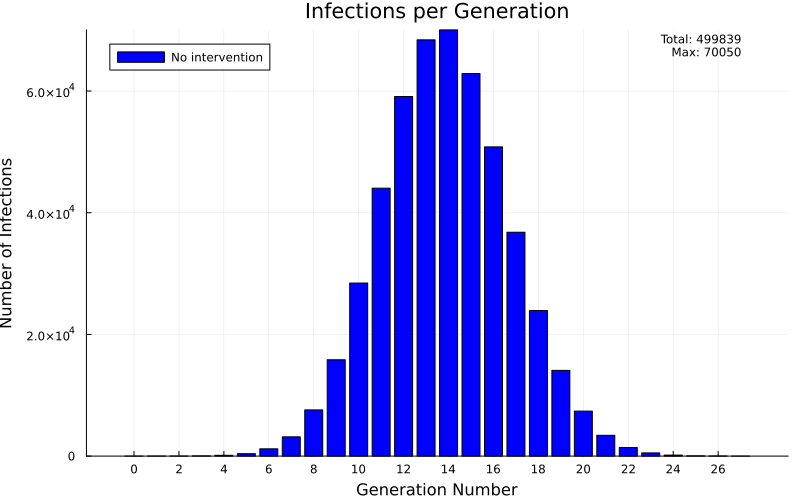

In [272]:
plot_infections_by_generation_opt(infection_generation_no_intv, label="No intervention", color=:blue)

In [273]:
generation_counts_no_intv = gen_counts_from_generation_dict(infection_generation_no_intv);

## Estimating Ro without interventions

### Estimating R0 in single simulation (no intervention)

#### Visualization

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


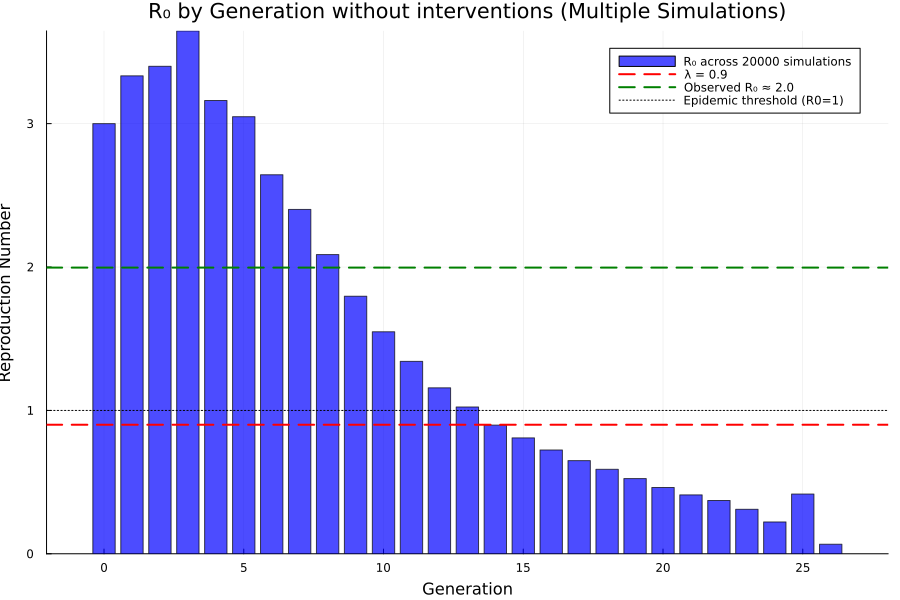

In [277]:
intv_allow = 0
post_intv = 0

if use_cum_gen_counts == 1
    
    p0 = Re_by_generation_from_cumcounts(generation_counts_no_intv, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p0 = Re_by_generation_multiple_simulations(infection_generation_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;
p0

#### Visualization (Time Series)

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


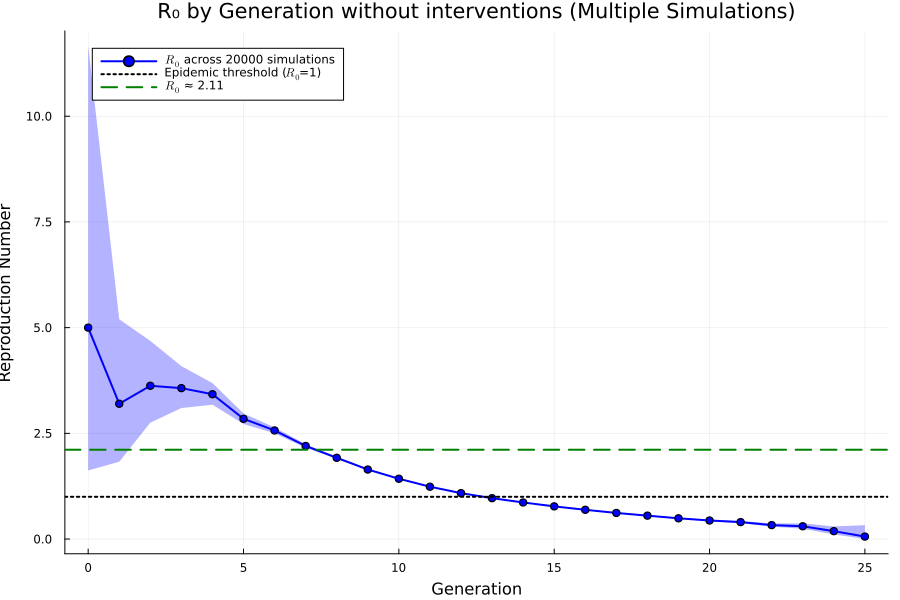

In [280]:
intv_allow = 0
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, p1 = Re_by_generation_from_cumcounts_ci(no_intv_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p1 = Re_by_generation_individual_bootstrap_ci(infection_generation_no_intv,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R₀ by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p1

### Estimating R0 in multiple simulations (no intervention)

#### Simulation

When use_cum_gen_count = 1, returns only the cummulative generation counts (without intervention), otherwise it returns generation dictionaries and infection log dictionaries (without intervention)

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
if use_cum_gen_counts == 1
    no_intv_cum_gen_counts  = run_epidemic_simulations_without_interventions_cum_gen_counts(N, contacts_map, λ,
    γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
    prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, trace_mode, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
    n_runs, max_attempts, initial_infected_pool; exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, debug=false);

else
    
    generation_dicts_no_intv, infection_log_dicts_no_intv = run_epidemic_simulations_without_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, trace_mode, 
    time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, 
    post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool; exp_dist_rate, use_exponential, 
    seeds_per_run, infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, debug=false);
    
end;

#### Visualization

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
intv_allow = 0
post_intv = 0

if use_cum_gen_counts == 1
    
    p = Re_by_generation_from_cumcounts(no_intv_cum_gen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    Re_by_generation_multiple_simulations(generation_dicts_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;
p

#### Visualization (Time Series)

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
intv_allow = 0
post_intv = 0


if use_cum_gen_counts == 1
    
    R0_values, _ , no_intv_plot = Re_by_generation_from_cumcounts_ci(no_intv_cum_gen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    #title = L"$R_0$ by Generation without interventions (Multiple Simulations)",
    title = L"$R_0$ by Generation without interventions",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false,  ylim = (0,4), legend_pos=:topleft);

else
    
    R0_values, _ , no_intv_plot = Re_by_generation_individual_bootstrap_ci(generation_dicts_no_intv,
    λ, clustered_choice, intv_allow, post_intv;
    #title = L"$R_0$ by Generation without interventions (Multiple Simulation)",
    title = L"$R_0$ by Generation without interventions",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


no_intv_plot

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


In [ ]:
#savefig("R₀ by generation via mutiple simulations (no intervention).png")

In [ ]:
R0_values

In [ ]:
mean(R0_values[2:5])

## Estimating Re with interventions

### Epidemic Parameters (with intervention)

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [283]:
# Intervention epidemic parameters
allow_CT = 1
multiple_step_CT = 0

p_detect = 0.7
p_isolate = 1.0 #0.8
p_trace = 0.7

prevalence_threshold = 10/N

isolation_delay = 0.0
tracing_delay = 1.0
trace_mode = :infected_only # :all, :infected_only, :causal_only
test_time_delay = 1.0
time_to_recovery = 0.0

initial_isolation_efficacy = 0.0
partial_isolation_efficacy = 1.0
post_isolation_efficacy = 1.0
frtr_det = 0.5 # fraction of transmission that happens before detection

stop_post_intervention = false
stopping_generation = 5;

#### Calculating theoretical R0 theoretical Re

Remember to switch the clustered_choice between 0 (clustered network) and 1 (unclustered network) depending on the network you are using so as to get the correct R0.

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [286]:
R0_theo = R0_theoretical(clustered_choice, network_choice, λ, er_ave_deg, r)

0.9

In [287]:
λ

0.9

### Simulating epidemic with intervention

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.

In [290]:
@time begin

(individuals, infection_log, epidemic_curve, detection_log, isolation_log, 
recovery_log, partial_isolation_log, intervention_time, infection_attempt_log, 
traced_susceptible_log, eligible_susceptible_log, ct_status_log, 
traced_infected_log, generations_from_model) = simulate_sir_on_network_intervention(N, 
    contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    initial_infected, max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, 
    multiple_step_CT, isolation_delay, tracing_delay, trace_mode, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, 
    post_isolation_efficacy; exp_dist_rate, use_exponential, infectious_delay_days, 
    infectious_delay_policy, stop_post_intervention, stopping_generation, debug=true)
end

status = [s.status for s in individuals]
summary_intv = Dict(:S => 0, :I => 0, :R => 0)
for s in values(status)
    summary_intv[s] += 1
end
println("Final state counts: ", summary_intv)

Intervention triggered at time 1.4245330035594554
  2.245162 seconds (5.96 M allocations: 784.944 MiB, 13.37% gc time)
Final state counts: Dict(:I => 434743, :R => 0, :S => 65257)


#### Visualization of epidemic curve (with intervention)

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


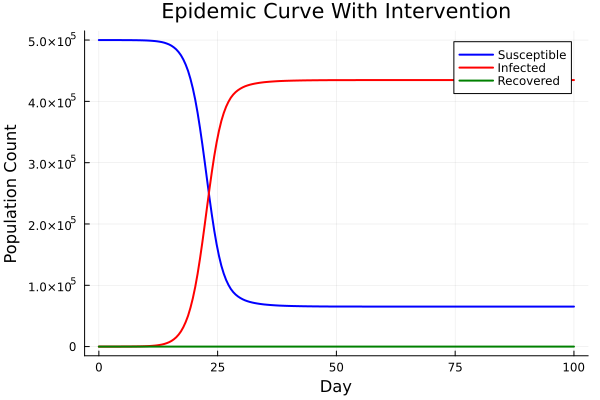

In [293]:
plot_epidemic_curve(epidemic_curve, allow_CT)
#savefig("Epi_curve_CT.png")

In [294]:
#savefig("Epi_curve_CT.png")

#### Visualization of cumulative infection curve (with intervention)

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


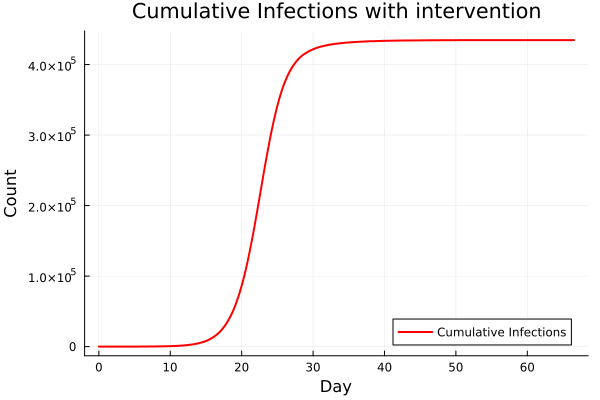

In [297]:
plot_cumulative_infections(infection_log, allow_CT)
#savefig("Cum_Inf_CT.png")

In [298]:
#savefig("Cum_Inf_CT.png")

#### Dictionaries of infections per generation for intervention phases

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [301]:
infection_generation = build_generation_dict(infection_log);

#### Count and map of infections per generation for intervention phase

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [304]:
gen_map = individuals_per_generation(infection_generation);
sort(gen_map[1])

generation_counts = gen_counts_from_generation_dict(infection_generation);


#### Pre intervention infection log

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [307]:
pre_intervention_infection_log = filter(x -> x[3] < intervention_time, infection_log);

#### Post intervention infection log

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [310]:
post_intervention_infection_log = filter(x -> x[3] >= intervention_time, infection_log);

#### Post intervention initial infected

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [313]:
post_intervention_initial_infected = find_post_intervention_initial_infected(infection_log, intervention_time);

#### Analysis on partial isolation

**Purpose of this cell:** Execute the code for **Analysis on partial isolation**. This cell continues the workflow established by the preceding markdown section.


In [316]:
detection_log_ids = getindex.(detection_log, 1)
isolation_log_ids = getindex.(isolation_log, 1)
partial_isolation_log_ids = getindex.(partial_isolation_log, 1)
#unique(partial_isolation_log_ids)
unique_partially_isolated = countmap([log[1] for log in partial_isolation_log])
sort(unique_partially_isolated);

In [317]:
length(unique_partially_isolated)/length(isolation_log);

In [318]:
intersect(unique(partial_isolation_log_ids), isolation_log_ids);

In [319]:
length(isolation_log_ids) - length(intersect(unique(partial_isolation_log_ids), isolation_log_ids));

#### Dictionaries of pre and post intervention infection generation

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [321]:
pre_intervention_infection_generation = build_generation_dict(pre_intervention_infection_log)
post_intervention_infection_generation = build_generation_dict(post_intervention_infection_log; 
already_sorted=true, seeds=post_intervention_initial_infected);

#### Count and map of infection generation for pre intervention phase

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [323]:
pre_intervention_gen_map = individuals_per_generation(pre_intervention_infection_generation);
sort(pre_intervention_gen_map[1]);

generation_counts_pre_intv = gen_counts_from_generation_dict(pre_intervention_infection_generation);

#### Checking for susceptible traced contacts that were later infected

**Purpose of this cell:** Run diagnostic checks on traced contacts to understand whether susceptible, infected, causal, or non-causal contacts contribute to transmission suppression.


In [325]:
length(ct_status_log)
#count(x -> x[4] == :S, ct_status_log)
#count(x -> x[4] == :I, ct_status_log)
count(x -> x[4] == :R, ct_status_log)

# length(eligible_susceptible_log)
# length(traced_susceptible_log)

0

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [327]:
diag = diagnose_traced_susceptible_infections(
    traced_susceptible_log,
    infection_log;
    gdict = post_intervention_infection_generation,
    gmin = 1,
    gmax = 3
)

NamedTuple[]

**Purpose of this cell:** Run diagnostic checks on traced contacts to understand whether susceptible, infected, causal, or non-causal contacts contribute to transmission suppression.


In [329]:
println("Number of susceptible traced contacts later infected by the detected case: ", count(x -> x.infected_by_traced_case, diag))
println("Number of susceptible traced contacts later infected by un-detected case: ", count(x -> !x.infected_by_traced_case, diag))

Number of susceptible traced contacts later infected by the detected case: 0
Number of susceptible traced contacts later infected by un-detected case: 0


#### Checking for traced infected contacts

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [331]:
diag_inf = diagnose_traced_infected_contacts(
    traced_infected_log,
    infection_log;
    gdict = post_intervention_infection_generation,
    gmin = 1,
    gmax = 3
)

120-element Vector{NamedTuple}:
 (traced_case = 344269, infected_contact = 340182, tracing_time = 5.174193198522881, infected_contact_infection_time = 4.41440714667789, infected_contact_infector = 187924, traced_case_infector = 295504, infectee_of_traced_case = false, infector_of_traced_case = false, causal = false, happy_accident = true, generation = 1)
 (traced_case = 288678, infected_contact = 48817, tracing_time = 5.232598157941921, infected_contact_infection_time = 4.0453598978889564, infected_contact_infector = 288678, traced_case_infector = 211694, infectee_of_traced_case = true, infector_of_traced_case = false, causal = true, happy_accident = false, generation = 1)
 (traced_case = 3316, infected_contact = 492165, tracing_time = 5.368546994437902, infected_contact_infection_time = 3.488358734466653, infected_contact_infector = 163225, traced_case_infector = 411070, infectee_of_traced_case = false, infector_of_traced_case = false, causal = false, happy_accident = true, generation

**Purpose of this cell:** Run diagnostic checks on traced contacts to understand whether susceptible, infected, causal, or non-causal contacts contribute to transmission suppression.


In [333]:
println("Number of direct infectees of the detected case: ", count(x -> x.infectee_of_traced_case, diag_inf))
println("Number of direct infector of the detected case: ", count(x -> x.infector_of_traced_case, diag_inf))
println("Number of causal: ", count(x -> x.causal, diag_inf))
println("Number of happy accident: ", count(x -> x.happy_accident, diag_inf))

Number of direct infectees of the detected case: 43
Number of direct infector of the detected case: 45
Number of causal: 88
Number of happy accident: 32


#### Count and map of infection generation for post intervention phase

**Purpose of this cell:** Derive generation-level summaries from infection logs for estimating R0/Re and diagnosing post-intervention transmission.


In [336]:
post_intervention_gen_map = individuals_per_generation(post_intervention_infection_generation)
sort(post_intervention_gen_map[1]);

generation_counts_post_intv = gen_counts_from_generation_dict(post_intervention_infection_generation);

#### Visualization of infections per generation for the intervention phase

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


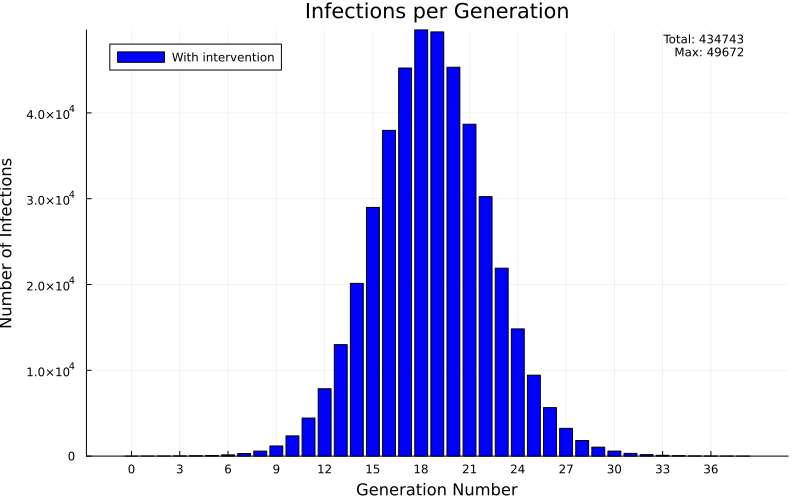

In [339]:
plot_infections_by_generation_opt(infection_generation, label="With intervention", color=:blue)

### Estimating Re in single simulation with intervention (pre and post)

#### Visualization 

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


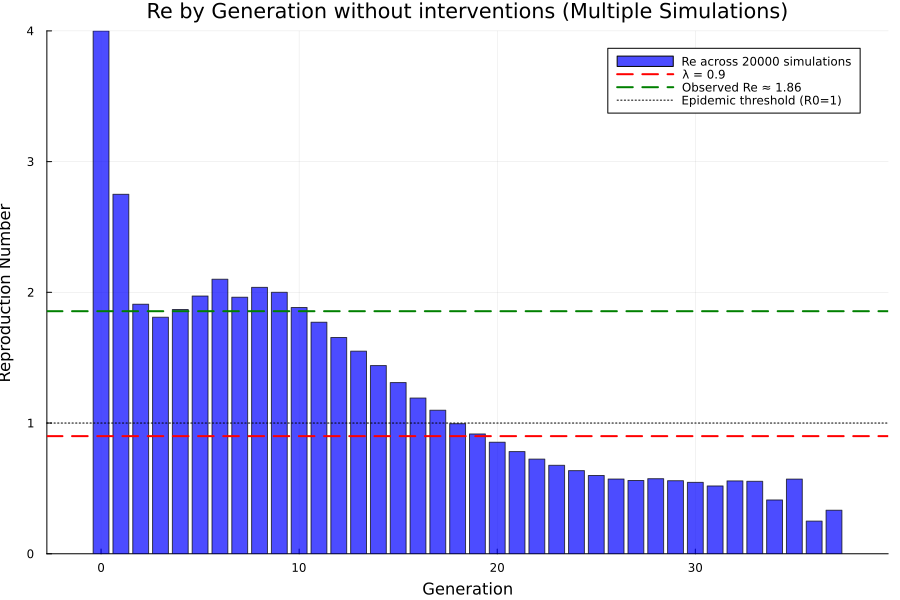

In [342]:
intv_allow = 1
post_intv = 0

if use_cum_gen_counts == 1
    
    p_plot1 = Re_by_generation_from_cumcounts(generation_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p_plot1 = Re_by_generation_multiple_simulations(infection_generation, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

p_plot1

#### Visualization (Time Series)

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


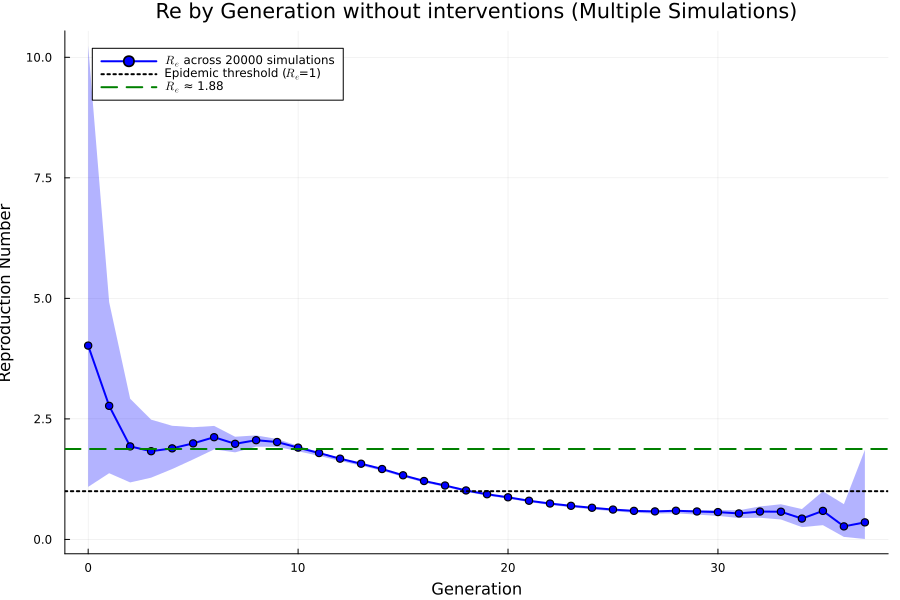

In [345]:
intv_allow = 1
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, p_plot2 = Re_by_generation_from_cumcounts_ci(generation_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p_plot2 = Re_by_generation_individual_bootstrap_ci(infection_generation,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p_plot2

### Estimating Re in single simulation with intervention (post)

#### Visualization

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


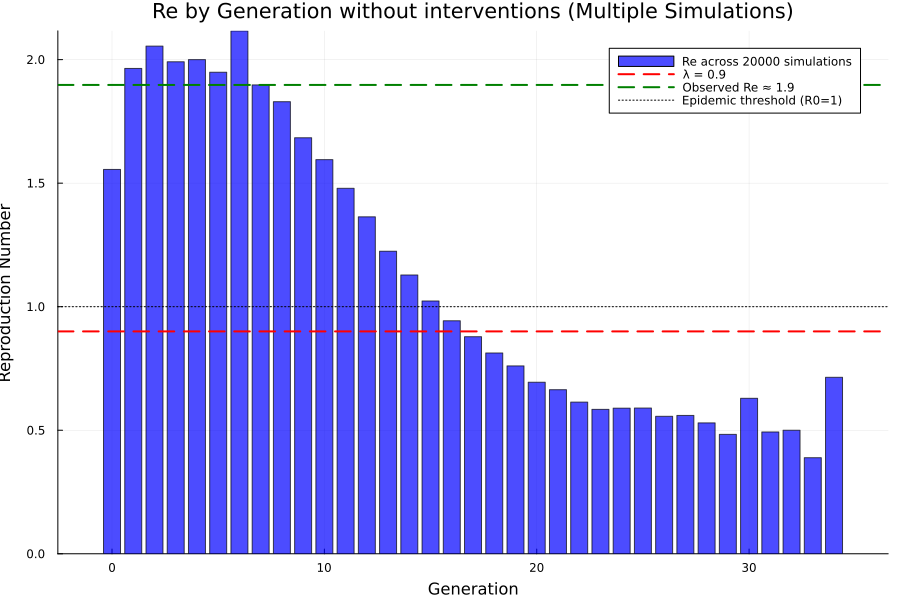

In [348]:
intv_allow = 1
post_intv = 1

if use_cum_gen_counts == 1
    
    p_plot3 = Re_by_generation_from_cumcounts(generation_counts_post_intv, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p_plot3 = Re_by_generation_multiple_simulations(post_intervention_infection_generation, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

p_plot3

#### Visualization (Time Series)

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


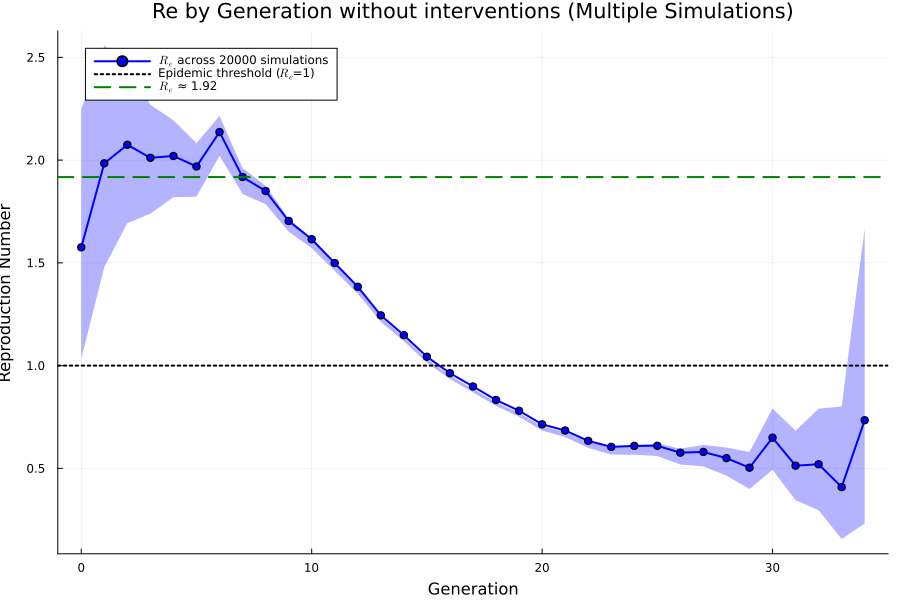

In [349]:
intv_allow = 1
post_intv = 1


if use_cum_gen_counts == 1
    
    _, _, p_plot4 = Re_by_generation_from_cumcounts_ci(generation_counts_post_intv, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p_plot4 = Re_by_generation_individual_bootstrap_ci(post_intervention_infection_generation,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p_plot4

### Estimating Re in multiple simulations with intervention (pre and post)

#### Simulation

When use_cum_gen_count = 1, returns only the cummulative generation counts (with intervention), otherwise it returns generation dictionaries and infection log dictionaries (with intervention)

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
if use_cum_gen_counts == 1
    with_intv_cum_gen_counts, with_intv_cum_postgen_counts  = run_epidemic_simulations_with_interventions_cum_gen_counts(N, contacts_map, 
    λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
    prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, trace_mode, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
    n_runs, max_attempts, initial_infected_pool; exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, progress_bar = true, debug=false);

else
    
    generation_dicts, post_intervention_generation_dicts, infection_log_dicts, detection_log_dicts,  infection_attempt_log_dicts = run_epidemic_simulations_with_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples,poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool; 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, debug=false);
    
end;



#### Visualization 

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
intv_allow = 1
post_intv = 0

if use_cum_gen_counts == 1
    
    pplot1 = Re_by_generation_from_cumcounts(with_intv_cum_gen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    pplot1 = Re_by_generation_multiple_simulations(generation_dicts, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

pplot1

#### Visualization (Time Series)

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
intv_allow = 1
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, pplot2 = Re_by_generation_from_cumcounts_ci(with_intv_cum_gen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    #title = "Re by Generation without interventions (Multiple Simulations)",
    title = L"$R_e$ by Generation without interventions",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false, ylim=(0,4));

else
    
    _, _, pplot2 = Re_by_generation_individual_bootstrap_ci(generation_dicts,
    λ, clustered_choice, intv_allow, post_intv;
    #title = "Re by Generation without interventions (Multiple Simulation)",
    title = L"$R_e$ by Generation without interventions",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false, ylim=(0,4)
);
    
end;


pplot2

In [ ]:
#savefig("Rₑ by generation via mutiple simulations pre_intv (with intervention).png")

### Estimating Re in multiple simulations with intervention (post)

#### Visualization

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
intv_allow = 1
post_intv = 1

if use_cum_gen_counts == 1
    
    pplot3 = Re_by_generation_from_cumcounts(with_intv_cum_postgen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    pplot3 = Re_by_generation_multiple_simulations(generation_dicts_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

pplot3

#### Visualization (Time Series)

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
intv_allow = 1
post_intv = 1


if use_cum_gen_counts == 1
    
    Re_values, _, pplot4 = Re_by_generation_from_cumcounts_ci(with_intv_cum_postgen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    #title = L"$R_e$ by Generation with interventions (Multiple Simulations)",
    title = L"$R_e$ by Generation with interventions",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false, ylim=(0,4));

else
    
    Re_values, _, pplot4 = Re_by_generation_individual_bootstrap_ci(post_intervention_generation_dicts,
    λ, clustered_choice, intv_allow, post_intv;
    #title = L"$R_e$ by Generation with interventions (Multiple Simulation)",
    title = L"$R_e$ by Generation with interventions",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false, ylim=(0,4)
);
    
end;


pplot4

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


In [ ]:
#savefig("Rₑ by generation via mutiple simulations  (with intervention).png")

In [ ]:
Re_values

In [ ]:
mean(Re_values[2:5])

#### Visualization of mean neighbors per generation

**Purpose of this cell:** Execute the code for **Visualization of mean neighbors per generation**. This cell continues the workflow established by the preceding markdown section.


In [ ]:
mean_deg_dict, n_per_gen_dict = mean_neighbors_per_generation_mult(generation_dicts_no_intv, unclustered_G)

In [ ]:
sort(mean_deg_dict)

In [ ]:
sort(n_per_gen_dict)

In [ ]:
gens = sort(collect(keys(mean_deg_dict)))
#plot(gens, [round(mean_deg_dict[g]) for g in gens];
plot(gens, [mean_deg_dict[g] for g in gens];
     seriestype=:scatter, marker = :circle, lw =2, xlabel="Generation", 
     ylabel="Mean degree", label="Mean neighbors per generation",
     title="Mean neighbors per generation")

#plot!(gens, [round(mean_deg_dict[g]) for g in gens];
plot!(gens, [mean_deg_dict[g] for g in gens];
     seriestype=:line,
     lw=2,
     color=:blue,
     label="")

In [ ]:
savefig("mean neighbors per generation  (no intervention).png")

## Effectiveness of intervention strategies

### Effectiveness of intervention strategies per network

#### Parameters

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
R0_values = collect(1.4:0.2:2.4)

if clustered_choice == 1
    # r-Regular Random Network with Clique Size c
    # You r=9 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4], λ = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    r_R_c_λ_values = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    # You r=6 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2], λ = [0.434, 0.544, 0.689, 0.9, 1.317]
    # r_R_c_λ_values = [0.434, 0.544, 0.689, 0.9, 1.317]
else
    λ_values = compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r)
end

gmin = 4 #minimum generation window
gmax = 7; #maximum generation window

#### Effective Re from generations

**Purpose of this cell:** Select or generate the contact network used as the substrate for epidemic simulation.


In [ ]:
if use_cum_gen_counts == 1
    effective_Re_from_generations_cum_gen_counts(with_intv_cum_postgen_counts, λ, 
    clustered_choice, intv_allow, post_intv, gmin, gmax, n_runs)
else
    effective_Re_from_generations(post_intervention_generation_dicts, λ, 
    clustered_choice, intv_allow, post_intv, gmin, gmax)
end

#### Estimate Re for R0 across different intervention strategies

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
if clustered_choice == 1
    estimate_Re_for_R0_and_regime(R0_values[1], λ, clustered_choice, intv_allow, post_intv, N, 
    contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, 
    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
    stop_post_intervention, stopping_generation, use_cum_gen_counts, gmin, gmax, early_termination)
else
    estimate_Re_for_R0_and_regime(R0_theo, λ, clustered_choice, intv_allow, post_intv, N, 
    contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, 
    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
    stop_post_intervention, stopping_generation, use_cum_gen_counts, gmin, gmax, early_termination)
end

#### Compute effectiveness for intervention strategies for a network

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
if clustered_choice == 1
    ratios_noCT, ratios_oneCT, ratios_multiCT = compute_effectiveness_curves(R0_values, 
    r_R_c_λ_values, clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, 
    γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, 
    initial_infected_pool, exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, 
    use_cum_gen_counts, gmin, gmax; RR_R0_Obs);
else
    ratios_noCT, ratios_oneCT, ratios_multiCT = compute_effectiveness_curves(R0_values, 
    λ_values, clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, 
    γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, trace_mode, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, 
    initial_infected_pool, exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, stop_post_intervention, stopping_generation, 
    use_cum_gen_counts, gmin, gmax);
end;

#### Visualization of ffectiveness of intervention strategies for a network

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
p = plot_Re_over_R0_curves(R0_values, ratios_noCT, ratios_oneCT, ratios_multiCT;
                           title_str = "Re/R₀ vs R₀ for Random Regular Network",
                           legend_pos = :left)
display(p)

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


In [ ]:
savefig("Effectiveness of intervention for Random Regular Network.png")

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
R0_values_col = reshape(R0_values, :, 1)  
ratios_noCT_col = reshape(ratios_noCT, :, 1)
ratios_oneCT_col = reshape(ratios_oneCT, :, 1)  
ratios_multiCT_col = reshape(ratios_multiCT, :, 1)  

M = hcat(R0_values_col, ratios_noCT_col, ratios_oneCT_col, ratios_multiCT_col)

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
df = DataFrame(M, [:R0_values, :No_CT, :One_step_CT, :Multi_step_CT])

### Visualization of effectiveness of intervention strategies across networks

#### Intervention Epidemic Parameters

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
# Intervention epidemic parameters
allow_CT = 0
multiple_step_CT = 0

p_detect = 0.7
p_isolate = 1.0
p_trace = 0.7

prevalence_threshold = 100/N

isolation_delay = 0.0
tracing_delay = 1.0
trace_mode = :causal_only # :all, :infected_only, :causal_only
test_time_delay = 1.0
time_to_recovery = 0.0

initial_isolation_efficacy = 0.0
partial_isolation_efficacy = 1.0
post_isolation_efficacy = 1.0
frtr_det = 0.5 # fraction of transmission that happens before detection

stop_post_intervention = true
stopping_generation = 5;

#### Parameters

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [112]:
intv_allow = 1
post_intv = 1

gmin = 1 # minimum generation window
gmax = 3 # maximum generation window


# For r=6 and c=4
# R0_values = collect(1.4:0.2:2.2)
# λ_values = [0.437, 0.547, 0.689, 0.904, 1.321]
# ============================================== COMMENT OUT =================================================
# λ_values = [0.434, 0.544, 0.689, 0.9, 1.317]; # N=4000000
# λ_values  = compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r)
# ============================================================================================================



# For r=9 and c=4
# R0_values = collect(1.4:0.2:2.2)
# λ_values = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
# ============================================== COMMENT OUT =================================================
# λ_values  = compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r)
# ============================================================================================================



# For r=8 and c=5 
R0_values = collect(1.4:0.2:2.2)
λ_values = [0.280, 0.341, 0.412, 0.501, 0.621]
# ============================================== COMMENT OUT =================================================
# λ_values  = compute_lambda_vector_old(R0_values, clustered_choice, network_choice, r_R_c_λ, er_ave_deg, r)
# ============================================================================================================


# Multiple simulation parameters
use_cum_gen_counts = 1
seeds_per_run = 1
n_runs = 20000
max_attempts = n_runs * seeds_per_run * 4
initial_infected_pool = shared_initial_infected_pool(1:N, max_attempts);

#### Estimate Observed R0 for different values of λ and target R0

This is for a single network. 

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
R0_Obs_Vec = compute_observed_R0(N, contacts_map, R0_values, λ_values, clustered_choice, 
network_choice, r_R_c_λ, er_ave_deg, r,γ_shape, γ_scale, gen_time_samples, 
poisson_samples, sample_indices, 
isolation_delay, tracing_delay, trace_mode, time_to_recovery,
n_runs, max_attempts, initial_infected_pool, 
exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, 
infectious_delay_policy, stop_post_intervention, stopping_generation; gmin, gmax, progress_bar = true);


R0_Obs_Vec

#### Outputs for observed R0 for different networks 
This is Observed R0 for different values of λ across networks.

**Purpose of this cell:** Define parameter values used by the subsequent simulation or analysis cells.


In [ ]:
RR_R0_Obs =[1.3993, 1.5995, 1.7974, 1.9946, 2.1991]
ER_R0_Obs = [1.3982, 1.6038, 1.8041, 1.9969, 2.2003]
#RR_Clique_R0_Obs = [1.3925, 1.5949, 1.7929, 1.9937, 2.1946]; #This r=6, c=4
#RR_Clique_R0_Obs = [1.4007, 1.5970, 1.7839, 1.9843, 2.1826]; #This r=9, c=4
RR_Clique_R0_Obs = [1.4005, 1.5984, 1.8009, 1.9999, 2.1989]; #This r=8, c=5

#### Network Specs

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [116]:
# --- ER ---
_, unclustered_ER_edges = generate_ER_graph(N, er_prob)
contacts_map_ER = build_contacts_map(N, unclustered_ER_edges)

er_spec = (name = "ER(k=6)", contacts_map = contacts_map_ER, 
    clustered_choice = 0, network_choice = 3, r_R_c_λ = 0.0,
    k = 6.0, r = 0, λ_values = nothing, R0_obs_values = ER_R0_Obs);


# --- RR ---
unclustered_RR_edges = generate_k_regular(N, r; seed=123, output=:edges)
contacts_map_RR = build_contacts_map(N, unclustered_RR_edges)

rr_spec = (name = "RR(r=7)", contacts_map = contacts_map_RR, 
    clustered_choice = 0, network_choice = 2, r_R_c_λ = 0.0,
    k = 0.0, r = 7, λ_values = nothing, R0_obs_values = RR_R0_Obs);


# --- Clique network ---
_, clustered_rRRc_edges, _ = generate_clustered_clique_network(N, c_Clique, r_Clique)
contacts_map_CLIQUE = build_contacts_map(N, clustered_rRRc_edges)


# clique_spec = (name = "RR+Clique(r=6,c=4)", contacts_map = contacts_map_CLIQUE,
#     clustered_choice = 1, network_choice = 1, r_R_c_λ = 0.0,
#     k = 0.0, r = 0, λ_values = [0.437, 0.547, 0.689, 0.904, 1.321], R0_obs_values=RR_Clique_R0_Obs);


# clique_spec = (name = "RR+Clique(r=9,c=4)", contacts_map = contacts_map_CLIQUE,
#     clustered_choice = 1, network_choice = 1, r_R_c_λ = 0.0,
#     k = 0.0, r = 0, λ_values = [0.211, 0.247, 0.285, 0.327, 0.375], R0_obs_values=RR_Clique_R0_Obs);


clique_spec = (name = "RR+Clique(r=8,c=5)", contacts_map = contacts_map_CLIQUE,
    clustered_choice = 1, network_choice = 1, r_R_c_λ = 0.0,
    k = 0.0, r = 0, λ_values = [0.280, 0.341, 0.412, 0.501, 0.621], R0_obs_values=RR_Clique_R0_Obs);

#### Compute effectiveness of intervention strategies in one network

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [ ]:
res = compute_effectiveness_curves(
    R0_values, λ_values,
    clustered_choice, intv_allow, post_intv, 
    N, contacts_map, γ_shape, γ_scale, 
    gen_time_samples, poisson_samples, sample_indices,
    max_time, p_detect, p_isolate, prevalence_threshold,
    isolation_delay, tracing_delay, trace_mode, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool,
    exp_dist_rate, use_exponential, seeds_per_run,
    infectious_delay_days, infectious_delay_policy,
    stop_post_intervention, stopping_generation,
    use_cum_gen_counts, gmin, gmax;
    R0_obs_values = RR_R0_Obs,  
    prog = nothing);

#### Visualization of effectiveness of intervention strategies in one network

**Purpose of this cell:** Set target reproduction numbers and compute or store the corresponding transmission parameters for later simulations.


In [ ]:
p = plot_Re_over_R0_curves(
    R0_values,
    res.ratios_noCT,
    res.ratios_oneCT,
    res.ratios_multiCT;
    R0_obs_values = RR_R0_Obs, 
    title_str = "Effect of Interventions: Re/R₀ vs R₀"
)

display(p)

#### Compute effectiveness of intervention strategies across networks

**Purpose of this cell:** Set intervention-related epidemic parameters, including detection, isolation, tracing, testing, and quarantine assumptions.


In [117]:
network_specs = [er_spec, rr_spec, clique_spec]


results = compute_effectiveness_across_networks(network_specs, R0_values;
    intv_allow, post_intv, N, γ_shape, γ_scale, gen_time_samples,
    poisson_samples, sample_indices, max_time, p_detect, p_isolate,
    prevalence_threshold, isolation_delay, tracing_delay, trace_mode,
    time_to_recovery, p_trace, test_time_delay,
    initial_isolation_efficacy, partial_isolation_efficacy,
    post_isolation_efficacy, n_runs, max_attempts,
    initial_infected_pool, exp_dist_rate, use_exponential,
    seeds_per_run, infectious_delay_days, infectious_delay_policy,
    stop_post_intervention, stopping_generation,
    use_cum_gen_counts, gmin, gmax, progress_bar =true);

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
Networks: 100%|█████████████████████████████████████████| Time: 3:54:48
   Network: RR+Clique(r=8,c=5) (3/3)


In [118]:
results

Dict{String, Any} with 3 entries:
  "ER(k=6)"            => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.3…
  "RR+Clique(r=8,c=5)" => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.4…
  "RR(r=7)"            => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.3…

#### Save results for re-use

**Purpose of this cell:** Save or reload simulation results so long-running computations do not need to be repeated.


In [ ]:
@save "effectiveness_results.jld2" results

### Load saved results for re-use

**Purpose of this cell:** Save or reload simulation results so long-running computations do not need to be repeated.


In [ ]:
# @load "effectiveness_results_r=6_c=4_v1.jld2" results
# result_r6_c4_v1 = results;
# result_r6_c4_v1

# @load "effectiveness_results_r=6_c=4_v2.jld2" results
# result_r6_c4_v2 = results;
# result_r6_c4_v2

# @load "effectiveness_results_r=6_c=4_v3.jld2" results
# result_r6_c4_v3 = results;
# result_r6_c4_v3



# ========================================================
# ========================================================


# @load "effectiveness_results_r=9_c=4_v1.jld2" results
# result_r9_c4_v1 = results;
# result_r9_c4_v1

# @load "effectiveness_results_r=9_c=4_v2.jld2" results
# result_r9_c4_v2 = results;
# result_r9_c4_v2

# @load "effectiveness_results_r=9_c=4_v3.jld2" results
# result_r9_c4_v3 = results;
# result_r9_c4_v3




# ========================================================
# ========================================================


@load "effectiveness_results_r=8_c=5_v1.jld2" results
result_r8_c5_v1 = results;
result_r8_c5_v1

@load "effectiveness_results_r=8_c=5_v2.jld2" results
result_r8_c5_v2 = results;
result_r8_c5_v2

@load "effectiveness_results_r=8_c=5_v3.jld2" results
result_r8_c5_v3 = results;
result_r8_c5_v3

Dict{String, Any} with 3 entries:
  "ER(k=6)"            => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.3…
  "RR+Clique(r=8,c=5)" => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.4…
  "RR(r=7)"            => (R0_target = [1.4, 1.6, 1.8, 2.0, 2.2], R0_obs = [1.3…

#### Visualization of effectiveness of intervention strategies across networks

**Purpose of this cell:** Define parameter values used by the subsequent simulation or analysis cells.


In [75]:
network_colors = Dict(
    "ER(k=6)"              => :dodgerblue,
    "RR(r=7)"              => :darkorange,
    "RR+Clique(r=8,c=5)"  => :forestgreen
)

Dict{String, Symbol} with 3 entries:
  "ER(k=6)"            => :dodgerblue
  "RR+Clique(r=8,c=5)" => :forestgreen
  "RR(r=7)"            => :darkorange

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


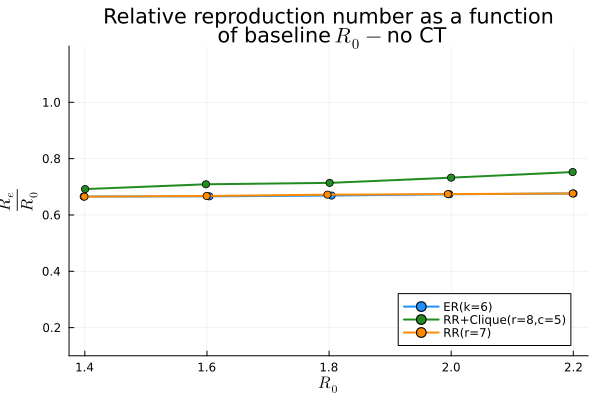

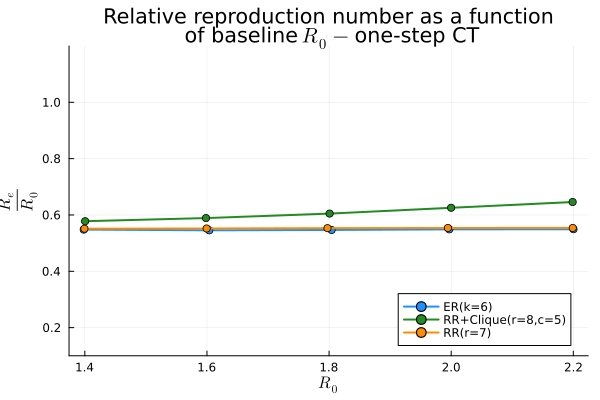

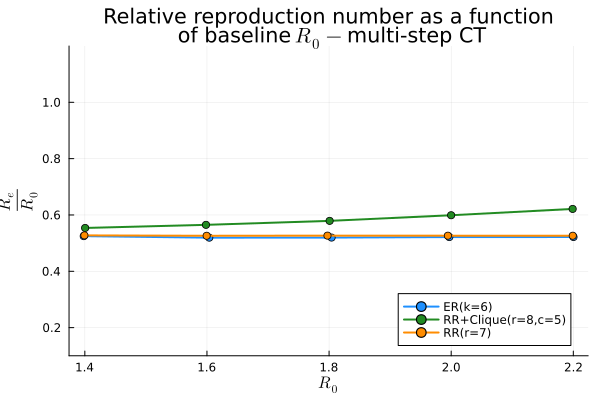

In [ ]:
p_noCT = plot_across_networks(result_r8_c5_v3; regime=:noCT, xaxis=:R0_obs, ywhat=:ratio,  title_str="Relative reproduction number as a function\n of baseline" * L"$\ R_0-$" * "no CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.10,1.2))

p_oneCT = plot_across_networks(result_r8_c5_v3; regime=:oneCT, xaxis=:R0_obs, ywhat=:ratio,  title_str="Relative reproduction number as a function\n of baseline" * L"$\ R_0-$" * "one-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.10,1.2))

p_multiCT = plot_across_networks(result_r8_c5_v3; regime=:multiCT, xaxis=:R0_obs, ywhat=:ratio,  title_str="Relative reproduction number as a function\n of baseline" * L"$\ R_0-$" * "multi-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.10,1.2));

savefig(p_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against R0 - No CT.png")
savefig(p_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against R0 - One CT.png")
savefig(p_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against R0 - Multi CT.png")




display(p_noCT)
display(p_oneCT)
display(p_multiCT)

#### Visualization of intervention strategies on Re across networks

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


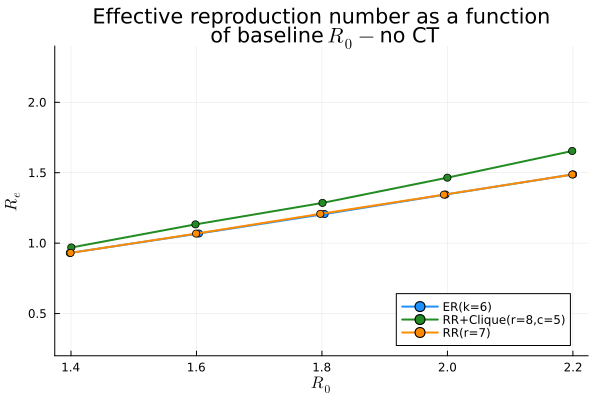

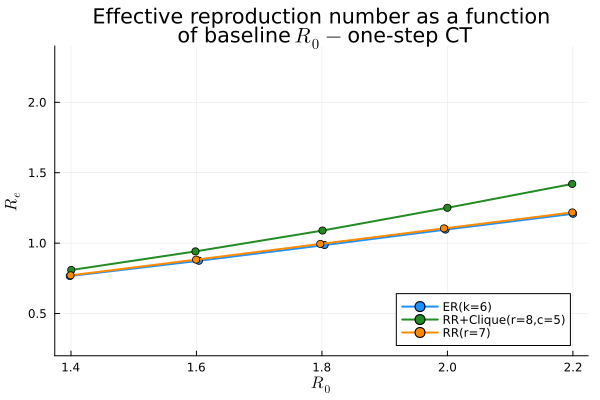

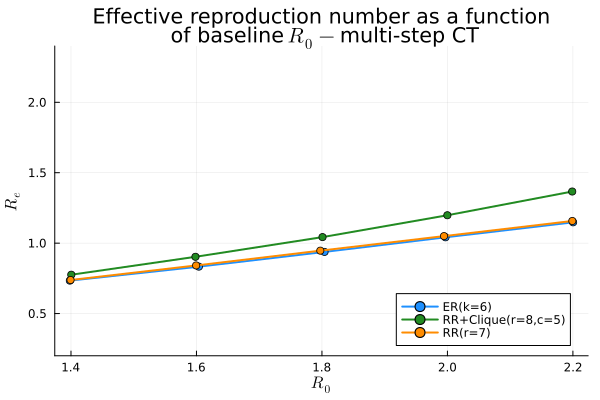

In [ ]:
p_Re_noCT = plot_across_networks(result_r8_c5_v3; regime=:noCT, xaxis=:R0_obs, ywhat=:Re,  title_str="Effective reproduction number as a function\n of baseline" * L"$\ R_0-$" * "no CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.2,2.4))

p_Re_oneCT = plot_across_networks(result_r8_c5_v3; regime=:oneCT, xaxis=:R0_obs, ywhat=:Re,  title_str="Effective reproduction number as a function\n of baseline" * L"$\ R_0-$" * "one-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.2,2.4))

p_Re_multiCT = plot_across_networks(result_r8_c5_v3; regime=:multiCT, xaxis=:R0_obs, ywhat=:Re,  title_str="Effective reproduction number as a function\n of baseline" * L"$\ R_0-$" * "multi-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.2,2.4));

savefig(p_Re_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Re against R0 - No CT.png")
savefig(p_Re_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Re against R0 - One CT.png")
savefig(p_Re_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Re against R0 - Multi CT.png")



display(p_Re_noCT)
display(p_Re_oneCT)
display(p_Re_multiCT)

#### Visualization of intervention strategies with respect to λ

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


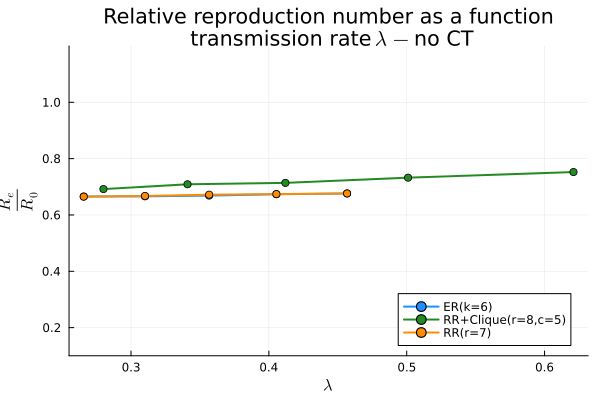

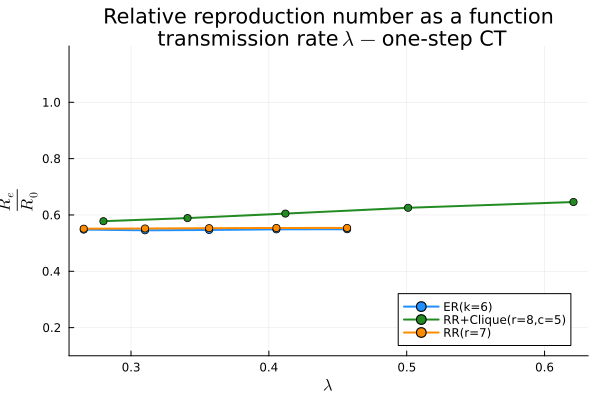

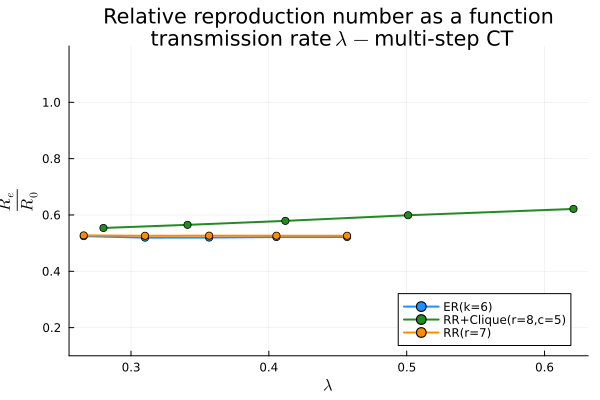

In [ ]:
p_Ratio_λ_noCT = plot_across_networks(result_r8_c5_v3; regime=:noCT, xaxis=:lambda, ywhat=:ratio,  title_str="Relative reproduction number as a function\n transmission rate" * L"$\ \lambda-$" * "no CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.1,1.2))

p_Ratio_λ_oneCT = plot_across_networks(result_r8_c5_v3; regime=:oneCT,  xaxis=:lambda, ywhat=:ratio, title_str="Relative reproduction number as a function\n transmission rate" * L"$\ \lambda-$" * "one-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.1, 1.2))

p_Ratio_λ_multiCT = plot_across_networks(result_r8_c5_v3; regime=:multiCT, xaxis=:lambda, ywhat=:ratio, title_str="Relative reproduction number as a function\n transmission rate" * L"$\ \lambda-$" * "multi-step CT", legend_pos=:bottomright, colors=network_colors, ylim = (0.1, 1.2));

savefig(p_Ratio_λ_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against λ - No CT.png")
savefig(p_Ratio_λ_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against λ - One CT.png")
savefig(p_Ratio_λ_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Rho against λ - Multi CT.png")




display(p_Ratio_λ_noCT)
display(p_Ratio_λ_oneCT)
display(p_Ratio_λ_multiCT)

#### Visualization of comparison of tracing strategies based on relative effectiveness of interventions

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


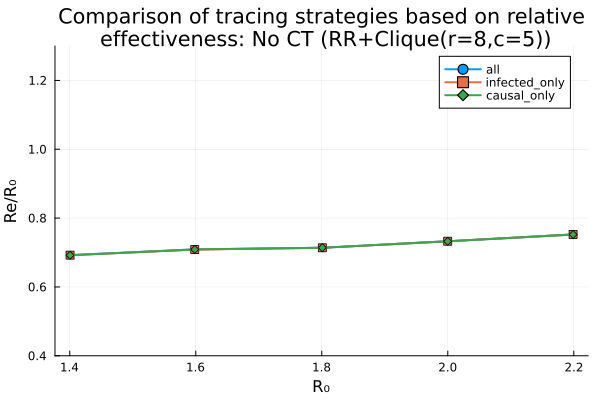

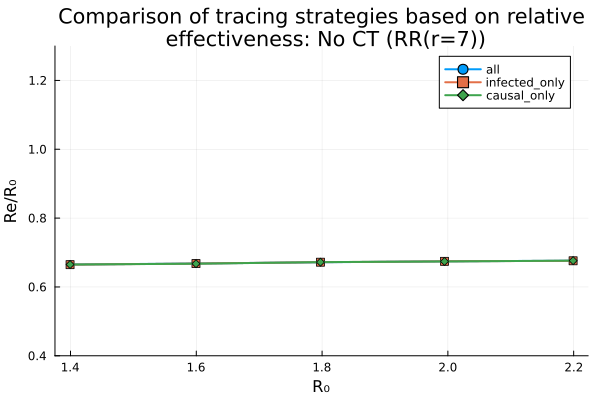

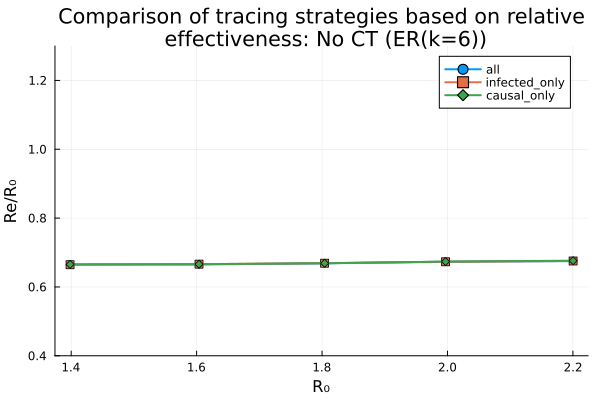

In [124]:
p_1_noCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: No CT",
    ylim = (0.4, 1.3)
)


p_2_noCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: No CT",
    ylim = (0.4, 1.3)
)


p_3_noCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: No CT",
    ylim = (0.4, 1.3)
)


savefig(p_1_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR+C r8 c5 - No CT.png")
savefig(p_2_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR r=7 - No CT.png")
savefig(p_3_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) ER k=6 - No CT.png")



display(p_1_noCT)
display(p_2_noCT)
display(p_3_noCT)

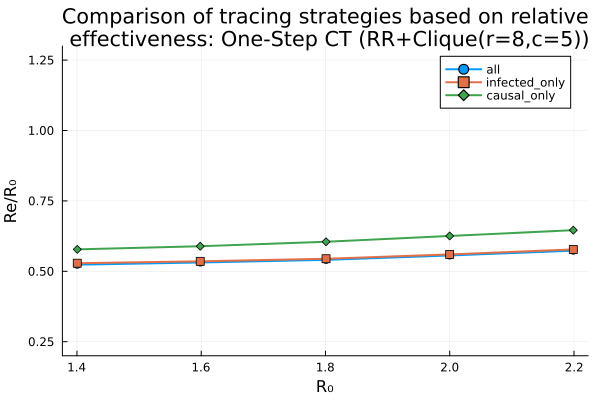

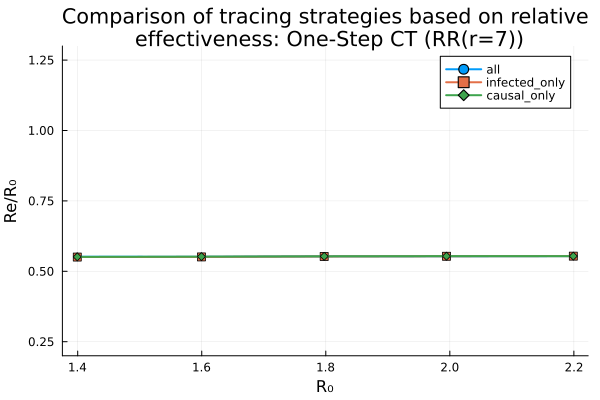

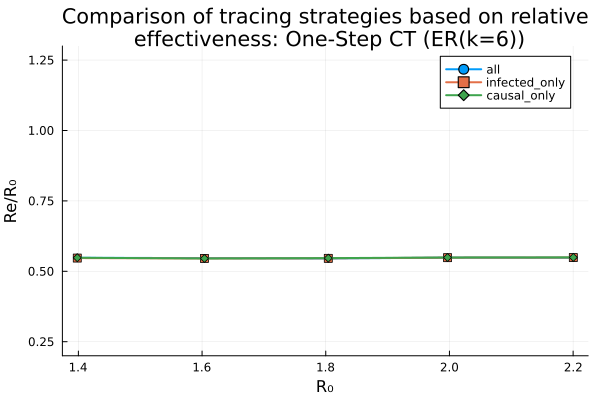

In [125]:
p_1_oneCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: One-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) RR+C r8 c5 - One CT.png")


p_2_oneCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: One-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) RR r=7 - One CT.png")

p_3_oneCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: One-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) ER k=6 - One CT.png")


savefig(p_1_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR+C r8 c5 - One CT.png")
savefig(p_2_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR r=7 - One CT.png")
savefig(p_3_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) ER k=6 - One CT.png")


display(p_1_oneCT)
display(p_2_oneCT)
display(p_3_oneCT)

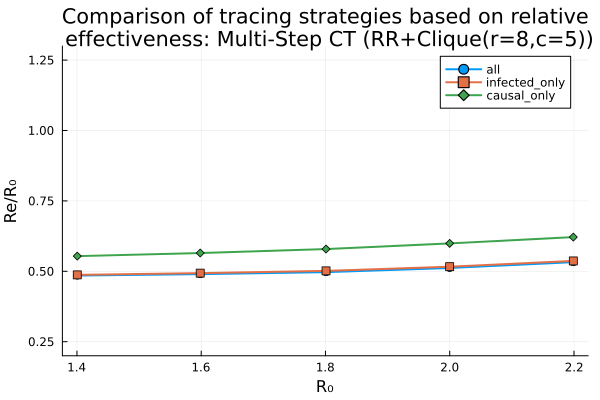

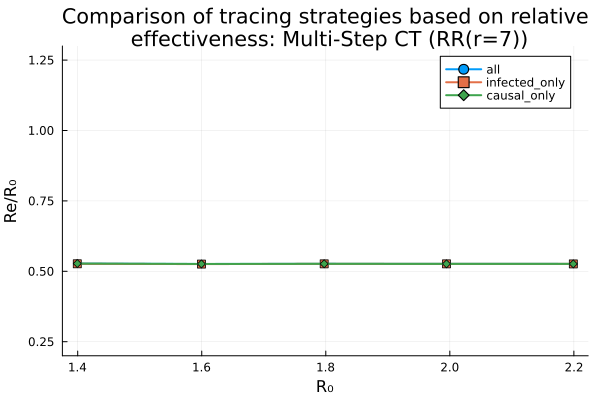

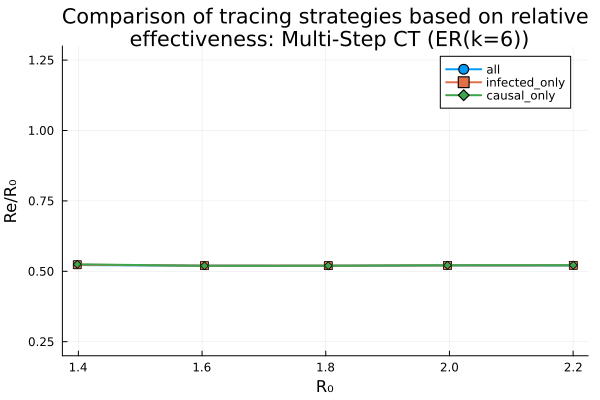

In [126]:
p_1_multiCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: Multi-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) RR+C r8 c5 - Multi CT.png")

p_2_multiCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: Multi-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) RR r=7 - Multi CT.png")

p_3_multiCT = plot_trace_modes_Re_over_R0_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on relative\n effectiveness: Multi-Step CT",
    ylim = (0.2, 1.3)
)
#savefig("Rho against R0 (Trac. Strag.) ER k=6 - Multi CT.png")


savefig(p_1_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR+C r8 c5 - Multi CT.png")
savefig(p_2_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) RR r=7 - Multi CT.png")
savefig(p_3_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Relative Effectiveness/Rho against R0 (Trac. Strag.) ER k=6 - Multi CT.png")



display(p_1_multiCT)
display(p_2_multiCT)
display(p_3_multiCT)

#### Visualization of comparison of tracing strategies based on difference in the relative effectiveness of interventions

**Purpose of this cell:** Generate and optionally save a visualization for inspecting the network, epidemic trajectory, reproduction numbers, or intervention effectiveness.


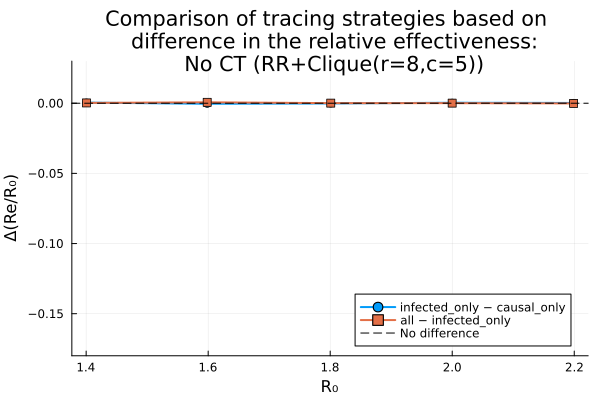

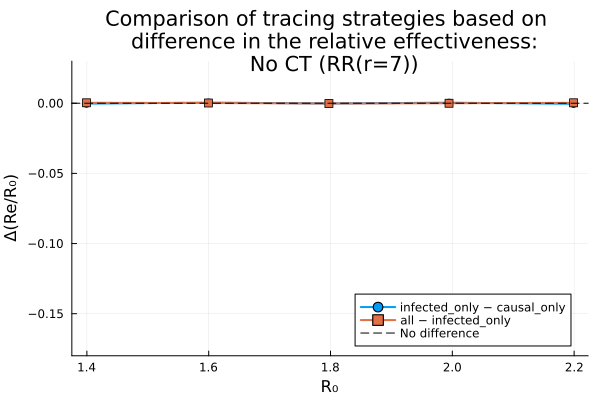

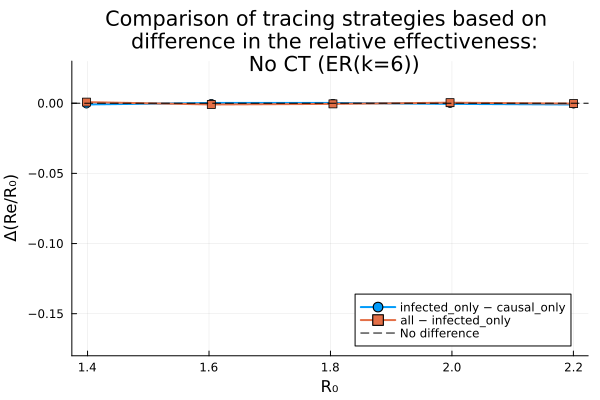

In [127]:
p11_noCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n No CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - No CT.png")

p12_noCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n No CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR r=7 - No CT.png")

p13_noCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :noCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n No CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) ER k=6 - No CT.png")

savefig(p11_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - No CT.png")
savefig(p12_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR r=7 - No CT.png")
savefig(p13_noCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) ER k=6 - No CT.png")


display(p11_noCT)
display(p12_noCT)
display(p13_noCT)

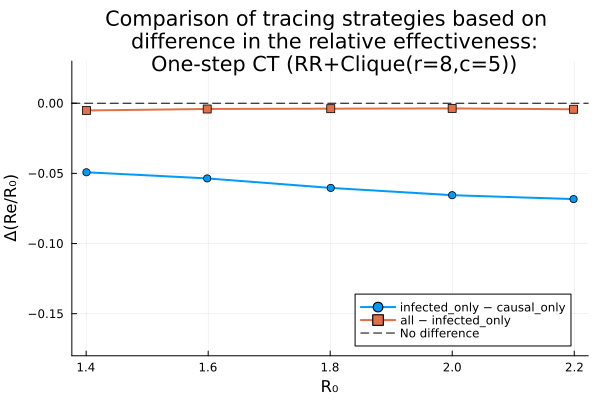

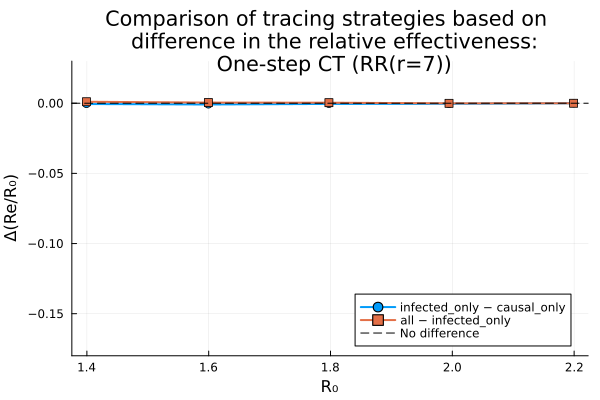

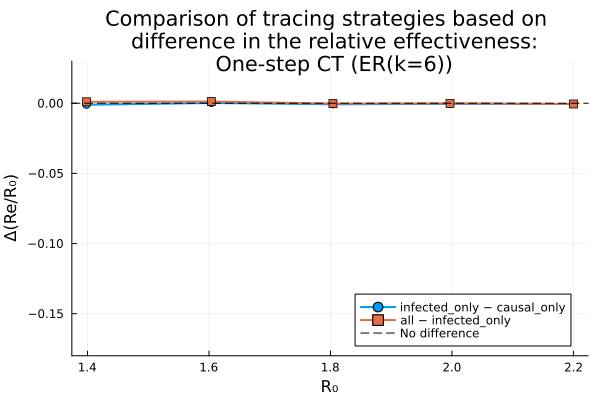

In [128]:
p11_oneCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n One-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - One CT.png")


p12_oneCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n One-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR r=7 - One CT.png")


p13_oneCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :oneCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n One-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) ER k=6 - One CT.png")


savefig(p11_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - One CT.png")
savefig(p12_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR r=7 - One CT.png")
savefig(p13_oneCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) ER k=6 - One CT.png")



display(p11_oneCT)
display(p12_oneCT)
display(p13_oneCT)

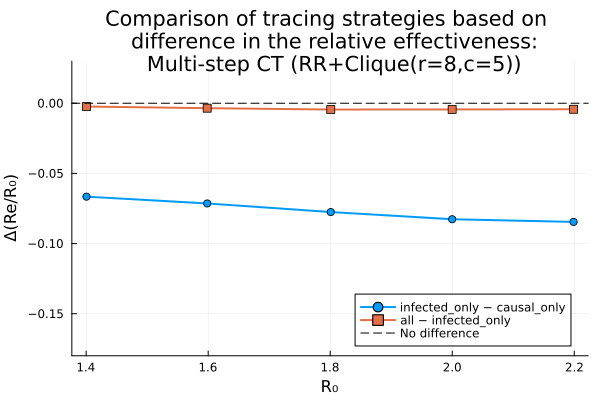

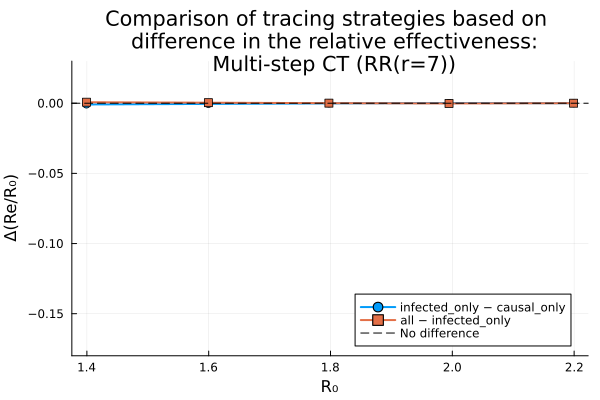

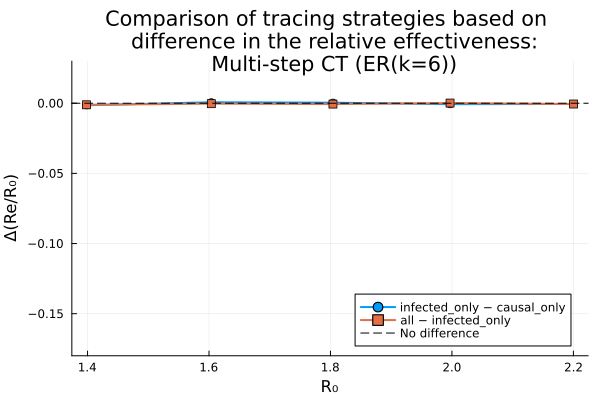

In [129]:
p11_multiCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR+Clique(r=8,c=5)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n Multi-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - Multi CT.png")


p12_multiCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "RR(r=7)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n Multi-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) RR r=7 - Multi CT.png")

p13_multiCT = plot_trace_mode_strategy_one_network(
    result_r8_c5_v1,
    result_r8_c5_v2,
    result_r8_c5_v3;
    network_name = "ER(k=6)",
    regime = :multiCT,
    xaxis = :R0_obs,
    title_str = "Comparison of tracing strategies based on \n difference in the relative effectiveness:\n Multi-step CT",
    ylim = (-0.18, 0.03),
    legend_pos=:bottomright
)
#savefig("Rho against R0 (Diff. Trac. Strag.) ER k=6 - Multi CT.png")


savefig(p11_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR+C r8 c5 - Multi CT.png")
savefig(p12_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) RR r=7 - Multi CT.png")
savefig(p13_multiCT, "/Users/oawolude/Documents/Project/Current_Plots/Difference in Relative Effectiveness/Rho against R0 (Diff. Trac. Strag.) ER k=6 - Multi CT.png")



display(p11_multiCT)
display(p12_multiCT)
display(p13_multiCT)